## Perceptrón Multicapa (MLP) entrenado para dataset de detección visual de personajes de los Simpsons

#### Integrantes:

    - VINCENT FARENDEN CERÓN
    - RODRIGO IGNACIO MARTÍNEZ BECKER
    - IVÁN MANUEL PAVÓN BARRÍA
    - DIEGO IGNACIO PEÑA Y LILLO LUHRS

#### Asignatura:

    - TÉCNICAS AVANZADAS DE MACHINE LEARNING_001D

#### Profesor:

    - FRANCISCO JAVIER JEREZ SALAZAR

#### Fecha:

    - 14-09-2026

## Definición del Dataset

Nuestro conjunto de datos se presenta como dos carpetas de entreno y pruebas en donde ambas presentan la misma estructura de imágenes, una carpeta por personaje definido con varias imágenes de estos desde varios puntos de vista. Nosotros escogimos este dataset debido a la gran popularidad de los personajes y porque tienen una identidad gráfica extremadamente reconocible: piel amarilla, siluetas simples, colores fuertes y personajes fáciles de distinguir incluso con pocos detalles. Su diseño es consistente y memorable, lo que hace que la serie destaque inmediatamente frente a otras animaciones. El dataset completo reúne aproximadamente 20.000 imágenes y ocupa 550 MB (577.675.264 bytes), por lo que no se versiona en el repositorio.

![Homero](../images/homero.png) ![Lisa](../images/lisa.png)

## Problema de negocio, objetivos y KPIs

### Contexto y problema de negocio

Un archivo audiovisual crece mucho mas rapido de lo que un equipo humano puede
catalogarlo. Miles de fotogramas sin etiquetar son material practicamente inservible:
no se pueden buscar, no se pueden reutilizar y no permiten medir nada. Hoy esa
catalogacion se hace a mano, imagen por imagen, y su costo crece de forma lineal con
el tamano del archivo.

**Problema de negocio.** *El archivo de imagenes crece mas rapido de lo que el equipo
puede catalogarlo manualmente, lo que impide buscar material por personaje, encarece
cada proyecto de reutilizacion de contenido y deja sin explotar el catalogo
acumulado.*

Este proyecto aborda ese problema sobre un archivo de aproximadamente **20.000
imagenes (550 MB)** de Los Simpson: asignar automaticamente el personaje que aparece
en cada imagen, para que el archivo pase de ser un conjunto de ficheros sueltos a un
catalogo consultable.

| Caso de uso | Que habilita el modelo |
|---|---|
| Busqueda en el archivo | Recuperar todos los planos de un personaje para un montaje, un trailer o un recopilatorio tematico. |
| Pre-clasificacion asistida | El modelo propone y una persona valida: convierte trabajo de *etiquetar* en trabajo de *revisar*, que es mucho mas rapido. |
| Metricas de contenido | Cuantificar la presencia en pantalla de cada personaje, dato relevante para licenciamiento y merchandising. |
| Control de uso de marca | Detectar personajes con derechos dentro de material aportado por terceros. |

### Objetivos del proyecto

**Objetivo general.** Implementar y evaluar un Perceptron Multicapa capaz de asignar
a cada imagen RGB uno de los 25 personajes del catalogo, mediante un flujo
reproducible cuyo desempeno se mida frente a referencias triviales y de forma
sensible al desbalance de clases.

**Objetivos especificos.**

1. Indexar las imagenes disponibles y asociar cada ruta con la clase de su carpeta.
2. Preparar los datos para el MLP: conversion a RGB, redimensionado, normalizacion,
   aplanado y codificacion one-hot de las etiquetas.
3. Separar entrenamiento y validacion de forma estratificada con semilla fija,
   reservando el conjunto opuesto para la prueba final.
4. Entrenar un modelo base y comparar cinco variantes controladas de arquitectura e
   hiperparametros, cambiando un factor a la vez.
5. Seleccionar la configuracion final por F1 macro de validacion y medirla una sola
   vez sobre el conjunto de prueba.
6. Auditar el resultado: metricas por clase, matriz de confusion, aciertos, errores y
   limitaciones del MLP aplicado a imagenes.

### KPIs del proyecto

Los umbrales se fijan **antes** de evaluar el modelo y traducen el escenario de uso a
cantidades medibles sobre los datos. El cumplimiento se verifica al final de la
seccion de evaluacion, con las cifras obtenidas en la prueba final.

| KPI | Que mide en el negocio | Metrica tecnica | Umbral |
|---|---|---|---|
| Cobertura de asistencia | Con que frecuencia el catalogador encuentra la respuesta correcta entre las tres sugerencias del sistema. | Top-3 accuracy en test | >= 0,70 |
| Equidad entre personajes | Que el catalogo sirva para todos los personajes y no solo para los mas frecuentes. | F1 macro en test | >= 0,45 |
| Automatizacion sin revision | Proporcion de imagenes que el sistema resuelve sin intervencion humana. | Accuracy en test | >= 0,50 |
| Ventaja sobre el criterio trivial | Que el sistema aporte informacion real frente a etiquetar todo como el personaje mas comun. | Accuracy / baseline mayoritaria | >= 4x |
| Costo de catalogacion | Capacidad de procesar el archivo completo en un tiempo razonable. | Imagenes por segundo en inferencia | >= 1.000 img/s |

La eleccion de **top-3 accuracy** y **F1 macro** como KPIs principales no es casual:
el sistema esta pensado como asistente de un catalogador, no como reemplazo, y un
catalogo que solo reconoce a los personajes mayoritarios no resuelve el problema de
busqueda. Por eso la seleccion de modelo se hace por F1 macro y no por accuracy.

> La resolucion de entrada de esta corrida es 64x64 (12.288 valores por
> imagen); se fija en la seccion de preprocesamiento.


## Definición del problema de clasificación

El problema que abordamos es de **clasificación de imágenes multiclase de etiqueta única**: dada una imagen RGB que contiene a un personaje de Los Simpsons, el modelo debe asignarle **exactamente una** de las 25 clases posibles (una por personaje). No es detección de objetos ni clasificación multi-etiqueta: no se predicen cajas delimitadoras ni varios personajes por imagen.

**Alcance verificable del trabajo.** El escenario descrito en la sección anterior es el marco de uso declarado del proyecto, no un encargo de un cliente real: no hay contrato, operación comercial ni cifras económicas que permitan calcular un retorno monetario. Por eso los KPIs se expresan en cantidades medibles sobre los datos disponibles y no en unidades de dinero.

**Variante definida: 25 clases comunes.** Se seleccionaron los 25 personajes que están presentes tanto en `train` como en `test`. Así, cada clase usada para ajustar el MLP también puede evaluarse con imágenes nunca vistas; no se incorporan etiquetas sin contraparte de prueba. La cantidad mantiene un problema multiclase exigente y, a la vez, acota el tiempo y la memoria requeridos por un MLP que transforma cada imagen de 64 × 64 × 3 en 12.288 características. La selección se fija antes del entrenamiento y no depende de las métricas obtenidas por ningún modelo. Las salidas guardadas registran 16.137 imágenes en `train` y 3.937 en `test`.

**Criterios de éxito observables.** El desempeño se interpreta frente a tres referencias ya calculadas por el notebook: accuracy aleatoria (1/25 = 4,0 %), accuracy de predecir siempre la clase mayoritaria (11,4 %) y F1 macro, que da el mismo peso a las 25 clases. También se reportan precision, recall, F1 por clase, matriz de confusión y top-3 accuracy. No se fijan umbrales nuevos a posteriori: los de los KPIs se declaran antes de entrenar, en la sección «Problema de negocio, objetivos y KPIs», y su cumplimiento se verifica al cerrar la sección de evaluación.

**Entrada y salida**

- **Entrada (X):** imagen RGB de tamaño variable (aprox. entre 256x257 y 720x464 px). Para el Perceptrón Multicapa se redimensionará a un tamaño fijo, se normalizarán los píxeles al rango [0, 1] y se aplanará la imagen en un vector, ya que el MLP no acepta estructura espacial 2D.
- **Salida (y):** vector de 25 probabilidades (activación *softmax*); la clase predicha es la de mayor probabilidad.
- **Función de pérdida:** entropía cruzada categórica (*categorical crossentropy*).

**Conjuntos de datos**

| Conjunto | Imágenes | Clases |
|---|---|---|
| train | 16.137 | 25 |
| test | 3.937 | 25 |

**Desbalance de clases**

Las clases están fuertemente desbalanceadas: en entrenamiento van desde 1.796 imágenes de `homer_simpson` hasta 82 de `selma_bouvier` (razón aproximada de 22:1). Esto implica que la *accuracy* por sí sola es una métrica engañosa, y que el modelo tenderá a favorecer a los personajes mayoritarios.

**Baselines de referencia**

- Clasificador aleatorio: 1/25 = **4,0 %** de accuracy.
- Clasificador de clase mayoritaria (predecir siempre `homer_simpson`): 450/3.937 = **11,4 %** en test.

Cualquier modelo útil debe superar claramente estos valores.

**Métricas de evaluación**

Además de la *accuracy* global se reportarán **precision, recall y F1-score por clase**, el **F1 macro** (que pondera igual a todas las clases, mostrando el efecto del desbalance) y la **matriz de confusión**, útil para detectar confusiones sistemáticas entre personajes visualmente parecidos (por ejemplo, Bart y Milhouse, o Lisa y Maggie).

**Dificultades esperadas**

Como se puede ver en las imágenes del apartado anterior, tanto Homero como Lisa aparecen en múltiples poses, con distintos encuadres, escalas y fondos, y con variaciones de color debidas a las diferentes temporadas. A esto se suman personajes parcialmente ocluidos o acompañados por otros en la misma escena, y la pérdida de información espacial al aplanar la imagen para el MLP, lo que limita el rendimiento alcanzable frente a arquitecturas convolucionales.

**Supuestos**

Se asume que cada imagen contiene un único personaje relevante (el que da nombre a su carpeta) y que la partición train/test provista por el dataset es válida, es decir, que no existen imágenes duplicadas entre ambos conjuntos.

## Pre-Procesamiento de los datos

En esta sección se prepara el dataset para que pueda ser consumido por una red densa: se cargan las rutas e imágenes, se llevan todas a un tamaño fijo, se normalizan los valores de píxel, se aplanan a vectores y se codifican las etiquetas.

### Definición del conjunto de datos a utilizar

In [58]:
from datetime import datetime
from pathlib import Path

# Marca de inicio de la corrida. La seccion de rendimiento del final del notebook
# la usa para calcular la hora de termino y la duracion total.
INICIO_CORRIDA = datetime.now()
print(f"Inicio de la corrida: {INICIO_CORRIDA:%Y-%m-%d %H:%M:%S}\n")

DATASET_BASE = Path("C:/Users/Laptop/Desktop/Trabajos/LosSimpsonsDataset")
CONJUNTOS_VALIDOS = ("train", "test")

# Cambiar a ( 'train' / 'test' ) según el conjunto con el que quieras entrenar
conjunto = "train"

conjunto = conjunto.strip().lower()
if conjunto not in CONJUNTOS_VALIDOS:
    raise ValueError(
        f'Conjunto invalido: "{conjunto}". Usa uno de: {CONJUNTOS_VALIDOS}'
    )

# El conjunto de evaluación final es siempre el OPUESTO al de entrenamiento:
# si se entrena con "train" se comprueba con "test", y viceversa.
conjunto_evaluacion = next(c for c in CONJUNTOS_VALIDOS if c != conjunto)

direccion_dataset = DATASET_BASE / conjunto
direccion_evaluacion = DATASET_BASE / conjunto_evaluacion

for nombre, ruta in ((conjunto, direccion_dataset), (conjunto_evaluacion, direccion_evaluacion)):
    if not ruta.is_dir():
        raise FileNotFoundError(f'No existe el directorio del conjunto "{nombre}": {ruta}')

print(f'Entrenamiento : conjunto "{conjunto}" en {direccion_dataset}')
print(f'Evaluacion    : conjunto "{conjunto_evaluacion}" en {direccion_evaluacion}')
print(
    "\nEl conjunto de evaluación se reserva intacto: no se usa para ajustar pesos"
    " ni para elegir hiperparámetros, solo para la comprobación final."
)

Inicio de la corrida: 2026-09-15 11:22:54

Entrenamiento : conjunto "train" en C:\Users\Laptop\Desktop\Trabajos\LosSimpsonsDataset\train
Evaluacion    : conjunto "test" en C:\Users\Laptop\Desktop\Trabajos\LosSimpsonsDataset\test

El conjunto de evaluación se reserva intacto: no se usa para ajustar pesos ni para elegir hiperparámetros, solo para la comprobación final.


### Carga de imágenes y etiquetas

In [59]:
import pandas as pd

EXTENSIONES_VALIDAS = (".jpg", ".jpeg", ".png", ".bmp")


def construir_indice(directorio):
    """Recorre un directorio con una subcarpeta por clase y devuelve un
    DataFrame con la ruta de cada imagen y el personaje al que pertenece."""
    registros = []

    for carpeta_clase in sorted(directorio.iterdir()):
        if not carpeta_clase.is_dir():
            continue

        for ruta in sorted(carpeta_clase.iterdir()):
            if ruta.suffix.lower() in EXTENSIONES_VALIDAS:
                registros.append({"ruta": ruta, "personaje": carpeta_clase.name})

    if not registros:
        raise FileNotFoundError(f"No se encontraron imagenes en: {directorio}")

    return pd.DataFrame(registros)


# Índice del conjunto seleccionado en el paso anterior
datos = construir_indice(direccion_dataset)

# Lista ordenada de clases y su mapeo a índices enteros
clases = sorted(datos["personaje"].unique())
clase_a_indice = {clase: indice for indice, clase in enumerate(clases)}
indice_a_clase = {indice: clase for clase, indice in clase_a_indice.items()}

# Etiqueta numérica de cada imagen
datos["etiqueta"] = datos["personaje"].map(clase_a_indice)

# Resumen de imágenes por clase como DataFrame
resumen = (
    datos["personaje"]
    .value_counts()
    .rename_axis("personaje")
    .reset_index(name="imagenes")
)
resumen["etiqueta"] = resumen["personaje"].map(clase_a_indice)
resumen["porcentaje"] = (resumen["imagenes"] / len(datos) * 100).round(2)
resumen = resumen[["etiqueta", "personaje", "imagenes", "porcentaje"]]

print(f'Conjunto "{conjunto}": {len(datos)} imagenes en {len(clases)} clases')

display(resumen)


Conjunto "train": 16137 imagenes en 25 clases


,etiqueta,personaje,imagenes,porcentaje
0,9,homer_simpson,1796,11.13
1,19,ned_flanders,1163,7.21
2,18,moe_szyslak,1161,7.19
3,13,lisa_simpson,1083,6.71
4,3,bart_simpson,1073,6.65
5,15,marge_simpson,1032,6.40
6,11,krusty_the_clown,964,5.97
7,21,principal_skinner,955,5.92
8,4,charles_montgomery_burns,954,5.91
9,17,milhouse_van_houten,863,5.35


### Redimensionado a un tamaño fijo



In [60]:
from PIL import Image
import numpy as np

# Dimensiones originales de cada imagen del conjunto (sin cargar los píxeles)
dimensiones = []
for ruta in datos["ruta"]:
    with Image.open(ruta) as img:
        dimensiones.append(img.size)  # (ancho, alto)

datos["ancho"] = [ancho for ancho, _ in dimensiones]
datos["alto"] = [alto for _, alto in dimensiones]

resumen_dimensiones = datos[["ancho", "alto"]].describe().T
resumen_dimensiones["mediana"] = datos[["ancho", "alto"]].median()
resumen_dimensiones = resumen_dimensiones[
    ["count", "min", "25%", "mediana", "75%", "max", "mean", "std"]
].round(1)

display(resumen_dimensiones)


,count,min,25%,mediana,75%,max,mean,std
ancho,16137.0,256.0,288.0,320.0,576.0,1912.0,408.5,149.0
alto,16137.0,256.0,379.0,432.0,480.0,1072.0,416.4,63.1


**Elección y justificación del tamaño objetivo**

Las imágenes del conjunto tienen dimensiones variables, mientras que una red densa exige un vector de
entrada de longitud fija. Por lo tanto, el primer paso del pre-procesamiento consiste en llevar todas
las imágenes a una misma resolución.

La elección de esa resolución no es arbitraria, ya que condiciona directamente el tamaño del modelo.
Al aplanar la imagen, la capa de entrada queda formada por `alto x ancho x 3` valores (tres canales
RGB por píxel) y cada uno de ellos se conecta con todas las neuronas de la primera capa oculta. En
consecuencia, el número de parámetros de esa capa crece de forma cuadrática respecto del lado de la
imagen:

| Resolución | Dimensión del vector de entrada | Parámetros de la primera capa densa (512 neuronas) |
|---|---|---|
| 32 x 32 | 3.072 | ≈ 1,6 millones |
| 64 x 64 | 12.288 | ≈ 6,3 millones |
| **128 x 128 (corrida guardada)** | **49.152** | **≈ 25,2 millones** |

La configuración que realmente ejecuta este notebook fija **128 x 128 píxeles** en la celda siguiente. Sus salidas guardadas confirman una matriz de 16.137 imágenes con forma `(16137, 128, 128, 3)` y un vector aplanado de 49.152 valores. Por tanto, esta sección describe esa corrida y no presenta 64 x 64 como la configuración usada.

La tabla permite interpretar su costo: al duplicar el lado de 64 a 128, la entrada pasa de 12.288 a 49.152 valores y la primera capa densa de 512 neuronas concentra aproximadamente 25,2 millones de parámetros. La comparación entre resoluciones existe como evidencia de rendimiento, pero la selección del modelo de este notebook se hace entre arquitecturas e hiperparámetros sobre la resolución configurada.


In [61]:
ALTO_OBJETIVO, ANCHO_OBJETIVO = 64, 64
TAMANO_OBJETIVO = (ANCHO_OBJETIVO, ALTO_OBJETIVO)  # PIL usa (ancho, alto)


def cargar_y_redimensionar(ruta, tamano=TAMANO_OBJETIVO):
    """Abre una imagen, la convierte a RGB y la redimensiona al tamaño fijo."""
    with Image.open(ruta) as img:
        img = img.convert("RGB").resize(tamano, Image.Resampling.BILINEAR)
        return np.asarray(img, dtype=np.uint8)


# Matriz de imágenes redimensionadas: (n_imagenes, alto, ancho, 3)
imagenes = np.stack([cargar_y_redimensionar(ruta) for ruta in datos["ruta"]])
etiquetas = datos["etiqueta"].to_numpy()

print(f"imagenes: {imagenes.shape}  dtype={imagenes.dtype}")
print(f"etiquetas: {etiquetas.shape}")


imagenes: (16137, 64, 64, 3)  dtype=uint8
etiquetas: (16137,)


**Comprobación del redimensionado**

In [62]:
comprobaciones = pd.DataFrame(
    [
        ("Número de imágenes", imagenes.shape[0], len(datos), imagenes.shape[0] == len(datos)),
        ("Alto", imagenes.shape[1], ALTO_OBJETIVO, imagenes.shape[1] == ALTO_OBJETIVO),
        ("Ancho", imagenes.shape[2], ANCHO_OBJETIVO, imagenes.shape[2] == ANCHO_OBJETIVO),
        ("Canales", imagenes.shape[3], 3, imagenes.shape[3] == 3),
        ("Tipo de dato", str(imagenes.dtype), "uint8", imagenes.dtype == np.uint8),
        ("Valor mínimo", int(imagenes.min()), ">= 0", imagenes.min() >= 0),
        ("Valor máximo", int(imagenes.max()), "<= 255", imagenes.max() <= 255),
        ("Etiquetas alineadas", len(etiquetas), imagenes.shape[0], len(etiquetas) == imagenes.shape[0]),
    ],
    columns=["comprobacion", "obtenido", "esperado", "ok"],
)

memoria_mb = imagenes.nbytes / 1024**2
print(f"Memoria ocupada por la matriz de imagenes: {memoria_mb:.1f} MB")
print(f"Neuronas en la capa de entrada tras aplanar: {ALTO_OBJETIVO * ANCHO_OBJETIVO * 3}")

display(comprobaciones)


Memoria ocupada por la matriz de imagenes: 189.1 MB
Neuronas en la capa de entrada tras aplanar: 12288


,comprobacion,obtenido,esperado,ok
0,Número de imágenes,16137,16137,True
1,Alto,64,64,True
2,Ancho,64,64,True
3,Canales,3,3,True
4,Tipo de dato,uint8,uint8,True
5,Valor mínimo,0,>= 0,True
6,Valor máximo,255,<= 255,True
7,Etiquetas alineadas,16137,16137,True


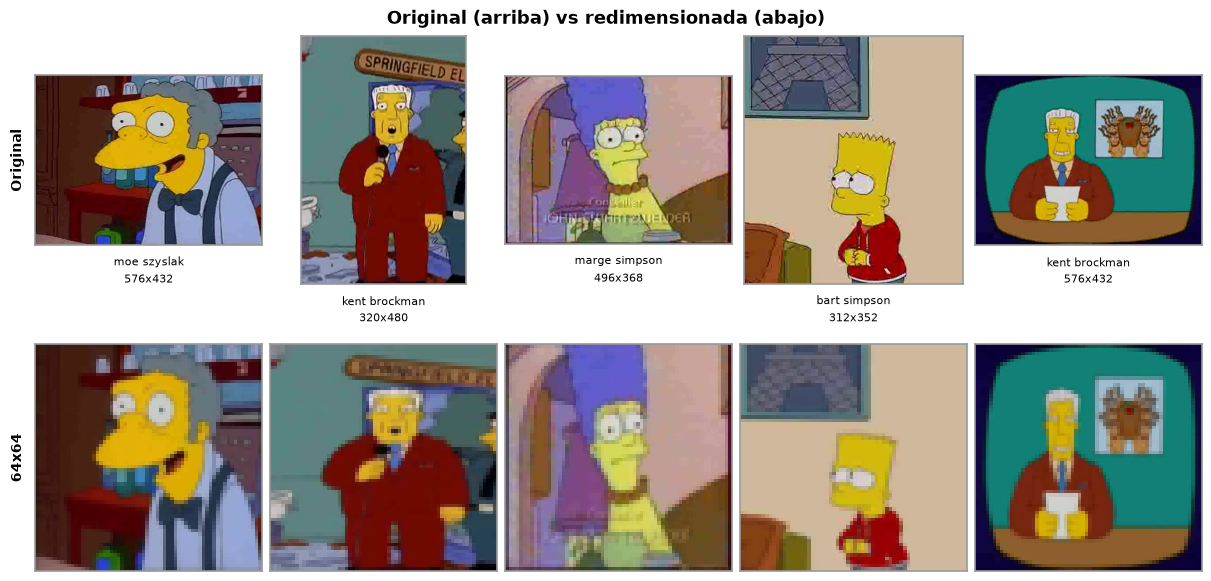

In [63]:
import matplotlib.pyplot as plt

# Comparación visual original vs redimensionada para una muestra aleatoria
generador = np.random.default_rng(42)
muestra = generador.choice(len(datos), size=5, replace=False)

figura, ejes = plt.subplots(
    2,
    len(muestra),
    figsize=(2.4 * len(muestra), 5.8),
    layout="constrained",
)
for columna, indice in enumerate(muestra):
    fila = datos.iloc[indice]
    with Image.open(fila["ruta"]) as img:
        original = img.convert("RGB")

    personaje = fila["personaje"].replace("_", " ")
    ejes[0, columna].imshow(original)
    ejes[1, columna].imshow(imagenes[indice])

    # El texto va debajo de la imagen para que no invada la fila de arriba
    ejes[0, columna].set_xlabel(
        f"{personaje}\n{original.size[0]}x{original.size[1]}",
        fontsize=8,
        labelpad=6,
        linespacing=1.5,
    )

    for eje in (ejes[0, columna], ejes[1, columna]):
        eje.set_xticks([])
        eje.set_yticks([])
        for lado in eje.spines.values():
            lado.set_edgecolor("#999999")
            lado.set_linewidth(1.2)

# Etiqueta de fila a la izquierda, en vez de repetir el mismo título en cada columna
ejes[0, 0].set_ylabel("Original", fontsize=10, fontweight="bold", labelpad=8)
ejes[1, 0].set_ylabel(
    f"{ANCHO_OBJETIVO}x{ALTO_OBJETIVO}", fontsize=10, fontweight="bold", labelpad=8
)

figura.suptitle("Original (arriba) vs redimensionada (abajo)", fontsize=13, fontweight="bold")
plt.show()


### Normalización de los píxeles



**Por qué normalizar**

Los píxeles se almacenan como enteros `uint8` en el rango [0, 255]. Si se alimentan directamente a la
red, las combinaciones lineales de la primera capa producen valores de magnitud muy grande: las
activaciones sigmoide o tanh se saturan (gradiente prácticamente nulo) y, con ReLU, los gradientes
resultan muy dispares entre sí, lo que obliga a usar tasas de aprendizaje muy pequeñas y hace
inestable el descenso del gradiente.

Al dividir por 255 todas las características de entrada quedan en la misma escala acotada [0, 1]. Esto
mantiene las preactivaciones en un rango razonable, hace comparables las magnitudes de los gradientes
entre píxeles y permite que la inicialización estándar de los pesos de Keras funcione como se espera.

Se convierte además a `float32`, que es el tipo con el que opera Keras: es la mitad de memoria que
`float64` y evita conversiones implicitas en cada batch.


In [64]:
# Escalado de [0, 255] a [0, 1] en float32 (tipo con el que opera Keras)
VALOR_MAXIMO_PIXEL = 255.0

imagenes_norm = imagenes.astype(np.float32) / VALOR_MAXIMO_PIXEL

memoria_mb = imagenes_norm.nbytes / (1024**2)

print(f"imagenes_norm: {imagenes_norm.shape}  dtype={imagenes_norm.dtype}")
print(f"rango: [{imagenes_norm.min():.3f}, {imagenes_norm.max():.3f}]")
print(f"media: {imagenes_norm.mean():.4f}  desviacion: {imagenes_norm.std():.4f}")
print(f"memoria ocupada: {memoria_mb:.1f} MB")


imagenes_norm: (16137, 64, 64, 3)  dtype=float32
rango: [0.000, 1.000]
media: 0.4066  desviacion: 0.2448
memoria ocupada: 756.4 MB


**Comprobación de la normalización**

In [65]:
indice_prueba = 0

comprobaciones_norm = pd.DataFrame(
    [
        (
            "Forma conservada",
            str(imagenes_norm.shape),
            str(imagenes.shape),
            imagenes_norm.shape == imagenes.shape,
        ),
        (
            "Tipo de dato",
            str(imagenes_norm.dtype),
            "float32",
            imagenes_norm.dtype == np.float32,
        ),
        (
            "Valor mínimo",
            round(float(imagenes_norm.min()), 4),
            ">= 0.0",
            imagenes_norm.min() >= 0.0,
        ),
        (
            "Valor máximo",
            round(float(imagenes_norm.max()), 4),
            "<= 1.0",
            imagenes_norm.max() <= 1.0,
        ),
        (
            "Sin NaN ni infinitos",
            bool(np.isfinite(imagenes_norm).all()),
            True,
            bool(np.isfinite(imagenes_norm).all()),
        ),
        (
            "Escalado exacto (x255 == original)",
            "imagenes_norm * 255",
            "imagenes",
            np.allclose(
                imagenes_norm[indice_prueba] * VALOR_MAXIMO_PIXEL,
                imagenes[indice_prueba].astype(np.float32),
            ),
        ),
    ],
    columns=["Comprobacion", "Obtenido", "Esperado", "Correcto"],
)

display(comprobaciones_norm)

if not comprobaciones_norm["Correcto"].all():
    raise ValueError("La normalización no cumple alguna de las comprobaciones.")

print("Normalización verificada correctamente.")


,Comprobacion,Obtenido,Esperado,Correcto
0,Forma conservada,"(16137, 64, 64, 3)","(16137, 64, 64, 3)",True
1,Tipo de dato,float32,float32,True
2,Valor mínimo,0.0,>= 0.0,True
3,Valor máximo,1.0,<= 1.0,True
4,Sin NaN ni infinitos,True,True,True
5,Escalado exacto (x255 == original),imagenes_norm * 255,imagenes,True


Normalización verificada correctamente.


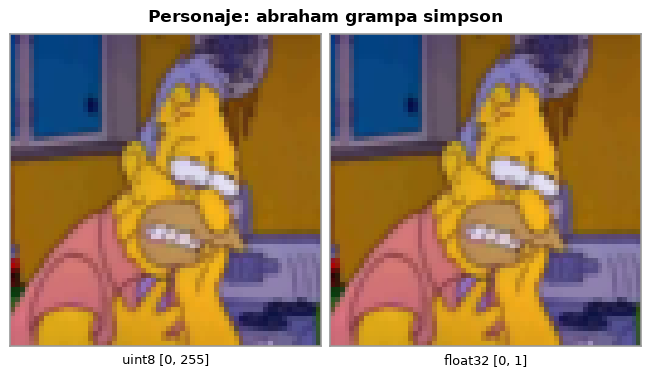

In [66]:
# La imagen normalizada debe verse idéntica a la original: solo cambia la escala numérica
figura, ejes = plt.subplots(1, 2, figsize=(6.4, 3.6), layout="constrained")

paneles = (
    (imagenes[indice_prueba], "uint8 [0, 255]"),
    (imagenes_norm[indice_prueba], "float32 [0, 1]"),
)
for eje, (imagen, etiqueta) in zip(ejes, paneles):
    eje.imshow(imagen)
    eje.set_xticks([])
    eje.set_yticks([])
    for lado in eje.spines.values():
        lado.set_edgecolor("#999999")
        lado.set_linewidth(1.2)
    eje.set_xlabel(etiqueta, fontsize=9, labelpad=6)

personaje = datos.iloc[indice_prueba]["personaje"].replace("_", " ")
figura.suptitle(f"Personaje: {personaje}", fontsize=12, fontweight="bold")
plt.show()


### Vectorización (aplanado) de las imágenes

**Por qué aplanar y qué implica**

Una capa densa (`Dense`) recibe un vector: cada neurona se conecta con **todas** las entradas mediante
un peso. No tiene forma de aprovechar que dos píxeles estén uno al lado del otro, porque en su interior
todas las entradas son intercambiables. Por eso la imagen de `alto x ancho x 3` debe convertirse en un
único vector de longitud fija `alto * ancho * 3`.

Con la configuración ejecutada en "Redimensionado a un tamaño fijo" esto da **128 x 128 x 3 = 49 152** valores por imagen, que es exactamente la
dimensión de la capa de entrada del MLP.

El aplanado es el paso donde se **pierde la estructura espacial**: el modelo ya no sabe que el píxel
`(0, 0)` y el `(0, 1)` eran vecinos. Esta es precisamente la limitación que se discute en "Limitaciones del MLP en imágenes y propuestas de mejora"
y el motivo por el que una CNN, que sí preserva esa vecindad, resulta más adecuada para imágenes.



**Por qué `X` tiene dos dimensiones e `y` solo una**

`X` es una **matriz**: una fila por imagen y una columna por característica de entrada. Su forma
`(16137, 49152)` se lee como "16 137 ejemplos, cada uno descrito por 49 152 números". La primera
dimensión siempre cuenta ejemplos y la segunda las características de cada uno; es el formato que Keras
espera para alimentar una capa densa, que procesa las filas por lotes (batches).

`y` es un **vector**: su forma `(16137,)` significa "16 137 etiquetas", una por fila de `X`. Para
describir a qué personaje corresponde una imagen basta con un único número (el índice de la clase), así
que no hace falta una segunda dimensión. Lo único imprescindible es que `X.shape[0] == y.shape[0]` y que
el orden coincida: la etiqueta `y[i]` corresponde a la imagen `X[i]`.

Esa asimetría es solo del estado actual de los datos, no una regla: en "Codificación de las etiquetas"
se aplicará one-hot encoding y `y` pasará a ser también una matriz `(16137, 25)`, con una columna por
personaje, que es lo que exige la pérdida `categorical_crossentropy`.

El orden del aplanado es `C` (por filas: fila a fila, y dentro de cada fila los tres canales RGB de cada
píxel). Lo importante no es el orden concreto, sino que sea **el mismo para todas las imágenes** y para
los conjuntos de train y test, cosa que `reshape` garantiza al aplicarse sobre el arreglo completo.


In [67]:
# Cada imagen (alto, ancho, 3) pasa a ser un vector de alto * ancho * 3 valores
DIMENSION_ENTRADA = ALTO_OBJETIVO * ANCHO_OBJETIVO * 3

X = imagenes_norm.reshape(imagenes_norm.shape[0], -1)
y = etiquetas

print(f"X: {X.shape}  dtype={X.dtype}")
print(f"y: {y.shape}")
print(f"Dimension de la capa de entrada: {DIMENSION_ENTRADA}")
print(f"rango de X: [{X.min():.3f}, {X.max():.3f}]")


X: (16137, 12288)  dtype=float32
y: (16137,)
Dimension de la capa de entrada: 12288
rango de X: [0.000, 1.000]


**Comprobación del aplanado**

In [68]:
# El aplanado debe ser reversible: recuperar la imagen original desde su vector
imagen_reconstruida = X[indice_prueba].reshape(ALTO_OBJETIVO, ANCHO_OBJETIVO, 3)

comprobaciones_aplanado = pd.DataFrame(
    [
        (
            "Número de imágenes",
            X.shape[0],
            imagenes_norm.shape[0],
            X.shape[0] == imagenes_norm.shape[0],
        ),
        (
            "Longitud del vector",
            X.shape[1],
            DIMENSION_ENTRADA,
            X.shape[1] == DIMENSION_ENTRADA,
        ),
        ("Número de dimensiones", X.ndim, 2, X.ndim == 2),
        ("Tipo de dato", str(X.dtype), "float32", X.dtype == np.float32),
        (
            "Rango conservado [0, 1]",
            f"[{X.min():.3f}, {X.max():.3f}]",
            "[0.0, 1.0]",
            bool(X.min() >= 0.0 and X.max() <= 1.0),
        ),
        (
            "Aplanado reversible",
            "X[i].reshape(alto, ancho, 3)",
            "imagenes_norm[i]",
            np.array_equal(imagen_reconstruida, imagenes_norm[indice_prueba]),
        ),
        ("Etiquetas alineadas", len(y), X.shape[0], len(y) == X.shape[0]),
    ],
    columns=["Comprobacion", "Obtenido", "Esperado", "Correcto"],
)

display(comprobaciones_aplanado)

if not comprobaciones_aplanado["Correcto"].all():
    raise ValueError("El aplanado no cumple alguna de las comprobaciones.")

print("Aplanado verificado correctamente.")


,Comprobacion,Obtenido,Esperado,Correcto
0,Número de imágenes,16137,16137,True
1,Longitud del vector,12288,12288,True
2,Número de dimensiones,2,2,True
3,Tipo de dato,float32,float32,True
4,"Rango conservado [0, 1]","[0.000, 1.000]","[0.0, 1.0]",True
5,Aplanado reversible,"X[i].reshape(alto, ancho, 3)",imagenes_norm[i],True
6,Etiquetas alineadas,16137,16137,True


Aplanado verificado correctamente.


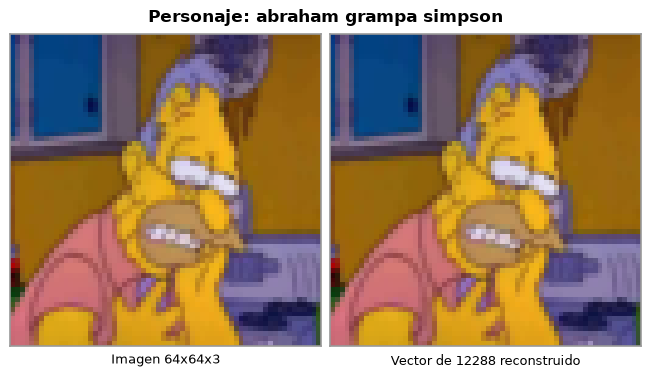

In [69]:
# Al reconstruir el vector se recupera exactamente la misma imagen
figura, ejes = plt.subplots(1, 2, figsize=(6.4, 3.6), layout="constrained")

paneles = (
    (imagenes_norm[indice_prueba], f"Imagen {ALTO_OBJETIVO}x{ANCHO_OBJETIVO}x3"),
    (imagen_reconstruida, f"Vector de {DIMENSION_ENTRADA} reconstruido"),
)
for eje, (imagen, etiqueta) in zip(ejes, paneles):
    eje.imshow(imagen)
    eje.set_xticks([])
    eje.set_yticks([])
    for lado in eje.spines.values():
        lado.set_edgecolor("#999999")
        lado.set_linewidth(1.2)
    eje.set_xlabel(etiqueta, fontsize=9, labelpad=6)

personaje = datos.iloc[indice_prueba]["personaje"].replace("_", " ")
figura.suptitle(f"Personaje: {personaje}", fontsize=12, fontweight="bold")
plt.show()


### Codificación de las etiquetas

**De nombre de carpeta a vector one-hot**

Las etiquetas nacen como texto (el nombre de la carpeta, por ejemplo `homer_simpson`) y una red no opera
con texto, así que hay que convertirlas a números. La conversión se hace en dos pasos:

1. **Índice entero.** Ya se construyó en "Carga de imágenes y etiquetas": `clases` es la lista de
   personajes ordenada alfabéticamente y `clase_a_indice` asigna a cada uno un entero de 0 a 24. Ese
   mapeo se reutiliza aquí en lugar de recalcularlo, porque debe ser **idéntico en train y en test**: si
   el índice 3 significara un personaje distinto en cada conjunto, la evaluación no tendría sentido.

2. **One-hot encoding.** El índice entero por sí solo es engañoso para el modelo: sugiere un **orden** y
   una **distancia** que no existen (que la clase 5 este "entre" la 4 y la 6, o que la 24 sea "mayor" que
   la 1). Los personajes son categorías nominales, sin orden. El one-hot elimina ese artefacto
   representando cada etiqueta como un vector de 25 posiciones con un 1 en la clase correcta y 0 en el
   resto, de modo que todas las clases quedan a la misma distancia entre sí.

Además, esta forma es la que corresponde a la salida de la red: la capa final tiene 25 neuronas con
`softmax`, que produce un vector de 25 probabilidades. La pérdida `categorical_crossentropy` compara ese
vector con el one-hot real, penalizando la probabilidad asignada a la clase verdadera.

> Existe la alternativa de dejar `y` como enteros y usar `sparse_categorical_crossentropy`, que es
> equivalente y ahorra memoria. Aquí se usa one-hot explícito porque hace visible la correspondencia con
> las 25 neuronas de salida, que es justamente lo que interesa mostrar en este trabajo.


In [70]:
NUMERO_CLASES = len(clases)

# One-hot: la fila i de la matriz identidad es el vector con un 1 en la posición i
# Equivale a keras.utils.to_categorical(y, NUMERO_CLASES), sin cargar TensorFlow todavía
y_onehot = np.eye(NUMERO_CLASES, dtype=np.float32)[y]

print(f"Numero de clases: {NUMERO_CLASES}")
print(f"y (indices):  {y.shape}  dtype={y.dtype}")
print(f"y_onehot:     {y_onehot.shape}  dtype={y_onehot.dtype}")

# Correspondencia para una imagen concreta
posicion_activa = int(y_onehot[indice_prueba].argmax())
print(
    f"\nEjemplo (imagen {indice_prueba}): '{datos.iloc[indice_prueba]['personaje']}'"
    f" -> indice {y[indice_prueba]} -> posicion activa {posicion_activa}"
)
print(f"vector one-hot: {y_onehot[indice_prueba].astype(int)}")


Numero de clases: 25
y (indices):  (16137,)  dtype=int64
y_onehot:     (16137, 25)  dtype=float32

Ejemplo (imagen 0): 'abraham_grampa_simpson' -> indice 0 -> posicion activa 0
vector one-hot: [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


**Comprobación de la codificación**

In [71]:
comprobaciones_etiquetas = pd.DataFrame(
    [
        (
            "Número de ejemplos",
            y_onehot.shape[0],
            X.shape[0],
            y_onehot.shape[0] == X.shape[0],
        ),
        (
            "Columnas = número de clases",
            y_onehot.shape[1],
            NUMERO_CLASES,
            y_onehot.shape[1] == NUMERO_CLASES,
        ),
        ("Tipo de dato", str(y_onehot.dtype), "float32", y_onehot.dtype == np.float32),
        (
            "Un único 1 por fila",
            float(y_onehot.sum(axis=1).min()),
            1.0,
            bool(np.all(y_onehot.sum(axis=1) == 1.0)),
        ),
        (
            "Solo valores 0 o 1",
            sorted(np.unique(y_onehot).tolist()),
            [0.0, 1.0],
            bool(np.isin(np.unique(y_onehot), [0.0, 1.0]).all()),
        ),
        (
            "Coincide con el índice entero",
            "y_onehot.argmax(axis=1)",
            "y",
            bool(np.array_equal(y_onehot.argmax(axis=1), y)),
        ),
        (
            "Todas las clases presentes",
            int((y_onehot.sum(axis=0) > 0).sum()),
            NUMERO_CLASES,
            int((y_onehot.sum(axis=0) > 0).sum()) == NUMERO_CLASES,
        ),
        (
            "Mapeo estable (índice -> nombre)",
            indice_a_clase[0],
            clases[0],
            indice_a_clase[0] == clases[0],
        ),
    ],
    columns=["Comprobacion", "Obtenido", "Esperado", "Correcto"],
)

display(comprobaciones_etiquetas)

if not comprobaciones_etiquetas["Correcto"].all():
    raise ValueError("La codificación de etiquetas no cumple alguna de las comprobaciones.")

print("Codificación verificada correctamente.")


,Comprobacion,Obtenido,Esperado,Correcto
0,Número de ejemplos,16137,16137,True
1,Columnas = número de clases,25,25,True
2,Tipo de dato,float32,float32,True
3,Un único 1 por fila,1.0,1.0,True
4,Solo valores 0 o 1,"[0.0, 1.0]","[0.0, 1.0]",True
5,Coincide con el índice entero,y_onehot.argmax(axis=1),y,True
6,Todas las clases presentes,25,25,True
7,Mapeo estable (índice -> nombre),abraham_grampa_simpson,abraham_grampa_simpson,True


Codificación verificada correctamente.


In [72]:
# Diccionario de clases: índice, nombre y ejemplos disponibles
tabla_clases = pd.DataFrame(
    {
        "indice": range(NUMERO_CLASES),
        "personaje": clases,
        "imagenes": [int((y == indice).sum()) for indice in range(NUMERO_CLASES)],
    }
)
tabla_clases["porcentaje"] = (tabla_clases["imagenes"] / len(y) * 100).round(2)

display(tabla_clases)


,indice,personaje,imagenes,porcentaje
0,0,abraham_grampa_simpson,730,4.52
1,1,apu_nahasapeemapetilon,498,3.09
2,2,barney_gumble,84,0.52
3,3,bart_simpson,1073,6.65
4,4,charles_montgomery_burns,954,5.91
5,5,chief_wiggum,788,4.88
6,6,comic_book_guy,375,2.32
7,7,edna_krabappel,365,2.26
8,8,groundskeeper_willie,96,0.59
9,9,homer_simpson,1796,11.13


### Partición train / validación

**Por qué hacen falta tres conjuntos y no dos**

El dataset ya viene dividido en `train` y `test`, pero entrenar mirando el test es hacer trampa: en
cuanto se usa para decidir cuántas capas poner, cuándo detener el entrenamiento o qué learning rate
elegir, deja de ser una estimación honesta del desempeño con datos nuevos, porque esas decisiones ya lo
incorporaron. Ese fenómeno se conoce como fuga de información.

Por eso el conjunto de entrenamiento se parte en dos:

- **Entrenamiento (80 %):** las imágenes con las que se ajustan los pesos.
- **Validación (20 %):** imágenes que nunca actualizan pesos, pero que se miden en cada época. Sirven
  para trazar las curvas de aprendizaje, detectar sobreajuste, activar `EarlyStopping` y comparar las
  configuraciones de la experimentación.
- **Test:** se reserva intacto y se abre **una sola vez**, en la evaluación final del modelo elegido.

**Partición estratificada.** Se usa `stratify=y` para que cada clase conserve en train y en validación la
misma proporción que tiene en el conjunto completo. Con clases muy desbalanceadas, un reparto aleatorio
simple podría dejar a un personaje minoritario con muy pocos ejemplos de validación -- o con ninguno --,
y entonces su métrica sería pura casualidad. La estratificación también hace que la validación sea
comparable entre experimentos.

**Semilla fija.** `random_state=SEMILLA` garantiza que la partición sea siempre la misma. Es un requisito
de la metodología de experimentación: al cambiar un solo factor por vez, la diferencia observada debe
deberse a ese factor y no a que le tocó un reparto de datos distinto.


In [73]:
from sklearn.model_selection import train_test_split

SEMILLA = 42
PROPORCION_VALIDACION = 0.2

# Se reparten a la vez las tres estructuras para que queden alineadas:
# X (vectores), y_onehot (etiquetas para la red) y y (índices, comodos para analizar)
X_train, X_val, y_train, y_val, y_train_idx, y_val_idx = train_test_split(
    X,
    y_onehot,
    y,
    test_size=PROPORCION_VALIDACION,
    stratify=y,  # conserva la proporción de cada personaje en ambas partes
    random_state=SEMILLA,
    shuffle=True,
)

print(f"X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}   y_val:   {y_val.shape}")
print(
    f"\nReparto: {len(X_train)} entrenamiento ({len(X_train) / len(X) * 100:.1f} %)"
    f" / {len(X_val)} validacion ({len(X_val) / len(X) * 100:.1f} %)"
)
print(f"Memoria aproximada: {(X_train.nbytes + X_val.nbytes) / 1024 ** 3:.2f} GB")


X_train: (12909, 12288)   y_train: (12909, 25)
X_val:   (3228, 12288)   y_val:   (3228, 25)

Reparto: 12909 entrenamiento (80.0 %) / 3228 validacion (20.0 %)
Memoria aproximada: 0.74 GB


**Comprobación de la partición**

In [74]:
# Proporción de cada clase en el conjunto completo frente a train y validación
proporciones = pd.DataFrame(
    {
        "personaje": clases,
        "completo_%": [round((y == i).mean() * 100, 2) for i in range(NUMERO_CLASES)],
        "train_%": [round((y_train_idx == i).mean() * 100, 2) for i in range(NUMERO_CLASES)],
        "val_%": [round((y_val_idx == i).mean() * 100, 2) for i in range(NUMERO_CLASES)],
        "n_train": [int((y_train_idx == i).sum()) for i in range(NUMERO_CLASES)],
        "n_val": [int((y_val_idx == i).sum()) for i in range(NUMERO_CLASES)],
    }
)
proporciones["desviacion_%"] = (proporciones["val_%"] - proporciones["completo_%"]).abs().round(2)

display(proporciones)

comprobaciones_particion = pd.DataFrame(
    [
        (
            "Sin pérdida de ejemplos",
            len(X_train) + len(X_val),
            len(X),
            len(X_train) + len(X_val) == len(X),
        ),
        (
            "Dimensión de entrada intacta",
            X_train.shape[1],
            DIMENSION_ENTRADA,
            X_train.shape[1] == DIMENSION_ENTRADA,
        ),
        ("X e y alineados en train", len(y_train), len(X_train), len(y_train) == len(X_train)),
        ("X e y alineados en validación", len(y_val), len(X_val), len(y_val) == len(X_val)),
        (
            "One-hot coherente con índices",
            "y_val.argmax(axis=1)",
            "y_val_idx",
            bool(np.array_equal(np.argmax(y_val, axis=1), y_val_idx)),
        ),
        (
            "Todas las clases en train",
            int(len(np.unique(y_train_idx))),
            NUMERO_CLASES,
            len(np.unique(y_train_idx)) == NUMERO_CLASES,
        ),
        (
            "Todas las clases en validación",
            int(len(np.unique(y_val_idx))),
            NUMERO_CLASES,
            len(np.unique(y_val_idx)) == NUMERO_CLASES,
        ),
        (
            "Estratificación (desviación máxima)",
            f"{proporciones['desviacion_%'].max():.2f} %",
            "< 1 %",
            bool(proporciones["desviacion_%"].max() < 1.0),
        ),
    ],
    columns=["Comprobacion", "Obtenido", "Esperado", "Correcto"],
)

display(comprobaciones_particion)

if not comprobaciones_particion["Correcto"].all():
    raise ValueError("La partición no cumple alguna de las comprobaciones.")

print("Partición verificada correctamente.")


,personaje,completo_%,train_%,val_%,n_train,n_val,desviacion_%
0,abraham_grampa_simpson,4.52,4.52,4.52,584,146,0.00
1,apu_nahasapeemapetilon,3.09,3.08,3.10,398,100,0.01
2,barney_gumble,0.52,0.52,0.53,67,17,0.01
3,bart_simpson,6.65,6.65,6.66,858,215,0.01
4,charles_montgomery_burns,5.91,5.91,5.92,763,191,0.01
5,chief_wiggum,4.88,4.88,4.89,630,158,0.01
6,comic_book_guy,2.32,2.32,2.32,300,75,0.00
7,edna_krabappel,2.26,2.26,2.26,292,73,0.00
8,groundskeeper_willie,0.59,0.60,0.59,77,19,0.00
9,homer_simpson,11.13,11.13,11.12,1437,359,0.01


,Comprobacion,Obtenido,Esperado,Correcto
0,Sin pérdida de ejemplos,16137,16137,True
1,Dimensión de entrada intacta,12288,12288,True
2,X e y alineados en train,12909,12909,True
3,X e y alineados en validación,3228,3228,True
4,One-hot coherente con índices,y_val.argmax(axis=1),y_val_idx,True
5,Todas las clases en train,25,25,True
6,Todas las clases en validación,25,25,True
7,Estratificación (desviación máxima),0.02 %,< 1 %,True


Partición verificada correctamente.


### Tratamiento del desbalance de clases

**El problema**

Como se describió en "Definición del problema de clasificación", las clases están muy desbalanceadas
(razón aproximada 22:1 entre el personaje más y el menos frecuente). Esto sesga el entrenamiento: la
pérdida es un promedio sobre los ejemplos del batch, así que los personajes abundantes dominan el
gradiente y el modelo aprende que, ante la duda, conviene predecir una clase mayoritaria. El resultado
típico es un accuracy global aceptable acompañado de un recall muy bajo en las clases pequeñas, que es
precisamente lo que el **F1 macro** -- promedio no ponderado entre clases -- deja al descubierto.

**Opciones consideradas**

| Estrategia | Qué hace | Por qué se descarta o se elige |
|---|---|---|
| Submuestreo de mayoritarias | Elimina imágenes de las clases grandes | Se descarta: tira información útil y el dataset ya es modesto |
| Sobremuestreo por duplicado | Repite imágenes de las clases pequeñas | Se descarta: los duplicados exactos favorecen el sobreajuste a esas imágenes |
| Aumento de datos | Genera variantes (giros, recortes, brillo) | Útil, pero encarece el entrenamiento; se deja como propuesta de mejora |
| **Pesos por clase** | Pondera la pérdida según la frecuencia de cada clase | **Se elige:** no altera los datos, es una línea de código y actúa justo donde está el sesgo |

**Cómo funciona `class_weight`.** Keras multiplica la pérdida de cada ejemplo por el peso de su clase, de
modo que equivocarse en un personaje raro cuesta más que equivocarse en uno frecuente. Se usa la fórmula
`n_muestras / (n_clases * n_ejemplos_de_la_clase)`, que da peso 1 a una clase de tamaño medio, mayor que 1
a las minoritarias y menor que 1 a las mayoritarias.

**Advertencia importante.** Los pesos se calculan **solo con `y_train`**, nunca con el conjunto completo
ni con validación: usar información de validación para ajustar el entrenamiento sería otra forma de fuga.
Y se aplican **solo durante el entrenamiento**: las métricas de validación y test se miden sin pesos,
porque deben reflejar el desempeño sobre la distribución real de los datos.

El efecto de esta decisión se contrasta en la experimentación, comparando el modelo base con y sin
`class_weight` mediante el accuracy y el F1 macro de validación.


In [75]:
from sklearn.utils.class_weight import compute_class_weight

# Los pesos se calculan SOLO con las etiquetas de entrenamiento
pesos = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUMERO_CLASES),
    y=y_train_idx,
)

# Keras espera un diccionario {indice_de_clase: peso}
pesos_por_clase = {indice: float(peso) for indice, peso in enumerate(pesos)}

conteos_train = np.bincount(y_train_idx, minlength=NUMERO_CLASES)

tabla_pesos = pd.DataFrame(
    {
        "indice": range(NUMERO_CLASES),
        "personaje": clases,
        "n_train": conteos_train,
        "porcentaje": (conteos_train / conteos_train.sum() * 100).round(2),
        "peso": np.round(pesos, 3),
    }
).sort_values("n_train", ascending=False, ignore_index=True)

display(tabla_pesos)

razon_desbalance = conteos_train.max() / conteos_train.min()
print(f"Clase mayoritaria: {clases[int(conteos_train.argmax())]} ({conteos_train.max()} imagenes)")
print(f"Clase minoritaria: {clases[int(conteos_train.argmin())]} ({conteos_train.min()} imagenes)")
print(f"Razon de desbalance: {razon_desbalance:.1f}:1")
print(f"Rango de pesos: [{pesos.min():.3f}, {pesos.max():.3f}]")


,indice,personaje,n_train,porcentaje,peso
0,9,homer_simpson,1437,11.13,0.359
1,19,ned_flanders,930,7.20,0.555
2,18,moe_szyslak,929,7.20,0.556
3,13,lisa_simpson,866,6.71,0.596
4,3,bart_simpson,858,6.65,0.602
5,15,marge_simpson,826,6.40,0.625
6,11,krusty_the_clown,771,5.97,0.670
7,21,principal_skinner,764,5.92,0.676
8,4,charles_montgomery_burns,763,5.91,0.677
9,17,milhouse_van_houten,690,5.35,0.748


Clase mayoritaria: homer_simpson (1437 imagenes)
Clase minoritaria: selma_bouvier (66 imagenes)
Razon de desbalance: 21.8:1
Rango de pesos: [0.359, 7.824]


**Comprobación de los pesos y baselines de referencia**

In [76]:
comprobaciones_pesos = pd.DataFrame(
    [
        (
            "Un peso por clase",
            len(pesos_por_clase),
            NUMERO_CLASES,
            len(pesos_por_clase) == NUMERO_CLASES,
        ),
        (
            "Todos los pesos positivos",
            round(float(pesos.min()), 3),
            "> 0",
            bool((pesos > 0).all()),
        ),
        (
            "Mayor peso a la clase minoritaria",
            clases[int(pesos.argmax())],
            clases[int(conteos_train.argmin())],
            int(pesos.argmax()) == int(conteos_train.argmin()),
        ),
        (
            "Menor peso a la clase mayoritaria",
            clases[int(pesos.argmin())],
            clases[int(conteos_train.argmax())],
            int(pesos.argmin()) == int(conteos_train.argmax()),
        ),
        (
            "Peso inverso a la frecuencia",
            "corr(peso, n_train)",
            "negativa",
            bool(float(np.corrcoef(pesos, conteos_train)[0, 1]) < 0),
        ),
        (
            "Calculados solo con train",
            len(y_train_idx),
            len(X_train),
            len(y_train_idx) == len(X_train),
        ),
    ],
    columns=["Comprobacion", "Obtenido", "Esperado", "Correcto"],
)

display(comprobaciones_pesos)

if not comprobaciones_pesos["Correcto"].all():
    raise ValueError("Los pesos por clase no cumplen alguna de las comprobaciones.")

# Baselines contra los que se comparará el modelo final
baseline_azar = 100 / NUMERO_CLASES
baseline_mayoritaria = conteos_train.max() / conteos_train.sum() * 100

print(f"\nBaseline por azar (1/{NUMERO_CLASES}): {baseline_azar:.1f} % de accuracy")
print(f"Baseline de clase mayoritaria:  {baseline_mayoritaria:.1f} % de accuracy")
print("El modelo solo aporta valor si supera claramente ambos.")


,Comprobacion,Obtenido,Esperado,Correcto
0,Un peso por clase,25,25,True
1,Todos los pesos positivos,0.359,> 0,True
2,Mayor peso a la clase minoritaria,selma_bouvier,selma_bouvier,True
3,Menor peso a la clase mayoritaria,homer_simpson,homer_simpson,True
4,Peso inverso a la frecuencia,"corr(peso, n_train)",negativa,True
5,Calculados solo con train,12909,12909,True



Baseline por azar (1/25): 4.0 % de accuracy
Baseline de clase mayoritaria:  11.1 % de accuracy
El modelo solo aporta valor si supera claramente ambos.


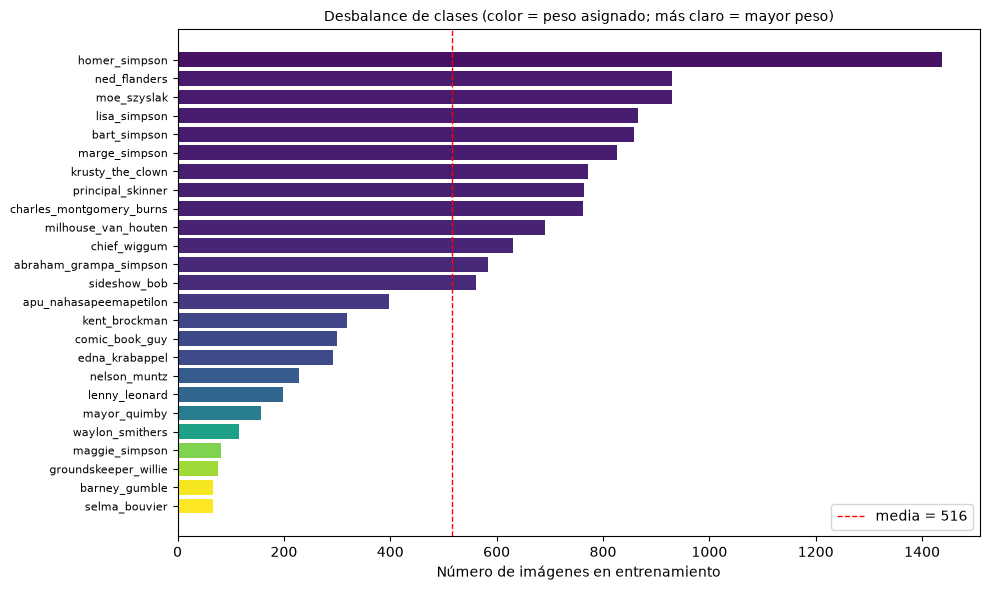

In [77]:
import matplotlib

# Distribución de imágenes por personaje en el conjunto de entrenamiento
figura, eje = plt.subplots(figsize=(10, 6))

orden = np.argsort(conteos_train)
eje.barh(
    [clases[i] for i in orden],
    conteos_train[orden],
    color=matplotlib.colormaps["viridis"](pesos[orden] / pesos.max()),
)
eje.set_xlabel("Número de imágenes en entrenamiento")
eje.set_title("Desbalance de clases (color = peso asignado; más claro = mayor peso)", fontsize=10)
eje.tick_params(axis="y", labelsize=8)
eje.axvline(
    conteos_train.mean(),
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"media = {conteos_train.mean():.0f}",
)
eje.legend()

plt.tight_layout()
plt.show()


## Fundamentos: estructura de una red neuronal profunda

### Capas y neuronas

**Qué es una neurona**

La unidad básica de la red es la neurona artificial, inspirada de forma muy simplificada en la neurona
biológica: recibe varias señales de entrada, las combina dando más importancia a unas que a otras y
produce una única señal de salida. Toda su "inteligencia" está en esos pesos, que son números que se
ajustan durante el entrenamiento.

**Cómo se organizan en capas**

Las neuronas no trabajan sueltas, sino agrupadas en capas, y cada capa recibe como entrada la salida de
la anterior. Una red **densa** o *fully connected* es aquella en la que cada neurona de una capa se
conecta con **todas** las neuronas de la capa siguiente. Un Perceptrón Multicapa es exactamente eso:
una pila de capas densas.

| Capa | Papel en la red | En este proyecto |
|---|---|---|
| **Entrada** | No calcula nada; solo define la forma del dato que entra | 49 152 valores (el vector de 128x128x3 del pre-procesamiento ejecutado) |
| **Ocultas** | Transforman progresivamente la entrada en representaciones más útiles para separar las clases | Una o varias capas densas con activación ReLU |
| **Salida** | Produce la predicción en el formato del problema | 25 neuronas con softmax, una por personaje |

**Por qué "profunda" y qué aprenden las capas ocultas**

Se llama profunda a una red con más de una capa oculta. La idea es que la composición de capas construye
una **jerarquía de representaciones**: la primera capa detecta patrones muy simples a partir de los
píxeles (zonas de color, contrastes), y cada capa posterior combina los patrones de la anterior en
conceptos más abstractos que, idealmente, terminan siendo características discriminantes entre
personajes. Ninguna de esas características se programa: emergen del ajuste de los pesos.

Se las llama "ocultas" simplemente porque no se observan desde fuera; solo vemos lo que entra y lo que
sale de la red.

**Ancho, profundidad y su costo**

Dos decisiones de diseño definen la arquitectura:

- **Profundidad** (cuántas capas ocultas): más capas permiten representar funciones más complejas, pero
  dificultan el entrenamiento y aumentan el riesgo de sobreajuste.
- **Ancho** (cuántas neuronas por capa): más neuronas dan más capacidad a cada nivel, a costa de muchos
  más parámetros.

Ese costo no es menor en nuestro caso. Como la entrada tiene 49 152 valores y la conexión es total, la
primera capa oculta concentra la enorme mayoría de los parámetros del modelo. La siguiente celda lo
cuantifica.


In [78]:
# Cuántos parámetros implica cada elección de ancho en la primera capa oculta
anchos_posibles = [64, 128, 256, 512, 1024]

tabla_costo = pd.DataFrame(
    {
        "neuronas_capa_1": anchos_posibles,
        # pesos (entrada x neuronas) + un sesgo por neurona
        "parametros_capa_1": [DIMENSION_ENTRADA * n + n for n in anchos_posibles],
    }
)
tabla_costo["parametros_salida"] = [n * NUMERO_CLASES + NUMERO_CLASES for n in anchos_posibles]
tabla_costo["total"] = tabla_costo["parametros_capa_1"] + tabla_costo["parametros_salida"]
tabla_costo["% en capa 1"] = (
    tabla_costo["parametros_capa_1"] / tabla_costo["total"] * 100
).round(1)
tabla_costo["memoria_MB"] = (tabla_costo["total"] * 4 / 1024 ** 2).round(1)

display(tabla_costo)

print(f"Dimension de entrada: {DIMENSION_ENTRADA} valores")
print(f"Neuronas de salida:   {NUMERO_CLASES} (una por personaje)")
print("\nLa primera capa oculta concentra casi todos los parámetros: es la única que se conecta con los 12 288 píxeles del vector de entrada.")


,neuronas_capa_1,parametros_capa_1,parametros_salida,total,% en capa 1,memoria_MB
0,64,786496,1625,788121,99.8,3.0
1,128,1572992,3225,1576217,99.8,6.0
2,256,3145984,6425,3152409,99.8,12.0
3,512,6291968,12825,6304793,99.8,24.1
4,1024,12583936,25625,12609561,99.8,48.1


Dimension de entrada: 12288 valores
Neuronas de salida:   25 (una por personaje)

La primera capa oculta concentra casi todos los parámetros: es la única que se conecta con los 12 288 píxeles del vector de entrada.


### Pesos, sesgos y propagación hacia adelante

**El cálculo de una neurona**

Cada neurona hace siempre lo mismo, en dos pasos:

1. **Combinación lineal (preactivación).** Multiplica cada entrada por su peso, suma todo y añade el
   sesgo:

   $$z = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b = \mathbf{w} \cdot \mathbf{x} + b$$

2. **Activación.** Pasa ese número por una función no lineal: $a = f(z)$.

**Qué significan los pesos y el sesgo**

- El **peso** $w_i$ mide cuánto influye la entrada $x_i$ en esta neurona. Un peso grande y positivo
  indica que esa entrada empuja a la neurona a activarse; uno negativo, que la inhibe; uno cercano a cero,
  que esa entrada le resulta irrelevante. En nuestro caso cada peso de la primera capa está asociado a un
  canal de color de un píxel concreto.
- El **sesgo** $b$ desplaza el umbral de activación. Sin él, toda neurona estaría obligada a dar 0 cuando
  la entrada es 0, y todas las fronteras de decisión tendrían que pasar por el origen. El sesgo le da
  libertad para activarse aun con entradas débiles, o para exigir una evidencia mayor.

**Pesos y sesgos son lo que el modelo aprende.** Todo lo demas -- número de capas, neuronas, activaciones,
learning rate -- lo fijamos nosotros antes de entrenar y por eso se llaman hiperparámetros. Los parámetros
propiamente dichos son estos números, que empiezan con valores aleatorios pequeños y se van corrigiendo.

**De una neurona a una capa: forma matricial**

Escribir el cálculo neurona por neurona sería impracticable. Como todas las neuronas de una capa hacen la
misma operación sobre la misma entrada, se agrupan sus pesos en una matriz $W$ y sus sesgos en un vector
$\mathbf{b}$, y la capa entera se calcula de un golpe:

$$\mathbf{a}^{(l)} = f\left(\mathbf{a}^{(l-1)} W^{(l)} + \mathbf{b}^{(l)}\right)$$

Esto no es solo notación elegante: es lo que permite procesar un **batch** completo de imágenes en una
sola multiplicación de matrices, que es justo la operación que GPU y CPU ejecutan de forma optimizada.

**Propagación hacia adelante (forward pass)**

Se llama así al recorrido completo: la imagen entra como vector, cada capa aplica su transformación y
pasa el resultado a la siguiente, hasta que la capa de salida produce las 25 probabilidades. Es lo que
ocurre cada vez que el modelo predice, y también el primer paso de cada iteración de entrenamiento: sin
saber qué predijo la red no se puede medir cuánto se equivocó.

La celda siguiente reproduce ese recorrido a mano con NumPy, sobre una imagen real del dataset, para ver
las formas de cada matriz y comprobar que la salida es una distribución de probabilidad.


In [79]:
# Forward pass "a mano" con una arquitectura mínima: DIMENSION_ENTRADA -> 64 -> NUMERO_CLASES
generador_pesos = np.random.default_rng(SEMILLA)
NEURONAS_DEMO = 64


def inicializar_capa(entradas, neuronas):
    """Pesos pequeños aleatorios (escala de He, la que usa Keras con ReLU) y sesgos a cero."""
    W = generador_pesos.normal(0, np.sqrt(2 / entradas), size=(entradas, neuronas)).astype(np.float32)
    b = np.zeros(neuronas, dtype=np.float32)
    return W, b


W1, b1 = inicializar_capa(DIMENSION_ENTRADA, NEURONAS_DEMO)
W2, b2 = inicializar_capa(NEURONAS_DEMO, NUMERO_CLASES)

# Una imagen real del conjunto de entrenamiento
entrada = np.asarray(X_train[0])

# Capa oculta: combinación lineal + ReLU
z1 = entrada @ W1 + b1
a1 = np.maximum(0, z1)

# Capa de salida: combinación lineal + softmax (se resta el máximo por estabilidad numérica)
z2 = a1 @ W2 + b2
exponenciales = np.exp(z2 - z2.max())
salida = exponenciales / exponenciales.sum()

recorrido = pd.DataFrame(
    [
        ("entrada (imagen aplanada)", str(entrada.shape), entrada.size),
        ("W1 (pesos capa oculta)", str(W1.shape), W1.size),
        ("b1 (sesgos capa oculta)", str(b1.shape), b1.size),
        ("z1 = entrada @ W1 + b1", str(z1.shape), z1.size),
        ("a1 = ReLU(z1)", str(a1.shape), a1.size),
        ("W2 (pesos capa salida)", str(W2.shape), W2.size),
        ("b2 (sesgos capa salida)", str(b2.shape), b2.size),
        ("z2 = a1 @ W2 + b2", str(z2.shape), z2.size),
        ("salida = softmax(z2)", str(salida.shape), salida.size),
    ],
    columns=["Paso", "Forma", "Número de valores"],
)

display(recorrido)

print(f"Parametros entrenables de esta red minima: {W1.size + b1.size + W2.size + b2.size:,}")


,Paso,Forma,Número de valores
0,entrada (imagen aplanada),"(12288,)",12288
1,W1 (pesos capa oculta),"(12288, 64)",786432
2,b1 (sesgos capa oculta),"(64,)",64
3,z1 = entrada @ W1 + b1,"(64,)",64
4,a1 = ReLU(z1),"(64,)",64
5,W2 (pesos capa salida),"(64, 25)",1600
6,b2 (sesgos capa salida),"(25,)",25
7,z2 = a1 @ W2 + b2,"(25,)",25
8,salida = softmax(z2),"(25,)",25


Parametros entrenables de esta red minima: 788,121


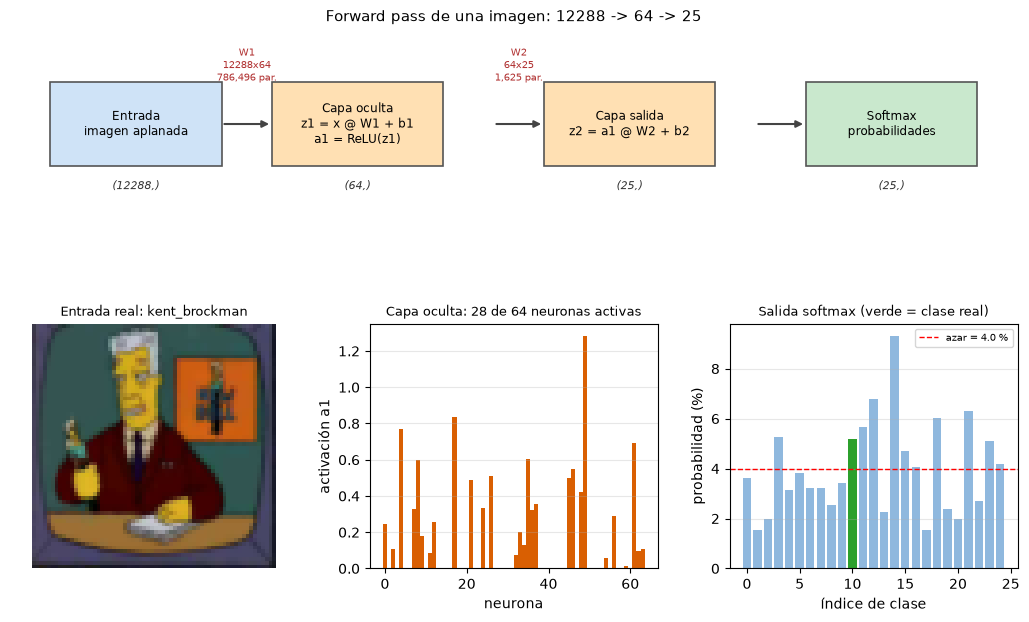


Sin entrenar, la red predice 'maggie_simpson' con 9.3 % de confianza,
cuando la clase real es 'kent_brockman', a la que asigna solo 5.2 %.

El reparto responde unicamente a los pesos aleatorios, no a la imagen: la referencia de azar es 4.0 %.

Entrenar consiste en ajustar W1, b1, W2 y b2 para que la barra verde crezca y las demas bajen.



In [80]:
# Recorrido de la señal a través de la red, paso a paso
figura = plt.figure(figsize=(13, 7))
malla = figura.add_gridspec(2, 3, height_ratios=[1, 1.25], hspace=0.45, wspace=0.25)

# --- Fila superior: esquema del flujo de datos con las formas de cada tensor ---
esquema = figura.add_subplot(malla[0, :])
esquema.set_xlim(0, 10)
esquema.set_ylim(0, 3)
esquema.axis("off")

bloques = [
    (0.4, "Entrada\nimagen aplanada", f"({DIMENSION_ENTRADA},)", "#cfe3f7"),
    (2.6, "Capa oculta\nz1 = x @ W1 + b1\na1 = ReLU(z1)", f"({NEURONAS_DEMO},)", "#ffe0b3"),
    (5.3, "Capa salida\nz2 = a1 @ W2 + b2", f"({NUMERO_CLASES},)", "#ffe0b3"),
    (7.9, "Softmax\nprobabilidades", f"({NUMERO_CLASES},)", "#c9e8cd"),
]

for x, texto, forma, color in bloques:
    esquema.add_patch(
        plt.Rectangle((x, 0.9), 1.7, 1.3, facecolor=color, edgecolor="#555", linewidth=1.2)
    )
    esquema.text(x + 0.85, 1.55, texto, ha="center", va="center", fontsize=8.5)
    esquema.text(x + 0.85, 0.6, forma, ha="center", va="center", fontsize=8, style="italic", color="#333")

pesos_entre = [
    (2.1, f"W1\n{W1.shape[0]}x{W1.shape[1]}\n{W1.size + b1.size:,} par."),
    (4.8, f"W2\n{W2.shape[0]}x{W2.shape[1]}\n{W2.size + b2.size:,} par."),
    (7.4, ""),
]
for x, etiqueta in pesos_entre:
    esquema.annotate(
        "",
        xy=(x + 0.5, 1.55),
        xytext=(x, 1.55),
        arrowprops=dict(arrowstyle="-|>", linewidth=1.5, color="#444"),
    )
    if etiqueta:
        esquema.text(x + 0.25, 2.45, etiqueta, ha="center", va="center", fontsize=7.5, color="#b03030")

esquema.set_title(
    f"Forward pass de una imagen: {DIMENSION_ENTRADA} -> {NEURONAS_DEMO} -> {NUMERO_CLASES}",
    fontsize=11,
)

# --- Abajo izquierda: la imagen que entra a la red ---
eje_imagen = figura.add_subplot(malla[1, 0])
eje_imagen.imshow(entrada.reshape(ALTO_OBJETIVO, ANCHO_OBJETIVO, 3))
eje_imagen.set_title(f"Entrada real: {clases[int(y_train_idx[0])]}", fontsize=9)
eje_imagen.axis("off")

# --- Abajo centro: activaciones de la capa oculta ---
eje_ocultas = figura.add_subplot(malla[1, 1])
colores_ocultas = ["#d95f02" if valor > 0 else "#bbbbbb" for valor in a1]
eje_ocultas.bar(range(NEURONAS_DEMO), a1, color=colores_ocultas, width=1.0)
eje_ocultas.set_title(
    f"Capa oculta: {(a1 > 0).sum()} de {NEURONAS_DEMO} neuronas activas", fontsize=9
)
eje_ocultas.set_xlabel("neurona")
eje_ocultas.set_ylabel("activación a1")
eje_ocultas.grid(alpha=0.3, axis="y")

# --- Abajo derecha: distribución de probabilidad de salida ---
eje_salida = figura.add_subplot(malla[1, 2])
clase_real = int(y_train_idx[0])
colores_salida = ["#2ca02c" if i == clase_real else "#8fb8de" for i in range(NUMERO_CLASES)]
eje_salida.bar(range(NUMERO_CLASES), salida * 100, color=colores_salida)
eje_salida.axhline(
    100 / NUMERO_CLASES,
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"azar = {100 / NUMERO_CLASES:.1f} %",
)
eje_salida.set_title("Salida softmax (verde = clase real)", fontsize=9)
eje_salida.set_xlabel("índice de clase")
eje_salida.set_ylabel("probabilidad (%)")
eje_salida.legend(fontsize=7)
eje_salida.grid(alpha=0.3, axis="y")

plt.show()

print(f"""
Sin entrenar, la red predice '{clases[int(salida.argmax())]}' con {salida.max() * 100:.1f} % de confianza,
cuando la clase real es '{clases[clase_real]}', a la que asigna solo {salida[clase_real] * 100:.1f} %.
    
El reparto responde unicamente a los pesos aleatorios, no a la imagen: la referencia de azar es {100 / NUMERO_CLASES:.1f} %.
    
Entrenar consiste en ajustar W1, b1, W2 y b2 para que la barra verde crezca y las demas bajen.
""")


### Funciones de activación

**Por qué hace falta la no linealidad**

Si se quitaran las funciones de activación, cada capa sería solo una multiplicación de matrices y la red
entera colapsaría en una sola: la composición de funciones lineales es otra función lineal. Una red de
diez capas sin activaciones tendría exactamente el mismo poder expresivo que una regresión lineal, y sería
incapaz de separar clases que no se puedan dividir con un hiperplano. La activación no lineal es lo que
permite que apilar capas sirva de algo.

**Comparación de las activaciones para las capas ocultas**

| Función | Fórmula | Rango | Ventaja | Problema |
|---|---|---|---|---|
| **Sigmoide** | $1/(1+e^{-z})$ | (0, 1) | Interpretable como probabilidad | Se satura: para $\|z\|$ grande el gradiente tiende a 0 y el aprendizaje se detiene |
| **Tanh** | $(e^z-e^{-z})/(e^z+e^{-z})$ | (-1, 1) | Centrada en cero, converge mejor que la sigmoide | También se satura en los extremos |
| **ReLU** | $\max(0, z)$ | [0, inf) | Gradiente constante 1 para $z>0$: no se satura; muy barata de calcular; produce activaciones dispersas | "Neuronas muertas": si una unidad queda siempre en $z<0$, su gradiente es 0 y no vuelve a aprender |

**Elección: ReLU en las capas ocultas.** El problema de la saturación es decisivo. En una red profunda,
los gradientes se multiplican capa a capa al retropropagarse; si cada factor es menor que 1 -- como pasa
con sigmoide, cuya derivada máxima es 0,25 -- el gradiente se desvanece antes de llegar a las primeras
capas, que son justamente las que deben aprender de los píxeles. ReLU mantiene el gradiente en 1 en toda
su zona activa, y además su cálculo es una simple comparación, lo que acelera el entrenamiento. Es el
valor por defecto razonable para capas ocultas, y de ahí partimos.

**Elección: softmax en la salida.** La capa final no busca una no linealidad cualquiera, sino convertir 25
números sin escala definida en una distribución de probabilidad:

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{25} e^{z_j}}$$

Sus dos propiedades son las que necesita un problema multiclase de etiqueta única: todas las salidas son
positivas y **suman exactamente 1**. Eso introduce competencia entre clases -- si sube la probabilidad de
un personaje, baja la de los demas -- que es correcto aquí, porque cada imagen tiene un único personaje.
Si el problema fuera multietiqueta habría que usar sigmoides independientes en la salida.


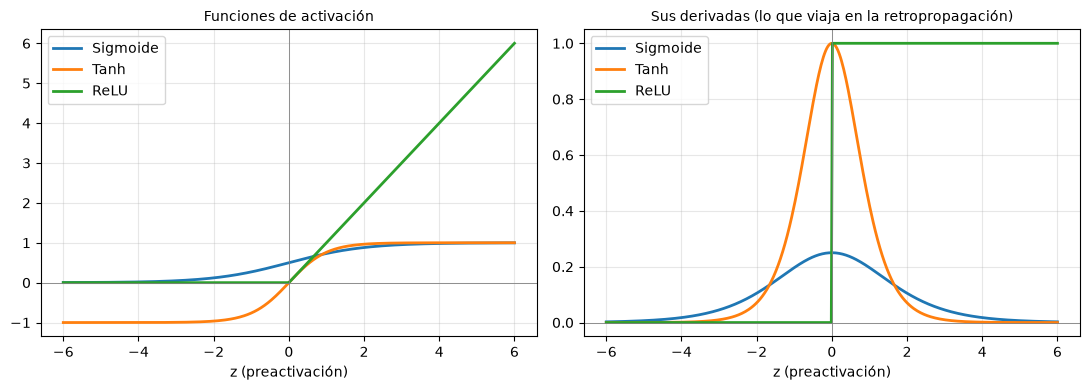

En el gráfico de la derecha se ve el problema de la saturación: las derivadas de sigmoide y tanh
caen a cero en los extremos (el gradiente se desvanece), mientras que la de ReLU vale 1 para
todo z > 0. Nótese además que la derivada de la sigmoide no supera 0.25.


In [81]:
z = np.linspace(-6, 6, 400)

activaciones = {
    "Sigmoide": (1 / (1 + np.exp(-z)), lambda s: s * (1 - s)),
    "Tanh": (np.tanh(z), lambda s: 1 - s ** 2),
    "ReLU": (np.maximum(0, z), lambda s: (z > 0).astype(float)),
}

figura, ejes = plt.subplots(1, 2, figsize=(11, 4))

for nombre, (valores, derivada) in activaciones.items():
    ejes[0].plot(z, valores, label=nombre, linewidth=2)
    ejes[1].plot(z, derivada(valores), label=nombre, linewidth=2)

ejes[0].set_title("Funciones de activación", fontsize=10)
ejes[1].set_title("Sus derivadas (lo que viaja en la retropropagación)", fontsize=10)

for eje in ejes:
    eje.axhline(0, color="gray", linewidth=0.6)
    eje.axvline(0, color="gray", linewidth=0.6)
    eje.set_xlabel("z (preactivación)")
    eje.grid(alpha=0.3)
    eje.legend()

plt.tight_layout()
plt.show()

print(
    "En el gráfico de la derecha se ve el problema de la saturación: las derivadas de sigmoide y tanh"
    "\ncaen a cero en los extremos (el gradiente se desvanece), mientras que la de ReLU vale 1 para"
    "\ntodo z > 0. Nótese además que la derivada de la sigmoide no supera 0.25."
)


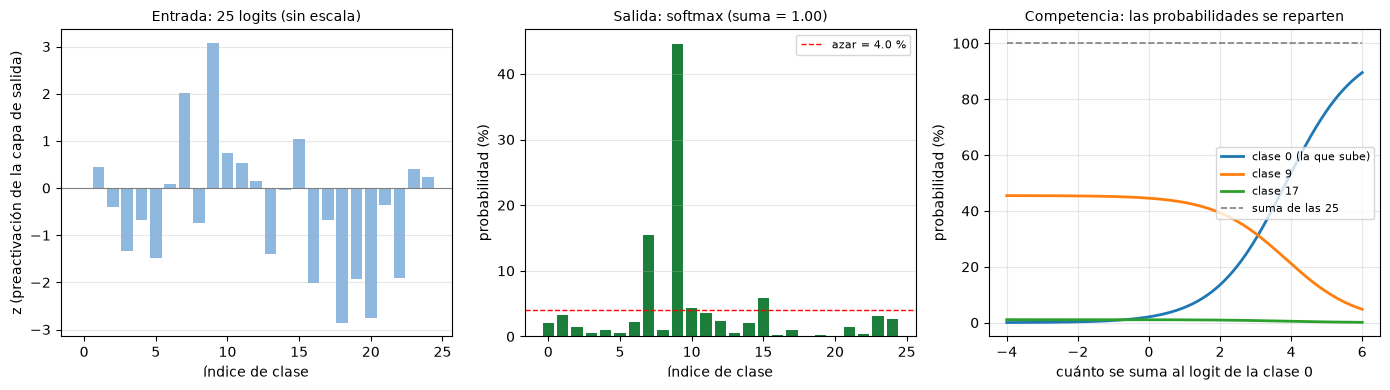

Softmax no se puede dibujar junto a ReLU o tanh porque no transforma un número en otro:
toma el vector completo de 25 logits y devuelve una distribución. El denominador -- la suma
de todas las exponenciales -- es lo que acopla las salidas entre si.

Clase predicha: 9 con 44.6 % de probabilidad   |   suma de las 25 salidas = 1.000000
En el gráfico de la derecha se ve la propiedad clave para etiqueta única: al crecer el logit
de una clase, su probabilidad sube y la de las demas baja, mientras la suma se mantiene en 100 %.


In [82]:
# Softmax se gráfica aparte: no es una activación elemento a elemento como las anteriores,
# sino una función vectorial que mira las 25 salidas a la vez y las convierte en una distribución.
generador = np.random.default_rng(7)
logits_demo = generador.normal(0, 1.5, NUMERO_CLASES)
logits_demo[9] += 4.0  # una clase claramente favorecida por la red


def softmax(z, temperatura=1.0):
    """Softmax numéricamente estable: se resta el máximo antes de exponenciar."""
    escalado = np.asarray(z, dtype=float) / temperatura
    exponenciales = np.exp(escalado - escalado.max())
    return exponenciales / exponenciales.sum()


probabilidades_demo = softmax(logits_demo)

figura, ejes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Los logits: números sin escala definida, positivos y negativos
ejes[0].bar(range(NUMERO_CLASES), logits_demo, color="#8fb8de")
ejes[0].axhline(0, color="gray", linewidth=0.8)
ejes[0].set_title("Entrada: 25 logits (sin escala)", fontsize=10)
ejes[0].set_ylabel("z (preactivación de la capa de salida)")

# 2. La misma información después de softmax: probabilidades que suman 1
ejes[1].bar(range(NUMERO_CLASES), probabilidades_demo * 100, color="#1b7f3b")
ejes[1].axhline(
    100 / NUMERO_CLASES,
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"azar = {100 / NUMERO_CLASES:.1f} %",
)
ejes[1].set_title(
    f"Salida: softmax (suma = {probabilidades_demo.sum():.2f})", fontsize=10
)
ejes[1].set_ylabel("probabilidad (%)")
ejes[1].legend(fontsize=8)

for eje in ejes[:2]:
    eje.set_xlabel("índice de clase")
    eje.grid(alpha=0.3, axis="y")

# 3. La competencia entre clases: subir el logit de una hunde a todas las demas
desplazamientos = np.linspace(-4, 6, 200)
seguidas = [0, 9, 17]  # tres clases a las que seguir la pista
curvas = np.array(
    [softmax(np.concatenate(([logits_demo[0] + d], logits_demo[1:]))) for d in desplazamientos]
)

for indice in seguidas:
    ejes[2].plot(
        desplazamientos,
        curvas[:, indice] * 100,
        linewidth=2,
        label=f"clase {indice}" + (" (la que sube)" if indice == 0 else ""),
    )

ejes[2].plot(
    desplazamientos,
    curvas.sum(axis=1) * 100,
    color="gray",
    linestyle="--",
    linewidth=1.2,
    label="suma de las 25",
)
ejes[2].set_title("Competencia: las probabilidades se reparten", fontsize=10)
ejes[2].set_xlabel("cuánto se suma al logit de la clase 0")
ejes[2].set_ylabel("probabilidad (%)")
ejes[2].grid(alpha=0.3)
ejes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(
    "Softmax no se puede dibujar junto a ReLU o tanh porque no transforma un número en otro:"
    "\ntoma el vector completo de 25 logits y devuelve una distribución. El denominador -- la suma"
    "\nde todas las exponenciales -- es lo que acopla las salidas entre si."
)
print(
    f"\nClase predicha: {int(probabilidades_demo.argmax())} con {probabilidades_demo.max() * 100:.1f} %"
    f" de probabilidad   |   suma de las 25 salidas = {probabilidades_demo.sum():.6f}"
)
print(
    "En el gráfico de la derecha se ve la propiedad clave para etiqueta única: al crecer el logit"
    "\nde una clase, su probabilidad sube y la de las demas baja, mientras la suma se mantiene en 100 %."
)


### Función de pérdida, backpropagation y optimizador

El forward pass produce una predicción, pero por sí solo no enseña nada. El aprendizaje necesita tres
piezas más: una forma de **medir** el error, una forma de **repartir la culpa** de ese error entre los
parámetros, y una **regla** para corregirlos.

**1. Función de pérdida: entropía cruzada categórica**

Mide la distancia entre la distribución predicha por softmax y el vector one-hot real. Como el one-hot
tiene un 1 en la clase correcta y 0 en el resto, la suma se reduce a un único término:

$$L = -\sum_{i=1}^{25} y_i \log(\hat{y}_i) = -\log(\hat{y}_{\text{clase correcta}})$$

Es decir: la pérdida de un ejemplo depende **solo de la probabilidad que la red asignó a la clase
verdadera**. Si le dio 0,99, la pérdida es casi 0; si le dio 0,01, la pérdida se dispara. Ese crecimiento
logarítmico penaliza con dureza los errores cometidos con mucha confianza, que es el comportamiento
deseable. La pérdida del batch es el promedio de las pérdidas individuales -- y es ahí donde `class_weight`
interviene, ponderando cada término según la frecuencia de su clase.

Por qué no usar accuracy como función a minimizar: el accuracy es escalonado, su gradiente es cero en casi
todas partes y no distingue entre acertar con 0,51 o con 0,99. Sirve para interpretar resultados, no para
optimizar. Por eso se monitorean ambos: se **optimiza** la pérdida y se **lee** el accuracy.

**2. Backpropagation: de dónde viene el error**

Conocida la pérdida, hace falta saber cuánto contribuyó cada uno de los parámetros. Eso es la derivada
parcial $\partial L / \partial w$, y calcularla directamente para cientos de miles de pesos sería
inviable. La retropropagación lo resuelve aplicando la **regla de la cadena** en sentido inverso: parte
del error en la salida y lo propaga hacia atras capa por capa, reutilizando en cada paso lo ya calculado
en la capa posterior. Esto es lo que hace posible entrenar redes grandes, y también la razón de que la
derivada de la activación importe tanto: aparece como factor multiplicativo en cada capa que se atraviesa
(de ahí el desvanecimiento del gradiente con sigmoide y la ventaja de ReLU).

El resultado es el **gradiente**: un vector que indica, para cada parámetro, en qué dirección habría que
moverlo para que la pérdida aumente. Se avanza en la dirección contraria.

**3. Optimizador: cómo se corrigen los pesos**

La regla básica es el **descenso del gradiente**:

$$w \leftarrow w - \eta \frac{\partial L}{\partial w}$$

donde $\eta$ es la **tasa de aprendizaje** (learning rate), el tamaño del paso. Demasiado grande y el
entrenamiento oscila o diverge; demasiado pequeño y avanza con una lentitud inútil. En la práctica no se
calcula el gradiente sobre todo el dataset (caro) ni sobre un solo ejemplo (ruidoso), sino sobre **batches**
de unas decenas o centenas de imágenes: es el descenso del gradiente por mini-lotes. Una **época** es una
pasada completa por el conjunto de entrenamiento, es decir, muchas actualizaciones de pesos.

**Elección: Adam.** Mejora el descenso del gradiente clásico en dos aspectos: acumula un **momento** de los
gradientes anteriores, lo que suaviza las oscilaciones, y adapta el tamaño del paso **para cada parámetro**
según la magnitud típica de su gradiente. En la práctica converge más rápido y es mucho menos sensible a
la elección inicial del learning rate, razón por la que se usa como punto de partida en la mayoría de los
trabajos. Se parte de su valor por defecto, 0,001, y su efecto se contrasta en la experimentación.

**El ciclo completo de entrenamiento**

Para cada batch, y repitiendolo época tras época:

`forward pass` -> `calcular la perdida` -> `backpropagation` -> `el optimizador actualiza los pesos`


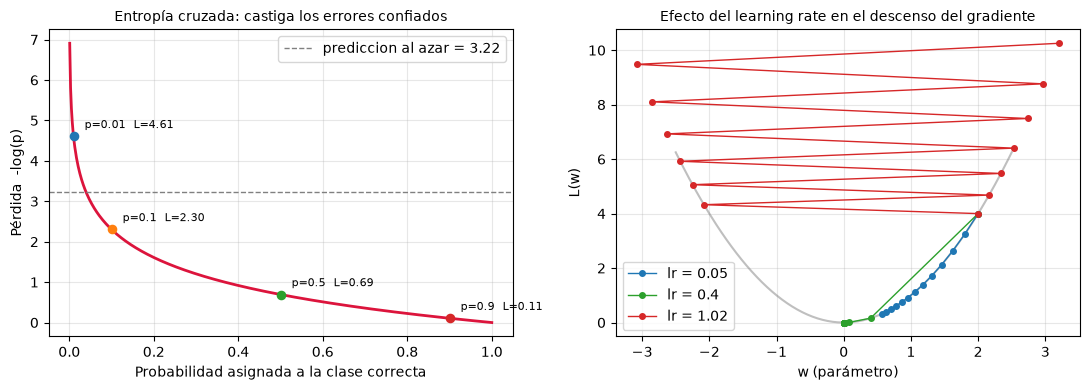

Perdida esperada de un modelo sin entrenar (1/25 a cada clase): 3.219
Es el valor de referencia con el que debería arrancar el entrenamiento en la primera época.

En el gráfico de la derecha: un lr pequeño (azul) converge pero lento, uno adecuado (verde)
llega rápido al mínimo, y uno demasiado grande (rojo) se aleja y diverge.


In [83]:
# Pérdida de un ejemplo según la probabilidad asignada a la clase correcta
probabilidades = np.linspace(0.001, 1.0, 500)
perdidas = -np.log(probabilidades)

figura, ejes = plt.subplots(1, 2, figsize=(11, 4))

ejes[0].plot(probabilidades, perdidas, color="crimson", linewidth=2)
ejes[0].set_xlabel("Probabilidad asignada a la clase correcta")
ejes[0].set_ylabel("Pérdida  -log(p)")
ejes[0].set_title("Entropía cruzada: castiga los errores confiados", fontsize=10)
ejes[0].grid(alpha=0.3)

for probabilidad in (0.01, 0.1, 0.5, 0.9):
    ejes[0].scatter([probabilidad], [-np.log(probabilidad)], zorder=3, s=35)
    ejes[0].annotate(
        f"p={probabilidad}  L={-np.log(probabilidad):.2f}",
        (probabilidad, -np.log(probabilidad)),
        textcoords="offset points",
        xytext=(8, 6),
        fontsize=8,
    )

# Referencias del problema: pérdida esperada al predecir al azar entre 25 clases
perdida_azar = -np.log(1 / NUMERO_CLASES)
ejes[0].axhline(
    perdida_azar,
    color="gray",
    linestyle="--",
    linewidth=1,
    label=f"prediccion al azar = {perdida_azar:.2f}",
)
ejes[0].legend()

# Efecto del learning rate sobre el descenso del gradiente en una parabola L(w) = w^2
ejes[1].plot(np.linspace(-2.5, 2.5, 200), np.linspace(-2.5, 2.5, 200) ** 2, color="gray", alpha=0.5)

for tasa, color in ((0.05, "tab:blue"), (0.4, "tab:green"), (1.02, "tab:red")):
    w = 2.0
    trayectoria = [w]
    for _ in range(12):
        w = w - tasa * 2 * w  # derivada de w^2
        trayectoria.append(w)
    trayectoria = np.array(trayectoria)
    ejes[1].plot(
        trayectoria,
        trayectoria ** 2,
        "o-",
        color=color,
        markersize=4,
        linewidth=1,
        label=f"lr = {tasa}",
    )

ejes[1].set_xlabel("w (parámetro)")
ejes[1].set_ylabel("L(w)")
ejes[1].set_title("Efecto del learning rate en el descenso del gradiente", fontsize=10)
ejes[1].grid(alpha=0.3)
ejes[1].legend()

plt.tight_layout()
plt.show()

print(f"Perdida esperada de un modelo sin entrenar (1/{NUMERO_CLASES} a cada clase): {perdida_azar:.3f}")
print("Es el valor de referencia con el que debería arrancar el entrenamiento en la primera época.")
print(
    "\nEn el gráfico de la derecha: un lr pequeño (azul) converge pero lento, uno adecuado (verde)"
    "\nllega rápido al mínimo, y uno demasiado grande (rojo) se aleja y diverge."
)


## Modelo base: Perceptrón Multicapa (MLP)

### Configuración y alcance de la implementación

La implementación toma un vector de **49.152** valores (`128 × 128 × 3`) y crea un modelo base con dos capas ocultas de **512 → 256** neuronas, ReLU, Batch Normalization y Dropout de 0,3. La salida tiene 25 neuronas con `softmax`; el entrenamiento usa `categorical_crossentropy`, Adam con tasa `1e-3`, batch de 128, hasta 60 épocas y pesos por clase. Todos esos valores se declaran en las celdas de arquitectura, compilación y entrenamiento que siguen.

El modelo base no se presenta como una elección arbitraria: se compara con cinco variaciones que cambian una sola decisión por vez (número de capas, activación, tasa de aprendizaje o batch). La regla de selección es F1 macro de validación. En la salida guardada de este notebook, E2 (`1024 → 512 → 256`) fue seleccionado con F1 macro de validación 0,4975 y 51.002.393 parámetros; esa cifra corresponde a esta corrida CPU a 128 × 128.

### Definición de la arquitectura

La arquitectura del modelo base traduce a código lo descrito en los fundamentos: una capa de entrada con
el vector aplanado, dos capas ocultas densas con ReLU y una capa de salida softmax con una neurona por
personaje. Entre medio se intercalan dos mecanismos de regularización:

- **Normalización por lotes (`BatchNormalization`).** Reescala las activaciones de cada capa para que
  mantengan una media y una varianza estables a lo largo del entrenamiento. Evita que la distribución que
  ve cada capa se desplace batch a batch, lo que permite usar una tasa de aprendizaje mayor y acelera la
  convergencia.
- **`Dropout`.** Durante el entrenamiento apaga al azar una fracción de las neuronas de la capa. Así
  ninguna neurona puede depender de la presencia de otra en particular y la red se ve obligada a
  distribuir la representación. Es la defensa principal contra el sobreajuste en una red densa con
  millones de parámetros y apenas unas 13 000 imágenes de entrenamiento.

La función `construir_mlp` deja como parámetros los tres factores que se modificarán en la
experimentación (número y ancho de las capas ocultas, activación y tasa de dropout), de modo que todas
las configuraciones comparadas se generen exactamente con el mismo código.

In [84]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Fija las semillas de Python, NumPy y TensorFlow para que el entrenamiento sea reproducible
keras.utils.set_random_seed(SEMILLA)

NEURONAS_OCULTAS = (512, 256)
ACTIVACION = "relu"
TASA_DROPOUT = 0.3


def construir_mlp(
    neuronas_ocultas=NEURONAS_OCULTAS,
    activacion=ACTIVACION,
    tasa_dropout=TASA_DROPOUT,
    dimension_entrada=DIMENSION_ENTRADA,
    numero_clases=NUMERO_CLASES,
    nombre="mlp_base",
):
    """Construye un Perceptrón Multicapa: entrada aplanada -> capas ocultas densas
    (activación + BatchNorm + Dropout) -> salida softmax con una neurona por clase."""
    modelo = keras.Sequential(name=nombre)
    modelo.add(layers.Input(shape=(dimension_entrada,), name="entrada"))

    for posicion, neuronas in enumerate(neuronas_ocultas, start=1):
        modelo.add(layers.Dense(neuronas, activation=activacion, name=f"oculta_{posicion}"))
        modelo.add(layers.BatchNormalization(name=f"norm_{posicion}"))
        modelo.add(layers.Dropout(tasa_dropout, name=f"dropout_{posicion}"))

    modelo.add(layers.Dense(numero_clases, activation="softmax", name="salida"))
    return modelo


modelo_base = construir_mlp()

capas_texto = " -> ".join(str(n) for n in NEURONAS_OCULTAS)
print(f"TensorFlow {tf.__version__}")
print(f"Arquitectura: {DIMENSION_ENTRADA} -> {capas_texto} -> {NUMERO_CLASES}")
print(f"Activacion oculta: {ACTIVACION}   |   Dropout: {TASA_DROPOUT}   |   Salida: softmax")

TensorFlow 2.21.0
Arquitectura: 12288 -> 512 -> 256 -> 25
Activacion oculta: relu   |   Dropout: 0.3   |   Salida: softmax


### Justificación técnica de la arquitectura y de los hiperparámetros iniciales

Cada decisión del modelo base responde al problema concreto ya descrito: 49 152 entradas, 25 clases
fuertemente desbalanceadas y 12.909 imágenes de entrenamiento tras la partición.

| Hiperparámetro | Valor elegido | Justificación |
|---|---|---|
| **Capas ocultas** | 2 | Con una sola capa la red es prácticamente un clasificador lineal sobre píxeles; con muchas más, en un dataset de este tamaño el sobreajuste y el costo crecen más rápido que la ganancia. Dos capas permiten componer dos niveles de abstracción y son el punto de partida habitual para un MLP sobre imágenes pequeñas |
| **Neuronas por capa** | 512 y 256 | Un embudo decreciente: con la entrada de 49.152 valores, la primera capa concentra ≈ 25,2 millones de parámetros; la segunda refina esa representación antes de la salida. Reducir progresivamente obliga a la red a resumir en lugar de copiar la entrada |
| **Activación oculta** | ReLU | No se satura, su derivada vale 1 para z > 0 y es la más barata de calcular (ver "Funciones de activación"). Con sigmoide o tanh, dos capas ya bastan para que el gradiente empiece a atenuarse |
| **Activación de salida** | Softmax (25 neuronas) | Convierte las puntuaciones en una distribución de probabilidad que suma 1, que es la forma correcta para una clasificación multiclase de etiqueta única |
| **Dropout** | 0,3 | Valor intermedio: con millones de parámetros para 13 000 imágenes el riesgo de memorización es alto, pero una tasa de 0,5 sobre un MLP que además ya pierde la estructura espacial retrasa demasiado la convergencia |
| **BatchNormalization** | Tras cada capa oculta | Estabiliza la escala de las activaciones y permite un learning rate mayor sin que el entrenamiento se vuelva inestable |
| **Optimizador** | Adam | Adapta el paso por parámetro combinando momento y escalado según la magnitud histórica del gradiente. Con entradas muy dispares (píxeles de fondo casi constantes junto a zonas de alto contraste) converge bastante más rápido que el SGD puro |
| **Tasa de aprendizaje** | 0,001 | Valor por defecto de Adam y punto de partida estándar; se contrasta explícitamente en la experimentación |
| **Función de pérdida** | Categorical crossentropy | Corresponde a etiquetas one-hot con salida softmax |
| **Tamaño de batch** | 128 | Compromiso entre el ruido del gradiente (batches pequeños) y la estabilidad y el aprovechamiento de memoria (batches grandes) |
| **`class_weight`** | Pesos balanceados | Compensa la razón de desbalance ≈ 22:1 descrita en "Tratamiento del desbalance de clases" |

### Compilación del modelo

In [85]:
TASA_APRENDIZAJE = 1e-3


def compilar(modelo, tasa_aprendizaje=TASA_APRENDIZAJE):
    """Asocia al modelo el optimizador, la función de pérdida y las métricas a monitorear."""
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=tasa_aprendizaje),
        loss="categorical_crossentropy",
        metrics=[
            keras.metrics.CategoricalAccuracy(name="accuracy"),
            keras.metrics.TopKCategoricalAccuracy(k=3, name="top_3"),
        ],
    )
    return modelo


compilar(modelo_base)

configuracion_base = pd.DataFrame(
    [
        ("Optimizador", "Adam"),
        ("Tasa de aprendizaje", TASA_APRENDIZAJE),
        ("Función de pérdida", "categorical_crossentropy"),
        ("Metricas", "accuracy, top_3"),
        ("Neuronas ocultas", str(NEURONAS_OCULTAS)),
        ("Activación oculta", ACTIVACION),
        ("Dropout", TASA_DROPOUT),
        ("Neuronas de salida", NUMERO_CLASES),
    ],
    columns=["Elemento", "Valor"],
)

display(configuracion_base)

,Elemento,Valor
0,Optimizador,Adam
1,Tasa de aprendizaje,0.001
2,Función de pérdida,categorical_crossentropy
3,Metricas,"accuracy, top_3"
4,Neuronas ocultas,"(512, 256)"
5,Activación oculta,relu
6,Dropout,0.3
7,Neuronas de salida,25


### Resumen del modelo

In [86]:
modelo_base.summary()

# Reparto de los parámetros entre las capas
detalle_capas = pd.DataFrame(
    [
        (
            capa.name,
            capa.__class__.__name__,
            str(capa.output.shape),
            int(sum(np.prod(peso.shape) for peso in capa.trainable_weights)),
        )
        for capa in modelo_base.layers
    ],
    columns=["capa", "tipo", "forma_salida", "parametros"],
)
detalle_capas["% del total"] = (
    detalle_capas["parametros"] / max(detalle_capas["parametros"].sum(), 1) * 100
).round(1)

display(detalle_capas)

total_parametros = int(detalle_capas["parametros"].sum())
print(f"Parametros entrenables: {total_parametros:,}")
print(f"Imagenes de entrenamiento: {len(X_train):,}")
print(f"Razon parametros / ejemplos: {total_parametros / len(X_train):.0f} a 1")
print(
    "\nLa primera capa oculta concentra la mayor parte de los parámetros porque es la única"
    f"\nconectada a los {DIMENSION_ENTRADA} valores del vector de entrada. Esa razon de"
    "\nparámetros por ejemplo es la que justifica el Dropout y la parada temprana."
)

Model: "mlp_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta_1 (Dense)                │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ norm_1 (BatchNormalization)     │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_2 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ norm_2 (BatchNormalization)     │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 25)             │         6,425 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,432,793 (24.54 MB)

 Trainable params: 6,431,257 (24.53 MB)

 Non-trainable params: 1,536 (6.00 KB)

,capa,tipo,forma_salida,parametros,% del total
0,oculta_1,Dense,"(None, 512)",6291968,97.8
1,norm_1,BatchNormalization,"(None, 512)",1024,0.0
2,dropout_1,Dropout,"(None, 512)",0,0.0
3,oculta_2,Dense,"(None, 256)",131328,2.0
4,norm_2,BatchNormalization,"(None, 256)",512,0.0
5,dropout_2,Dropout,"(None, 256)",0,0.0
6,salida,Dense,"(None, 25)",6425,0.1


Parametros entrenables: 6,431,257
Imagenes de entrenamiento: 12,909
Razon parametros / ejemplos: 498 a 1

La primera capa oculta concentra la mayor parte de los parámetros porque es la única
conectada a los 12288 valores del vector de entrada. Esa razon de
parámetros por ejemplo es la que justifica el Dropout y la parada temprana.


## Entrenamiento del modelo

### Configuración del entrenamiento

El entrenamiento se controla con tres decisiones y tres *callbacks*:

- **Épocas.** Se fija un máximo alto (60) y se deja que la parada temprana decida el número real. Fijar
  un número bajo a mano corre el riesgo de cortar antes de converger; uno alto sin control lleva a
  sobreajustar.
- **Batch de 128.** Cada actualización de pesos promedia el gradiente de 128 imágenes.
- **`class_weight`.** Los pesos calculados en el pre-procesamiento entran aquí: ponderan la pérdida de
  cada ejemplo según lo escasa que sea su clase.
- **Datos anclados a la RAM del host.** Antes de entrenar, las cuatro matrices se convierten a tensores
  dentro de `tf.device("/CPU:0")`. Si se pasan como arrays de NumPy, Keras los materializa en el
  dispositivo por defecto —la GPU— y sube las matrices completas a la VRAM. A 64 x 64 eso pasa
  desapercibido, pero a 128 x 128 son 3 GB de datos que se suman a los pesos y a los estados de Adam de
  cada configuración, y una tarjeta de 8 GB agota la memoria a mitad de la experimentación. Ancladas al
  host, cada paso copia únicamente su lote.

| Callback | Qué hace | Por qué |
|---|---|---|
| `EarlyStopping` | Detiene el entrenamiento si `val_loss` no mejora en 8 épocas y restaura los pesos de la mejor época | Evita seguir entrenando cuando el modelo ya solo memoriza; `restore_best_weights` garantiza quedarse con la mejor versión, no con la última |
| `ReduceLROnPlateau` | Divide el learning rate a la mitad si `val_loss` se estanca 4 épocas | Permite pasos grandes al principio y ajustes finos al final, cerca del mínimo |
| `ModelCheckpoint` | Guarda en `models/` la mejor época según `val_loss` | Deja el modelo persistido en disco, reutilizable sin reentrenar |

La métrica que gobierna las decisiones es `val_loss` y no `val_accuracy`: con clases desbalanceadas la
accuracy de validación puede mantenerse plana mientras la pérdida ya empeora.

In [87]:
from pathlib import Path

EPOCAS_MAXIMAS = 60
TAMANO_BATCH = 128
DIRECTORIO_MODELOS = Path("../models")
DIRECTORIO_MODELOS.mkdir(parents=True, exist_ok=True)


def construir_callbacks(ruta_modelo, paciencia=8):
    """Parada temprana, reducción del learning rate y guardado de la mejor época."""
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=paciencia,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=4,
            min_lr=1e-5,
            verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=str(ruta_modelo),
            monitor="val_loss",
            save_best_only=True,
            verbose=0,
        ),
    ]


import time

import tensorflow as tf

# Los datos se fijan en la RAM del host antes de entrenar. Si se pasan como arrays
# de NumPy, Keras los convierte en tensores sobre el dispositivo por defecto -la GPU-
# y sube las matrices COMPLETAS a la VRAM: a 128x128 son 2,4 GB de train mas 0,6 GB
# de validacion que se acumulan con los pesos y los estados de Adam de cada
# configuracion, y la tarjeta de 8 GB se queda sin memoria al llegar a E5 con
# "Dst tensor is not initialized". Anclados al host, fit() y predict() copian solo
# el lote de cada paso: el pico de VRAM baja de mas de 4,8 GB a menos de 3 GB.
with tf.device("/CPU:0"):
    X_train = tf.convert_to_tensor(X_train)
    y_train = tf.convert_to_tensor(y_train)
    X_val = tf.convert_to_tensor(X_val)
    y_val = tf.convert_to_tensor(y_val)

# El tiempo se cronometra aquí para el resumen de rendimiento del final del notebook
inicio_entrenamiento_base = time.perf_counter()
historial_base = modelo_base.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCAS_MAXIMAS,
    batch_size=TAMANO_BATCH,
    class_weight=pesos_por_clase,
    callbacks=construir_callbacks(DIRECTORIO_MODELOS / "mlp_base.keras"),
    verbose=2,
)

segundos_entrenamiento_base = time.perf_counter() - inicio_entrenamiento_base

epocas_ejecutadas = len(historial_base.history["loss"])
mejor_epoca = int(np.argmin(historial_base.history["val_loss"])) + 1
print(f"\nEpocas ejecutadas: {epocas_ejecutadas} de {EPOCAS_MAXIMAS} (parada temprana)")
print(f"Mejor epoca segun val_loss: {mejor_epoca}")
print(
    f"Tiempo de entrenamiento: {segundos_entrenamiento_base:.1f} s"
    f"  ({segundos_entrenamiento_base / epocas_ejecutadas:.2f} s por epoca)"
)

Epoch 1/60
101/101 - 7s - 71ms/step - accuracy: 0.1536 - loss: 3.1997 - top_3: 0.3268 - val_accuracy: 0.1843 - val_loss: 3.3374 - val_top_3: 0.3572 - learning_rate: 0.0010
Epoch 2/60
101/101 - 6s - 60ms/step - accuracy: 0.2486 - loss: 2.6069 - top_3: 0.4618 - val_accuracy: 0.2367 - val_loss: 2.6992 - val_top_3: 0.4830 - learning_rate: 0.0010
Epoch 3/60
101/101 - 6s - 59ms/step - accuracy: 0.2959 - loss: 2.3670 - top_3: 0.5118 - val_accuracy: 0.1577 - val_loss: 3.1739 - val_top_3: 0.3442 - learning_rate: 0.0010
Epoch 4/60
101/101 - 6s - 61ms/step - accuracy: 0.3147 - loss: 2.2002 - top_3: 0.5446 - val_accuracy: 0.1750 - val_loss: 3.2461 - val_top_3: 0.3522 - learning_rate: 0.0010
Epoch 5/60
101/101 - 6s - 59ms/step - accuracy: 0.3389 - loss: 2.0788 - top_3: 0.5664 - val_accuracy: 0.1605 - val_loss: 2.9653 - val_top_3: 0.4226 - learning_rate: 0.0010
Epoch 6/60

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
101/101 - 6s - 60ms/step - accuracy: 0.3411 - loss: 

### Curvas de aprendizaje del modelo base

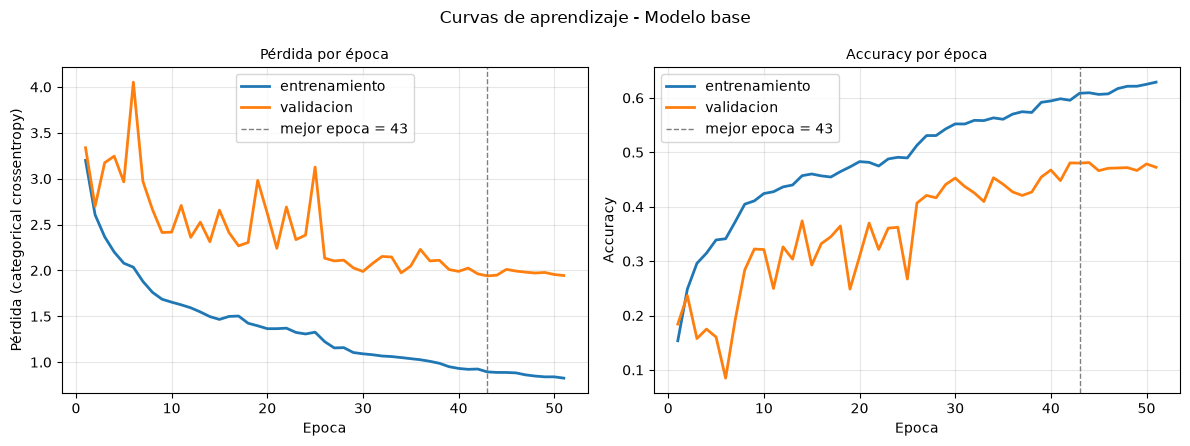

In [88]:
def graficar_curvas(historial, titulo="Modelo base"):
    """Dibuja pérdida y accuracy de entrenamiento y validación por época."""
    registro = historial.history if hasattr(historial, "history") else historial
    epocas = range(1, len(registro["loss"]) + 1)
    epoca_optima = int(np.argmin(registro["val_loss"])) + 1

    figura, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

    ejes[0].plot(epocas, registro["loss"], label="entrenamiento", linewidth=2)
    ejes[0].plot(epocas, registro["val_loss"], label="validacion", linewidth=2)
    ejes[0].set_ylabel("Pérdida (categorical crossentropy)")
    ejes[0].set_title("Pérdida por época", fontsize=10)

    ejes[1].plot(epocas, registro["accuracy"], label="entrenamiento", linewidth=2)
    ejes[1].plot(epocas, registro["val_accuracy"], label="validacion", linewidth=2)
    ejes[1].set_ylabel("Accuracy")
    ejes[1].set_title("Accuracy por época", fontsize=10)

    for eje in ejes:
        eje.axvline(
            epoca_optima,
            color="gray",
            linestyle="--",
            linewidth=1,
            label=f"mejor epoca = {epoca_optima}",
        )
        eje.set_xlabel("Epoca")
        eje.grid(alpha=0.3)
        eje.legend()

    figura.suptitle(f"Curvas de aprendizaje - {titulo}")
    plt.tight_layout()
    plt.show()


graficar_curvas(historial_base)

### Interpretación de las curvas

In [89]:
from sklearn.metrics import f1_score

registro = historial_base.history
indice_optimo = int(np.argmin(registro["val_loss"]))

# F1 macro en validación con los pesos restaurados de la mejor época
probabilidades_val = modelo_base.predict(X_val, batch_size=256, verbose=0)
predicciones_val = probabilidades_val.argmax(axis=1)
f1_macro_val = f1_score(y_val_idx, predicciones_val, average="macro")

diagnostico = pd.DataFrame(
    [
        ("Épocas ejecutadas", len(registro["loss"])),
        ("Mejor época (val_loss)", indice_optimo + 1),
        ("Pérdida entrenamiento", round(registro["loss"][indice_optimo], 4)),
        ("Pérdida validación", round(registro["val_loss"][indice_optimo], 4)),
        ("Accuracy entrenamiento", round(registro["accuracy"][indice_optimo], 4)),
        ("Accuracy validación", round(registro["val_accuracy"][indice_optimo], 4)),
        ("Top-3 accuracy validación", round(registro["val_top_3"][indice_optimo], 4)),
        ("F1 macro validación", round(float(f1_macro_val), 4)),
        (
            "Brecha train - val (accuracy)",
            round(registro["accuracy"][indice_optimo] - registro["val_accuracy"][indice_optimo], 4),
        ),
    ],
    columns=["Indicador", "Valor"],
)

display(diagnostico)

brecha = registro["accuracy"][indice_optimo] - registro["val_accuracy"][indice_optimo]
if brecha > 0.15:
    lectura = "sobreajuste claro: la red memoriza el entrenamiento y generaliza bastante peor"
elif brecha > 0.05:
    lectura = "sobreajuste moderado, contenido por el Dropout y la parada temprana"
else:
    lectura = "sin sobreajuste apreciable; las dos curvas evolucionan juntas"

print(f"Brecha train - val en accuracy: {brecha:.3f} -> {lectura}.")
print(
    f"Accuracy de validacion ({registro['val_accuracy'][indice_optimo]:.3f}) frente a los baselines:"
    f" azar 0.040 y clase mayoritaria 0.114."
)

,Indicador,Valor
0,Épocas ejecutadas,51.0000
1,Mejor época (val_loss),43.0000
2,Pérdida entrenamiento,0.8941
3,Pérdida validación,1.9406
4,Accuracy entrenamiento,0.6085
5,Accuracy validación,0.4802
6,Top-3 accuracy validación,0.6884
7,F1 macro validación,0.4382
8,Brecha train - val (accuracy),0.1283


Brecha train - val en accuracy: 0.128 -> sobreajuste moderado, contenido por el Dropout y la parada temprana.
Accuracy de validacion (0.480) frente a los baselines: azar 0.040 y clase mayoritaria 0.114.


**Cómo se leen estas curvas**

Hay tres cosas que mirar en los gráficos anteriores:

1. **La separación entre las dos curvas de pérdida.** Mientras ambas bajan juntas, la red está
   aprendiendo estructura real del problema. En cuanto la pérdida de validación se aplana o sube
   mientras la de entrenamiento sigue bajando, lo que la red gana ya es memorización de las imágenes
   concretas del conjunto de entrenamiento: ese punto de cruce es el sobreajuste y es justo lo que
   detecta `EarlyStopping`.
2. **La época en que la validación deja de mejorar** (línea vertical punteada). Es la que se conserva,
   porque `restore_best_weights=True` devuelve los pesos de ese momento, y no los del final.
3. **El efecto de la regularización.** El Dropout hace que la curva de entrenamiento vaya *por debajo* de
   su potencial —parte de la red está apagada en cada paso— y por eso la brecha entre train y validación
   es menor de la que tendría el mismo MLP sin regularizar. El escalón que a veces se ve en las curvas
   corresponde a `ReduceLROnPlateau` bajando el learning rate.

La tabla de arriba resume el diagnóstico: la brecha entre entrenamiento y validación cuantifica el
sobreajuste, y la distancia frente a los baselines (4,0 % al azar, 11,4 % prediciendo siempre la clase
mayoritaria) confirma que el modelo efectivamente aprendió algo del problema.

## Experimentación: comparación de configuraciones



### Diseño de los experimentos

La comparación sigue el principio de **un factor a la vez**: cada experimento cambia exactamente un
hiperparámetro respecto del modelo base y deja el resto idéntico —misma semilla, misma partición, mismos
pesos por clase, mismos callbacks—. Así, cualquier diferencia en la métrica de validación es atribuible
al factor modificado y no a la interacción de varios cambios simultáneos.

| Exp. | Factor que cambia | Configuración | Qué pone a prueba |
|---|---|---|---|
| **Base** | — | 2 capas (512, 256), ReLU, lr 0,001, batch 128 | Referencia |
| **E1** | Profundidad | 1 capa oculta (512) | Si una sola capa basta, o si la segunda aporta |
| **E2** | Profundidad y ancho | 3 capas (1024, 512, 256) | Si más capacidad mejora o solo sobreajusta |
| **E3** | Activación | 2 capas (512, 256) con tanh | El costo de una activación que se satura |
| **E4** | Tasa de aprendizaje | lr 0,0001 | Convergencia lenta pero estable frente al valor por defecto |
| **E5** | Tamaño de batch | batch 512 | Menos ruido por actualización y menos actualizaciones por época |

Las métricas registradas para cada configuración son la **accuracy** de validación —comparable con los
baselines— y el **F1 macro** de validación, que promedia sin ponderar las 25 clases y es la métrica que
realmente refleja si el modelo atiende a los personajes minoritarios. La selección final se hace por F1
macro, por el desbalance ya documentado.

Para acotar el costo, los experimentos usan un máximo de 35 épocas y una paciencia de 6 (el modelo base
se entrenó con 60 y paciencia 8); todos comparten exactamente ese presupuesto entre sí.

In [90]:
import time

EPOCAS_EXPERIMENTO = 35
PACIENCIA_EXPERIMENTO = 6

# Cada entrada cambia UN solo factor respecto del modelo base
experimentos = [
    {"nombre": "E1 - 1 capa (512)", "neuronas": (512,)},
    {"nombre": "E2 - 3 capas (1024,512,256)", "neuronas": (1024, 512, 256)},
    {"nombre": "E3 - activación tanh", "activacion": "tanh"},
    {"nombre": "E4 - learning rate 1e-4", "tasa_aprendizaje": 1e-4},
    {"nombre": "E5 - batch 512", "batch": 512},
]


def entrenar_configuracion(
    nombre,
    neuronas=NEURONAS_OCULTAS,
    activacion=ACTIVACION,
    tasa_dropout=TASA_DROPOUT,
    tasa_aprendizaje=TASA_APRENDIZAJE,
    batch=TAMANO_BATCH,
    epocas=EPOCAS_EXPERIMENTO,
    paciencia=PACIENCIA_EXPERIMENTO,
):
    """Entrena una configuración y devuelve el modelo, su historial y sus métricas de validación."""
    keras.utils.set_random_seed(SEMILLA)  # misma inicialización para todas las configuraciones

    identificador = nombre.split(" - ")[0].strip().lower().replace(" ", "_")
    modelo = construir_mlp(
        neuronas_ocultas=neuronas,
        activacion=activacion,
        tasa_dropout=tasa_dropout,
        nombre=f"mlp_{identificador}",
    )
    compilar(modelo, tasa_aprendizaje=tasa_aprendizaje)

    inicio = time.time()
    historial = modelo.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epocas,
        batch_size=batch,
        class_weight=pesos_por_clase,
        callbacks=construir_callbacks(
            DIRECTORIO_MODELOS / f"mlp_{identificador}.keras", paciencia=paciencia
        ),
        verbose=0,
    )
    duracion = time.time() - inicio

    indice = int(np.argmin(historial.history["val_loss"]))
    predicciones = modelo.predict(X_val, batch_size=256, verbose=0).argmax(axis=1)

    resultado = {
        "experimento": nombre,
        "capas_ocultas": len(neuronas),
        "neuronas": " - ".join(str(n) for n in neuronas),
        "activacion": activacion,
        "dropout": tasa_dropout,
        "learning_rate": tasa_aprendizaje,
        "batch": batch,
        "epocas": len(historial.history["loss"]),
        "mejor_epoca": indice + 1,
        "parametros": int(modelo.count_params()),
        "val_loss": round(historial.history["val_loss"][indice], 4),
        "val_accuracy": round(historial.history["val_accuracy"][indice], 4),
        "val_f1_macro": round(float(f1_score(y_val_idx, predicciones, average="macro")), 4),
        "segundos": round(duracion, 1),
    }
    return modelo, historial, resultado


modelos = {}
historiales = {}
resultados = []

# El modelo base ya está entrenado: se incorpora a la comparación sin volver a entrenarlo
resultados.append(
    {
        "experimento": "Base - 2 capas (512,256)",
        "capas_ocultas": len(NEURONAS_OCULTAS),
        "neuronas": " - ".join(str(n) for n in NEURONAS_OCULTAS),
        "activacion": ACTIVACION,
        "dropout": TASA_DROPOUT,
        "learning_rate": TASA_APRENDIZAJE,
        "batch": TAMANO_BATCH,
        "epocas": len(historial_base.history["loss"]),
        "mejor_epoca": indice_optimo + 1,
        "parametros": int(modelo_base.count_params()),
        "val_loss": round(registro["val_loss"][indice_optimo], 4),
        "val_accuracy": round(registro["val_accuracy"][indice_optimo], 4),
        "val_f1_macro": round(float(f1_macro_val), 4),
        "segundos": np.nan,
    }
)
modelos["Base - 2 capas (512,256)"] = modelo_base
historiales["Base - 2 capas (512,256)"] = historial_base.history

for configuracion in experimentos:
    nombre = configuracion.pop("nombre")
    print(f"Entrenando {nombre} ...")
    modelo, historial, resultado = entrenar_configuracion(nombre, **configuracion)
    modelos[nombre] = modelo
    historiales[nombre] = historial.history
    resultados.append(resultado)
    print(
        f"   val_accuracy={resultado['val_accuracy']:.4f}"
        f"   val_f1_macro={resultado['val_f1_macro']:.4f}"
        f"   epocas={resultado['epocas']}   {resultado['segundos']:.0f} s"
    )

tabla_experimentos = pd.DataFrame(resultados)
display(tabla_experimentos)

Entrenando E1 - 1 capa (512) ...

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 2.
   val_accuracy=0.2797   val_f1_macro=0.2525   epocas=8   42 s
Entrenando E2 - 3 capas (1024,512,256) ...

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 27: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 33: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
Restoring model weights from the end of the best epoch: 35.
   val_accuracy=0.5139   val_f1_macro=0.4830   epocas=35   421 s
Entrenando E3 - activación tanh ...

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Epoch 8: early stopping
Restoring model weights from the end of the best ep

,experimento,capas_ocultas,neuronas,activacion,dropout,learning_rate,batch,epocas,mejor_epoca,parametros,val_loss,val_accuracy,val_f1_macro,segundos
0,"Base - 2 capas (512,256)",2,512 - 256,relu,0.3,0.0010,128,51,43,6432793,1.9406,0.4802,0.4382,NaN
1,E1 - 1 capa (512),1,512,relu,0.3,0.0010,128,8,2,6306841,2.6019,0.2797,0.2525,42.5
2,"E2 - 3 capas (1024,512,256)",3,1024 - 512 - 256,relu,0.3,0.0010,128,35,35,13253657,1.7742,0.5139,0.4830,421.0
3,E3 - activación tanh,2,512 - 256,tanh,0.3,0.0010,128,8,2,6432793,3.9779,0.0341,0.0068,44.9
4,E4 - learning rate 1e-4,2,512 - 256,relu,0.3,0.0001,128,28,22,6432793,2.1033,0.4328,0.3933,191.4
5,E5 - batch 512,2,512 - 256,relu,0.3,0.0010,512,14,8,6432793,2.6589,0.2757,0.2237,53.7


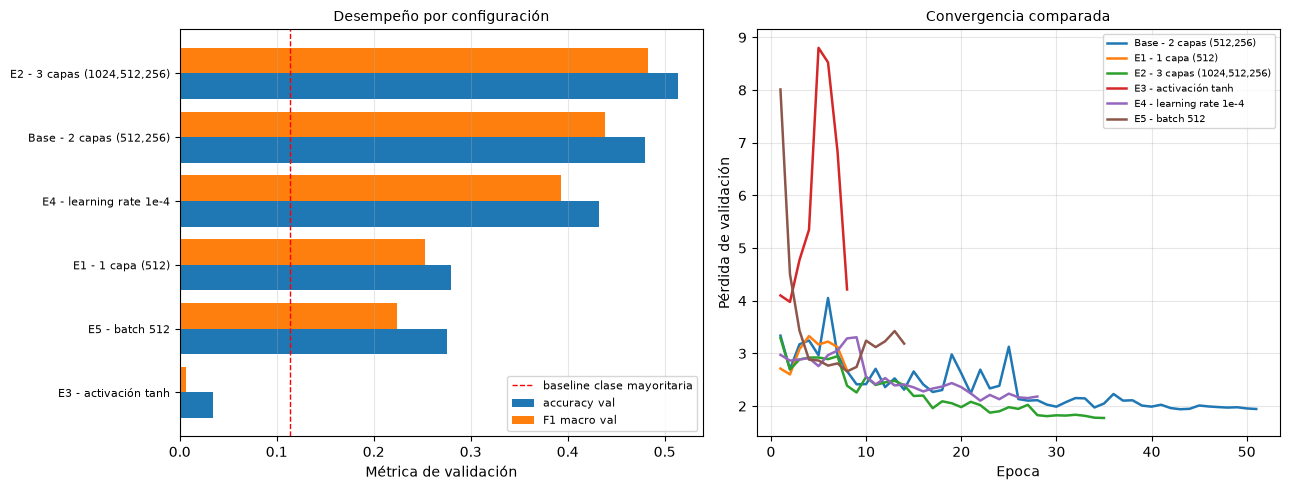

In [91]:
# Comparación visual de las configuraciones por accuracy y F1 macro de validación
orden_resultados = tabla_experimentos.sort_values("val_f1_macro", ascending=True)
posiciones = np.arange(len(orden_resultados))

figura, ejes = plt.subplots(1, 2, figsize=(13, 5))

ejes[0].barh(posiciones - 0.2, orden_resultados["val_accuracy"], height=0.4, label="accuracy val")
ejes[0].barh(posiciones + 0.2, orden_resultados["val_f1_macro"], height=0.4, label="F1 macro val")
ejes[0].set_yticks(posiciones)
ejes[0].set_yticklabels(orden_resultados["experimento"], fontsize=8)
ejes[0].axvline(0.114, color="red", linestyle="--", linewidth=1, label="baseline clase mayoritaria")
ejes[0].set_xlabel("Métrica de validación")
ejes[0].set_title("Desempeño por configuración", fontsize=10)
ejes[0].legend(fontsize=8)
ejes[0].grid(alpha=0.3, axis="x")

for nombre, registro_historial in historiales.items():
    ejes[1].plot(
        range(1, len(registro_historial["val_loss"]) + 1),
        registro_historial["val_loss"],
        label=nombre,
        linewidth=1.8,
    )
ejes[1].set_xlabel("Epoca")
ejes[1].set_ylabel("Pérdida de validación")
ejes[1].set_title("Convergencia comparada", fontsize=10)
ejes[1].grid(alpha=0.3)
ejes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

### Efecto del número de capas ocultas y de neuronas

,experimento,capas_ocultas,neuronas,parametros,val_accuracy,val_f1_macro,epocas,segundos,parametros_millones
0,E1 - 1 capa (512),1,512,6306841,0.2797,0.2525,8,42.5,6.31
1,"Base - 2 capas (512,256)",2,512 - 256,6432793,0.4802,0.4382,51,NaN,6.43
2,"E2 - 3 capas (1024,512,256)",3,1024 - 512 - 256,13253657,0.5139,0.4830,35,421.0,13.25


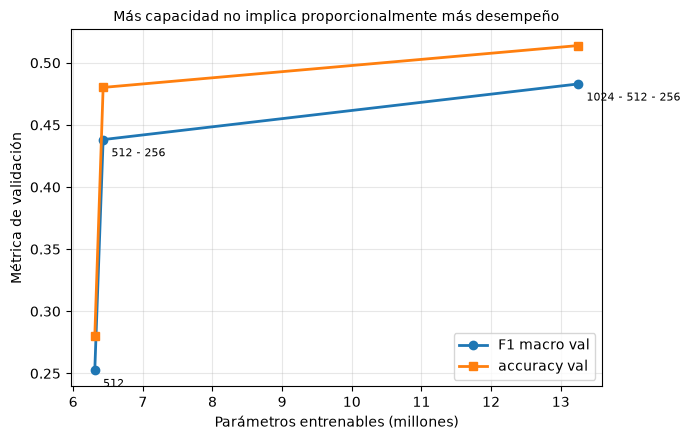

In [92]:
# Solo las configuraciones que cambian la arquitectura (misma activación, lr y batch que el base)
comparacion_arquitectura = tabla_experimentos[
    tabla_experimentos["experimento"].str.contains("Base|E1|E2")
][["experimento", "capas_ocultas", "neuronas", "parametros", "val_accuracy", "val_f1_macro", "epocas", "segundos"]]
comparacion_arquitectura = comparacion_arquitectura.sort_values("parametros").reset_index(drop=True)

comparacion_arquitectura["parametros_millones"] = (
    comparacion_arquitectura["parametros"] / 1e6
).round(2)

display(comparacion_arquitectura)

figura, eje = plt.subplots(figsize=(7, 4.5))
eje.plot(
    comparacion_arquitectura["parametros_millones"],
    comparacion_arquitectura["val_f1_macro"],
    marker="o",
    linewidth=2,
    label="F1 macro val",
)
eje.plot(
    comparacion_arquitectura["parametros_millones"],
    comparacion_arquitectura["val_accuracy"],
    marker="s",
    linewidth=2,
    label="accuracy val",
)
for _, fila in comparacion_arquitectura.iterrows():
    eje.annotate(
        fila["neuronas"],
        (fila["parametros_millones"], fila["val_f1_macro"]),
        textcoords="offset points",
        xytext=(6, -12),
        fontsize=8,
    )
eje.set_xlabel("Parámetros entrenables (millones)")
eje.set_ylabel("Métrica de validación")
eje.set_title("Más capacidad no implica proporcionalmente más desempeño", fontsize=10)
eje.grid(alpha=0.3)
eje.legend()
plt.tight_layout()
plt.show()

**Lectura.** El aumento de capacidad tiene rendimientos decrecientes muy marcados. Pasar de una a dos
capas ocultas añade una etapa de composición que sí se nota, pero la tercera capa de E2 multiplica los
parámetros sin una mejora proporcional en validación: la capacidad extra se emplea en ajustar mejor el
entrenamiento, no en generalizar. La razón es estructural y no depende del tamaño de la red: al aplanar
la imagen, todas las capas densas trabajan sobre píxeles sueltos, sin noción de vecindad. Añadir
neuronas aumenta el número de combinaciones lineales de píxeles disponibles, pero ninguna de ellas
recupera la información espacial que se perdió en el aplanado, que es el cuello de botella real de este
enfoque.

El costo, en cambio, sí crece: cada millón de parámetros adicionales se paga en memoria y en tiempo por
época (columna `segundos`), y aumenta la razón parámetros/ejemplos, que es exactamente lo que empuja al
sobreajuste.

### Efecto de la función de activación

,experimento,activacion,val_loss,val_accuracy,val_f1_macro,epocas,mejor_epoca
0,"Base - 2 capas (512,256)",relu,1.9406,0.4802,0.4382,51,43
1,E3 - activación tanh,tanh,3.9779,0.0341,0.0068,8,2


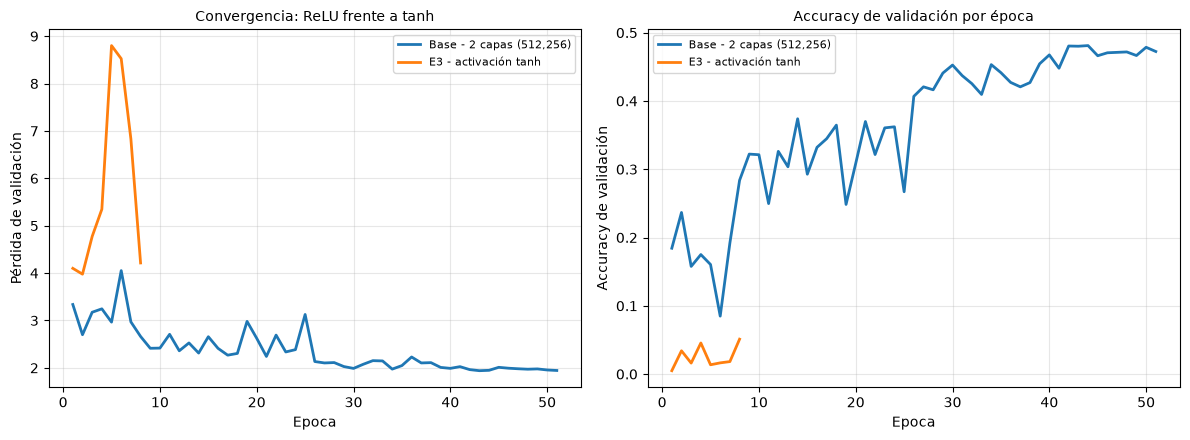

In [93]:
comparacion_activacion = tabla_experimentos[
    tabla_experimentos["experimento"].str.contains("Base|E3")
][["experimento", "activacion", "val_loss", "val_accuracy", "val_f1_macro", "epocas", "mejor_epoca"]]

display(comparacion_activacion.reset_index(drop=True))

figura, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

for nombre in comparacion_activacion["experimento"]:
    registro_historial = historiales[nombre]
    epocas_rango = range(1, len(registro_historial["loss"]) + 1)
    ejes[0].plot(epocas_rango, registro_historial["val_loss"], linewidth=2, label=nombre)
    ejes[1].plot(epocas_rango, registro_historial["val_accuracy"], linewidth=2, label=nombre)

ejes[0].set_ylabel("Pérdida de validación")
ejes[0].set_title("Convergencia: ReLU frente a tanh", fontsize=10)
ejes[1].set_ylabel("Accuracy de validación")
ejes[1].set_title("Accuracy de validación por época", fontsize=10)

for eje in ejes:
    eje.set_xlabel("Epoca")
    eje.grid(alpha=0.3)
    eje.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Lectura.** La comparación aísla exactamente lo discutido en "Funciones de activación". La tanh está
acotada en (-1, 1) y su derivada cae hacia cero en los extremos: cuando una neurona se satura, el
gradiente que la atraviesa se atenúa y esa unidad deja de aprender durante varias épocas. ReLU no tiene
ese techo —su derivada vale 1 para todo z > 0— y además produce activaciones dispersas, más baratas de
calcular.

En la práctica esto se traduce en que la curva de validación con ReLU cae antes y llega más abajo, con
el mismo presupuesto de épocas. La tanh no es incapaz de resolver el problema, pero necesita más épocas
para alcanzar un punto comparable, lo que confirma la elección de ReLU para el modelo base.

### Efecto del número de épocas, el tamaño de batch y la tasa de aprendizaje

,experimento,learning_rate,batch,epocas,mejor_epoca,val_loss,val_accuracy,val_f1_macro,segundos
0,"Base - 2 capas (512,256)",0.0010,128,51,43,1.9406,0.4802,0.4382,NaN
1,E4 - learning rate 1e-4,0.0001,128,28,22,2.1033,0.4328,0.3933,191.4
2,E5 - batch 512,0.0010,512,14,8,2.6589,0.2757,0.2237,53.7


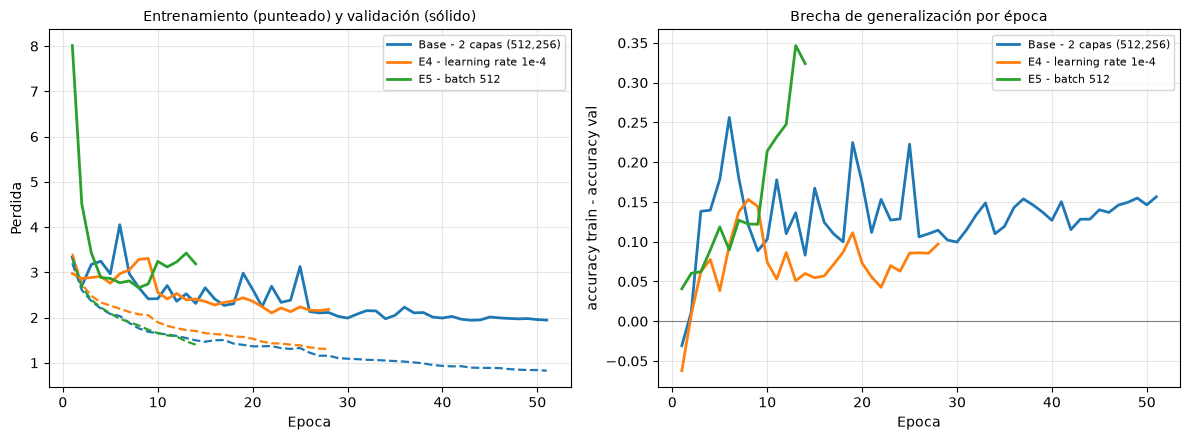

In [94]:
comparacion_optimizacion = tabla_experimentos[
    tabla_experimentos["experimento"].str.contains("Base|E4|E5")
][["experimento", "learning_rate", "batch", "epocas", "mejor_epoca", "val_loss", "val_accuracy", "val_f1_macro", "segundos"]]

display(comparacion_optimizacion.reset_index(drop=True))

figura, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

for nombre in comparacion_optimizacion["experimento"]:
    registro_historial = historiales[nombre]
    epocas_rango = range(1, len(registro_historial["loss"]) + 1)
    ejes[0].plot(epocas_rango, registro_historial["loss"], linewidth=1.6, linestyle="--")
    ejes[0].plot(
        epocas_rango,
        registro_historial["val_loss"],
        linewidth=2,
        label=nombre,
        color=ejes[0].lines[-1].get_color(),
    )
    ejes[1].plot(
        epocas_rango,
        np.array(registro_historial["accuracy"]) - np.array(registro_historial["val_accuracy"]),
        linewidth=2,
        label=nombre,
    )

ejes[0].set_ylabel("Perdida")
ejes[0].set_title("Entrenamiento (punteado) y validación (sólido)", fontsize=10)
ejes[1].axhline(0, color="gray", linewidth=0.8)
ejes[1].set_ylabel("accuracy train - accuracy val")
ejes[1].set_title("Brecha de generalización por época", fontsize=10)

for eje in ejes:
    eje.set_xlabel("Epoca")
    eje.grid(alpha=0.3)
    eje.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Lectura.** Los tres hiperparámetros de optimización están acoplados y conviene leerlos juntos:

- **Tasa de aprendizaje.** Con 1e-4 (E4) cada paso es diez veces más corto: el descenso es más suave y
  estable, pero dentro del mismo presupuesto de épocas el modelo queda más lejos del mínimo. Es el
  comportamiento esperado según la ilustración del descenso del gradiente de los fundamentos: un
  learning rate demasiado pequeño no diverge, simplemente no llega a tiempo.
- **Tamaño de batch.** Con batch 512 (E5) cada época contiene cuatro veces menos actualizaciones de
  pesos. El gradiente es menos ruidoso —las curvas se ven más lisas— pero se avanza menos por época, y
  ese ruido que se pierde tiene un efecto regularizador que también se pierde.
- **Número de épocas.** No es un valor elegido a mano: la columna `mejor_epoca` muestra dónde la
  validación tocó su mínimo en cada configuración, y `epocas` cuánto se entrenó antes de que
  `EarlyStopping` cortará. La distancia entre ambas columnas es justamente la paciencia consumida.

El panel derecho muestra la brecha entre accuracy de entrenamiento y de validación época a época: cuando
esa curva crece de forma sostenida, cada época adicional se está invirtiendo en memorizar, no en
generalizar.

### Selección del modelo final

In [95]:
# El criterio de selección es el F1 macro de validación, no la accuracy:
# promedia las 25 clases sin ponderar y penaliza ignorar a los personajes minoritarios
ranking = tabla_experimentos.sort_values("val_f1_macro", ascending=False).reset_index(drop=True)
display(ranking[["experimento", "val_accuracy", "val_f1_macro", "val_loss", "parametros", "epocas"]])

nombre_final = ranking.loc[0, "experimento"]
modelo_final = modelos[nombre_final]

print(f"Configuracion seleccionada: {nombre_final}")
print(f"  accuracy validacion : {ranking.loc[0, 'val_accuracy']:.4f}")
print(f"  F1 macro validacion : {ranking.loc[0, 'val_f1_macro']:.4f}")
print(f"  parametros          : {ranking.loc[0, 'parametros']:,}")
print(f"\nDiferencia en F1 macro frente a la segunda ({ranking.loc[1, 'experimento']}): {ranking.loc[0, 'val_f1_macro'] - ranking.loc[1, 'val_f1_macro']:+.4f}")

ruta_modelo_final = DIRECTORIO_MODELOS / "mlp_final.keras"
modelo_final.save(ruta_modelo_final)
print(f"\nModelo final guardado en: {ruta_modelo_final}")

,experimento,val_accuracy,val_f1_macro,val_loss,parametros,epocas
0,"E2 - 3 capas (1024,512,256)",0.5139,0.4830,1.7742,13253657,35
1,"Base - 2 capas (512,256)",0.4802,0.4382,1.9406,6432793,51
2,E4 - learning rate 1e-4,0.4328,0.3933,2.1033,6432793,28
3,E1 - 1 capa (512),0.2797,0.2525,2.6019,6306841,8
4,E5 - batch 512,0.2757,0.2237,2.6589,6432793,14
5,E3 - activación tanh,0.0341,0.0068,3.9779,6432793,8


Configuracion seleccionada: E2 - 3 capas (1024,512,256)
  accuracy validacion : 0.5139
  F1 macro validacion : 0.4830
  parametros          : 13,253,657

Diferencia en F1 macro frente a la segunda (Base - 2 capas (512,256)): +0.0448

Modelo final guardado en: ..\models\mlp_final.keras


**Justificación de la decisión.** La configuración elegida es la que maximiza el **F1 macro de
validación**, y no la que maximiza la accuracy. Con una razón de desbalance de 22:1, la accuracy premia
acertar en los personajes abundantes y apenas se resiente si el modelo ignora por completo a los
escasos; el F1 macro, al promediar las 25 clases sin ponderarlas, sí lo penaliza. Como el objetivo
declarado es reconocer personajes —los 25, no solo a Homero—, esa es la métrica coherente con el
problema.

Cuando dos configuraciones quedan prácticamente empatadas en F1 macro, el criterio de desempate es el
número de parámetros: a igual desempeño se prefiere la red más pequeña, por costo de entrenamiento y por
menor riesgo de sobreajuste.

El modelo seleccionado es el que se evalúa en la sección siguiente sobre el **conjunto opuesto** al
usado para entrenar (`conjunto_evaluacion`, derivado en la primera celda), que hasta este punto no se ha
tocado ni para entrenar ni para elegir hiperparámetros.

## Evaluación y métricas de desempeño

El conjunto de evaluación es el **opuesto** al seleccionado en la primera celda: si se entrenó con
`train`, aquí se usa `test`, y si se entrenó con `test`, aquí se usa `train`. Esa inversión es lo que
garantiza que la comprobación se haga sobre imágenes que el modelo nunca vio.

Se procesa ahora **con exactamente las mismas funciones** que el conjunto de entrenamiento: el mismo
índice de rutas, el mismo redimensionado a 128 x 128, la misma normalización por 255, el mismo aplanado
y —esto es lo crítico— el mismo diccionario `clase_a_indice`. Si las clases se volvieran a numerar a
partir del conjunto de evaluación, el índice 3 podría corresponder a un personaje distinto del que vio
el modelo durante el entrenamiento y toda la evaluación quedaría invalidada.

In [96]:
# Carga y pre-procesamiento del conjunto de evaluación (el opuesto al de entrenamiento),
# reutilizando exactamente las mismas funciones
print(f'Entrenado con "{conjunto}"  ->  evaluando con "{conjunto_evaluacion}": {direccion_evaluacion}')

datos_test = construir_indice(direccion_evaluacion)

# El mapeo de clases es el del entrenamiento: no se recalcula
clases_test = sorted(datos_test["personaje"].unique())
if clases_test != clases:
    raise ValueError(
        f'Las clases del conjunto "{conjunto_evaluacion}" no coinciden con las de "{conjunto}"'
    )

datos_test["etiqueta"] = datos_test["personaje"].map(clase_a_indice)

imagenes_test = np.stack([cargar_y_redimensionar(ruta) for ruta in datos_test["ruta"]])
X_test = (imagenes_test.astype(np.float32) / VALOR_MAXIMO_PIXEL).reshape(len(datos_test), -1)
y_test_idx = datos_test["etiqueta"].to_numpy()
y_test = np.eye(NUMERO_CLASES, dtype=np.float32)[y_test_idx]

comprobaciones_test = pd.DataFrame(
    [
        (f'Mismas clases que "{conjunto}"', len(clases_test), NUMERO_CLASES, clases_test == clases),
        ("Dimensión de entrada", X_test.shape[1], DIMENSION_ENTRADA, X_test.shape[1] == DIMENSION_ENTRADA),
        ("Tipo de dato", str(X_test.dtype), "float32", X_test.dtype == np.float32),
        (
            "Rango [0, 1]",
            f"[{X_test.min():.3f}, {X_test.max():.3f}]",
            "[0.0, 1.0]",
            bool(X_test.min() >= 0.0 and X_test.max() <= 1.0),
        ),
        ("Etiquetas alineadas", len(y_test_idx), X_test.shape[0], len(y_test_idx) == X_test.shape[0]),
    ],
    columns=["Comprobacion", "Obtenido", "Esperado", "Correcto"],
)

display(comprobaciones_test)
print(f'Conjunto de evaluacion "{conjunto_evaluacion}": {len(datos_test)} imagenes')
print(f"X_test: {X_test.shape}   y_test: {y_test.shape}")

Entrenado con "train"  ->  evaluando con "test": C:\Users\Laptop\Desktop\Trabajos\LosSimpsonsDataset\test


,Comprobacion,Obtenido,Esperado,Correcto
0,"Mismas clases que ""train""",25,25,True
1,Dimensión de entrada,12288,12288,True
2,Tipo de dato,float32,float32,True
3,"Rango [0, 1]","[0.000, 1.000]","[0.0, 1.0]",True
4,Etiquetas alineadas,3937,3937,True


Conjunto de evaluacion "test": 3937 imagenes
X_test: (3937, 12288)   y_test: (3937, 25)


### Accuracy global sobre el conjunto de prueba

In [97]:
perdida_test, accuracy_test, top3_test = modelo_final.evaluate(
    X_test, y_test, batch_size=256, verbose=0
)

probabilidades_test = modelo_final.predict(X_test, batch_size=256, verbose=0)
predicciones_test = probabilidades_test.argmax(axis=1)
confianza_test = probabilidades_test.max(axis=1)

# Baselines definidos en "Definición del problema de clasificación"
conteos_test = np.bincount(y_test_idx, minlength=NUMERO_CLASES)
baseline_azar = 1 / NUMERO_CLASES
baseline_mayoritaria = conteos_test.max() / conteos_test.sum()
f1_macro_test = f1_score(y_test_idx, predicciones_test, average="macro")
f1_ponderado_test = f1_score(y_test_idx, predicciones_test, average="weighted")

comparacion_baselines = pd.DataFrame(
    [
        ("Clasificador aleatorio", baseline_azar, "-"),
        ("Clase mayoritaria siempre", baseline_mayoritaria, "-"),
        ("MLP final", accuracy_test, round(float(f1_macro_test), 4)),
    ],
    columns=["Modelo", "Accuracy test", "F1 macro test"],
)
comparacion_baselines["Accuracy test"] = comparacion_baselines["Accuracy test"].round(4)

display(comparacion_baselines)

print(f"Perdida en test      : {perdida_test:.4f}")
print(f"Accuracy en test     : {accuracy_test:.4f}")
print(f"Top-3 accuracy       : {top3_test:.4f}")
print(f"F1 macro en test     : {f1_macro_test:.4f}")
print(f"F1 ponderado en test : {f1_ponderado_test:.4f}")
print(
    f"\nMejora sobre el azar: x{accuracy_test / baseline_azar:.1f}   |   "
    f"sobre la clase mayoritaria: x{accuracy_test / baseline_mayoritaria:.1f}"
)

,Modelo,Accuracy test,F1 macro test
0,Clasificador aleatorio,0.0400,-
1,Clase mayoritaria siempre,0.1143,-
2,MLP final,0.5331,0.5032


Perdida en test      : 1.6837
Accuracy en test     : 0.5331
Top-3 accuracy       : 0.7333
F1 macro en test     : 0.5032
F1 ponderado en test : 0.5339

Mejora sobre el azar: x13.3   |   sobre la clase mayoritaria: x4.7


### Precision, Recall y F1-Score por clase

In [98]:
from sklearn.metrics import classification_report, precision_recall_fscore_support

reporte = classification_report(
    y_test_idx,
    predicciones_test,
    labels=range(NUMERO_CLASES),
    target_names=clases,
    digits=3,
    zero_division=0,
)
print(reporte)

precision, recall, f1, soporte = precision_recall_fscore_support(
    y_test_idx, predicciones_test, labels=range(NUMERO_CLASES), zero_division=0
)

metricas_por_clase = pd.DataFrame(
    {
        "personaje": clases,
        "n_test": soporte,
        "n_train": conteos_train,
        "precision": precision.round(3),
        "recall": recall.round(3),
        "f1": f1.round(3),
    }
).sort_values("f1", ascending=False, ignore_index=True)

display(metricas_por_clase)

correlacion = float(np.corrcoef(conteos_train, f1)[0, 1])
print(f"Correlacion entre imagenes de entrenamiento y F1 por clase: {correlacion:.3f}")

                          precision    recall  f1-score   support

  abraham_grampa_simpson      0.517     0.503     0.510       183
  apu_nahasapeemapetilon      0.563     0.608     0.585       125
           barney_gumble      0.455     0.455     0.455        22
            bart_simpson      0.417     0.428     0.422       269
charles_montgomery_burns      0.345     0.368     0.356       136
            chief_wiggum      0.557     0.712     0.625       198
          comic_book_guy      0.527     0.511     0.519        94
          edna_krabappel      0.496     0.641     0.559        92
    groundskeeper_willie      0.458     0.440     0.449        25
           homer_simpson      0.637     0.393     0.486       450
           kent_brockman      0.636     0.770     0.697       100
        krusty_the_clown      0.590     0.583     0.586       242
           lenny_leonard      0.340     0.548     0.420        62
            lisa_simpson      0.561     0.443     0.495       271
         

,personaje,n_test,n_train,precision,recall,f1
0,marge_simpson,259,826,0.723,0.695,0.709
1,kent_brockman,100,318,0.636,0.770,0.697
2,sideshow_bob,176,561,0.638,0.750,0.689
3,chief_wiggum,198,630,0.557,0.712,0.625
4,krusty_the_clown,242,771,0.590,0.583,0.586
5,apu_nahasapeemapetilon,125,398,0.563,0.608,0.585
6,edna_krabappel,92,292,0.496,0.641,0.559
7,ned_flanders,291,930,0.578,0.533,0.555
8,mayor_quimby,50,157,0.649,0.480,0.552
9,milhouse_van_houten,216,690,0.535,0.565,0.550


Correlacion entre imagenes de entrenamiento y F1 por clase: 0.302


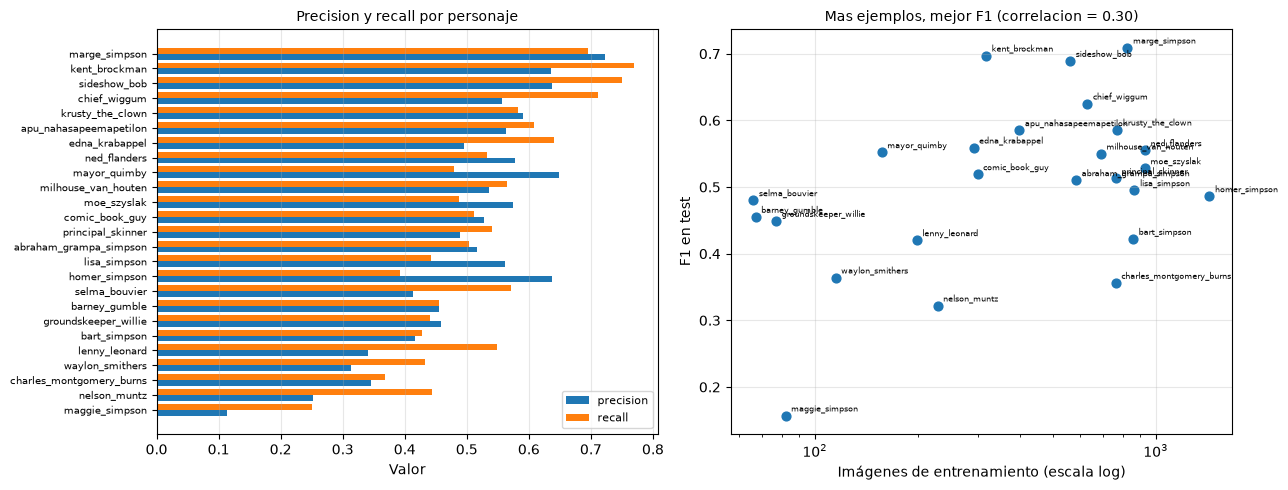

In [99]:
# Relación entre la cantidad de ejemplos de entrenamiento y el F1 alcanzado por cada clase
figura, ejes = plt.subplots(1, 2, figsize=(13, 5))

orden_f1 = metricas_por_clase.sort_values("f1")
posiciones = np.arange(len(orden_f1))
ejes[0].barh(posiciones - 0.2, orden_f1["precision"], height=0.4, label="precision")
ejes[0].barh(posiciones + 0.2, orden_f1["recall"], height=0.4, label="recall")
ejes[0].set_yticks(posiciones)
ejes[0].set_yticklabels(orden_f1["personaje"], fontsize=7)
ejes[0].set_xlabel("Valor")
ejes[0].set_title("Precision y recall por personaje", fontsize=10)
ejes[0].legend(fontsize=8)
ejes[0].grid(alpha=0.3, axis="x")

ejes[1].scatter(metricas_por_clase["n_train"], metricas_por_clase["f1"], s=40)
for _, fila in metricas_por_clase.iterrows():
    ejes[1].annotate(
        fila["personaje"],
        (fila["n_train"], fila["f1"]),
        textcoords="offset points",
        xytext=(4, 3),
        fontsize=6,
    )
ejes[1].set_xscale("log")
ejes[1].set_xlabel("Imágenes de entrenamiento (escala log)")
ejes[1].set_ylabel("F1 en test")
ejes[1].set_title(f"Mas ejemplos, mejor F1 (correlacion = {correlacion:.2f})", fontsize=10)
ejes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Lectura.** El reporte por clase es donde el desbalance se hace visible. Conviene distinguir las dos
métricas: la **precisión** de un personaje responde a "de todo lo que el modelo llamó Homero, ¿cuánto
era realmente Homero?", mientras que el **recall** responde a "de todos los Homeros que había, ¿cuántos
encontró?". Un personaje mayoritario tiende a tener recall alto y precisión más baja —el modelo lo usa
como respuesta por defecto ante la duda—, y los minoritarios muestran el patrón inverso o directamente
métricas cercanas a cero.

El gráfico de la derecha hace explícita esa relación: el F1 por clase crece con el número de ejemplos de
entrenamiento disponibles. El `class_weight` mitiga el sesgo —sin él, varias clases pequeñas quedarían
directamente en cero— pero no puede inventar la variedad visual que esas clases no tienen en el dataset.

### Matriz de confusión

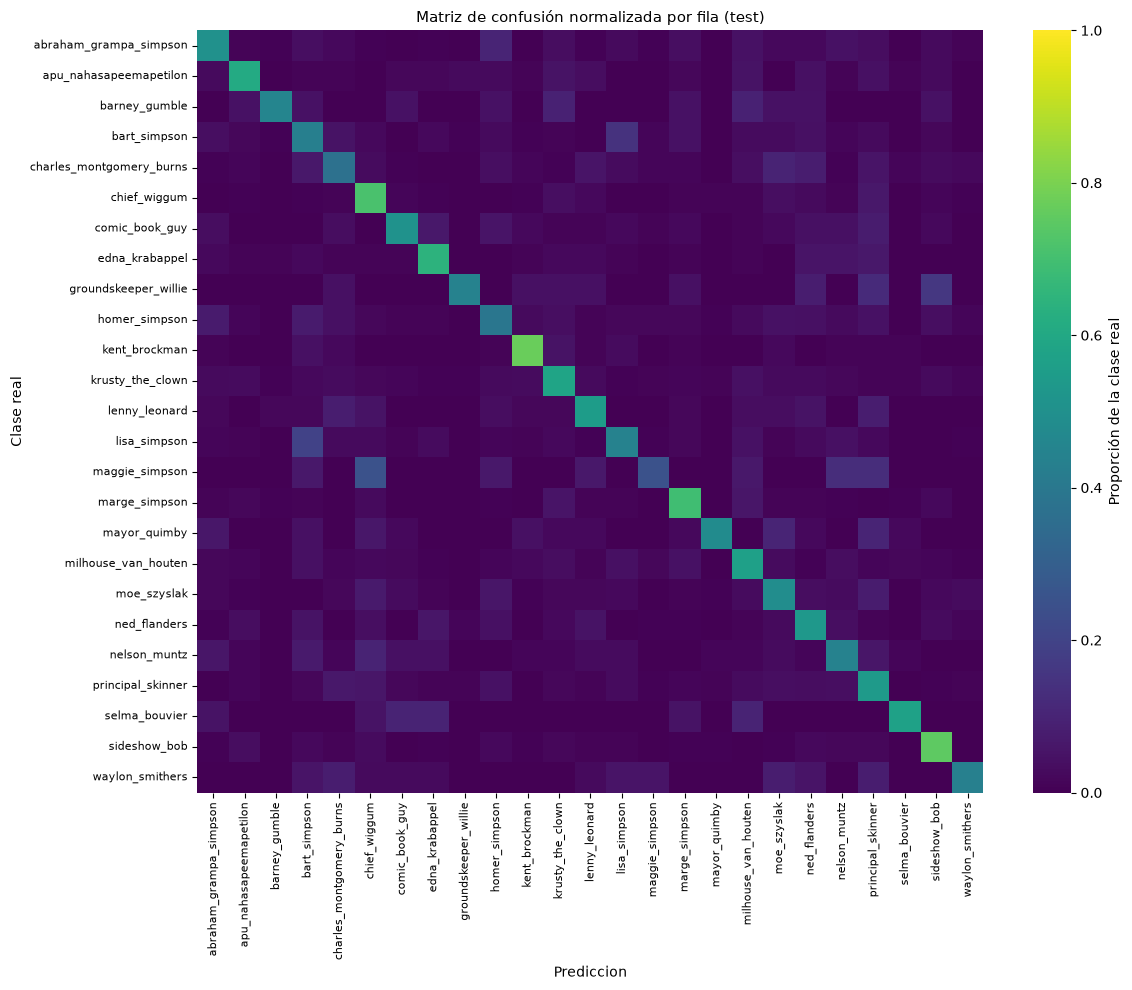

Recall medio (diagonal): 0.526
Clase mejor reconocida : kent_brockman (0.770)
Clase peor reconocida  : maggie_simpson (0.250)


In [100]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

matriz = confusion_matrix(y_test_idx, predicciones_test, labels=range(NUMERO_CLASES))
# Normalizada por fila: cada fila suma 1, de modo que el desbalance no distorsione la lectura
matriz_normalizada = matriz / matriz.sum(axis=1, keepdims=True)

figura, eje = plt.subplots(figsize=(12, 10))
sns.heatmap(
    matriz_normalizada,
    annot=False,
    cmap="viridis",
    vmin=0,
    vmax=1,
    xticklabels=clases,
    yticklabels=clases,
    cbar_kws={"label": "Proporción de la clase real"},
    ax=eje,
)
eje.set_xlabel("Prediccion")
eje.set_ylabel("Clase real")
eje.set_title("Matriz de confusión normalizada por fila (test)", fontsize=11)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

aciertos_diagonal = np.diag(matriz_normalizada)
print(f"Recall medio (diagonal): {aciertos_diagonal.mean():.3f}")
print(f"Clase mejor reconocida : {clases[int(aciertos_diagonal.argmax())]} ({aciertos_diagonal.max():.3f})")
print(f"Clase peor reconocida  : {clases[int(aciertos_diagonal.argmin())]} ({aciertos_diagonal.min():.3f})")

### Interpretación crítica de las métricas

In [101]:
# Comparación de las tres lecturas globales y su distancia
resumen_metricas = pd.DataFrame(
    [
        ("Accuracy (test)", round(float(accuracy_test), 4), "Proporción global de aciertos; domina por las clases grandes"),
        ("F1 ponderado (test)", round(float(f1_ponderado_test), 4), "Promedio de F1 pesado por el tamaño de cada clase"),
        ("F1 macro (test)", round(float(f1_macro_test), 4), "Promedio simple de las 25 clases; cada personaje pesa igual"),
        ("Top-3 accuracy (test)", round(float(top3_test), 4), "La clase correcta está entre las 3 más probables"),
    ],
    columns=["Metrica", "Valor", "Que mide"],
)
display(resumen_metricas)

brecha_metricas = float(accuracy_test) - float(f1_macro_test)

# Clases que el modelo prácticamente no reconoce
clases_debiles = metricas_por_clase[metricas_por_clase["f1"] < 0.30]
clases_fuertes = metricas_por_clase[metricas_por_clase["f1"] >= 0.60]

print(f"Brecha accuracy - F1 macro: {brecha_metricas:.3f}")
print(f"Clases con F1 >= 0.60 : {len(clases_fuertes)} de {NUMERO_CLASES}")
print(f"Clases con F1 <  0.30 : {len(clases_debiles)} de {NUMERO_CLASES}")
if len(clases_debiles):
    print("  " + ", ".join(clases_debiles["personaje"].tolist()))
print(
    f"\nMediana de imagenes de entrenamiento en las clases fuertes: "
    f"{clases_fuertes['n_train'].median():.0f}"
)
if len(clases_debiles):
    print(
        f"Mediana de imagenes de entrenamiento en las clases debiles : "
        f"{clases_debiles['n_train'].median():.0f}"
    )

,Metrica,Valor,Que mide
0,Accuracy (test),0.5331,Proporción global de aciertos; domina por las ...
1,F1 ponderado (test),0.5339,Promedio de F1 pesado por el tamaño de cada clase
2,F1 macro (test),0.5032,Promedio simple de las 25 clases; cada persona...
3,Top-3 accuracy (test),0.7333,La clase correcta está entre las 3 más probables


Brecha accuracy - F1 macro: 0.030
Clases con F1 >= 0.60 : 4 de 25
Clases con F1 <  0.30 : 1 de 25
  maggie_simpson

Mediana de imagenes de entrenamiento en las clases fuertes: 596
Mediana de imagenes de entrenamiento en las clases debiles : 82


**Qué revela la brecha entre accuracy y F1 macro.** Las dos métricas miden lo mismo sobre las mismas
predicciones, pero reparten el peso de forma distinta. La accuracy cuenta aciertos sobre el total, así
que un personaje con 450 imágenes en test influye más de cinco veces que uno con 80. El F1 macro promedia
las 25 clases sin ponderar: cada personaje vale lo mismo, tenga 450 imágenes o 20. Por eso, cuando el
F1 macro queda claramente por debajo de la accuracy, la diferencia no es un detalle técnico sino el
retrato de un modelo que **acierta sobre todo donde hay muchos datos** y falla de forma sistemática en la
cola de clases pequeñas.

La tabla por clase confirma esa lectura: las clases con buen F1 son consistentemente las que más
imágenes de entrenamiento tienen, y las de F1 bajo son las minoritarias. El `class_weight` corrige el
sesgo de la función de pérdida, pero no puede compensar la falta de variedad visual: con pocas decenas de
imágenes de un personaje, la red ve muy pocas poses, encuadres y fondos distintos, y lo que aprende de
esa clase no se transfiere a imágenes nuevas.

La **top-3 accuracy** aporta un matiz importante: es bastante mayor que la accuracy exacta, lo que
significa que en buena parte de los errores la clase correcta sí figura entre las tres candidatas más
probables. El modelo no está prediciendo al azar; extrae señal real, pero no la suficiente para decidir
entre personajes visualmente cercanos.

### Cumplimiento de los KPIs definidos

Los cinco KPIs declarados al inicio se contrastan aqui con las cifras de la prueba
final. El umbral de cada uno se fijo antes de entrenar, de modo que la tabla es una
verificacion y no una justificacion a posteriori del resultado obtenido.

In [ ]:
# Verificacion de los KPIs definidos al inicio del notebook: cada umbral se fijo
# antes de evaluar, y aqui se contrasta con las cifras obtenidas en la prueba final.
import time

# Rendimiento de inferencia: cuantas imagenes por segundo procesa el modelo final.
inicio_inferencia = time.perf_counter()
modelo_final.predict(X_test, batch_size=256, verbose=0)
segundos_inferencia = time.perf_counter() - inicio_inferencia
imagenes_por_segundo = len(X_test) / segundos_inferencia

ventaja_mayoritaria = float(accuracy_test) / baseline_mayoritaria

kpis = [
    ("Cobertura de asistencia", "Top-3 accuracy", 0.70, float(top3_test), "{:.4f}"),
    ("Equidad entre personajes", "F1 macro", 0.45, float(f1_macro_test), "{:.4f}"),
    ("Automatizacion sin revision", "Accuracy", 0.50, float(accuracy_test), "{:.4f}"),
    ("Ventaja sobre criterio trivial", "Accuracy / mayoritaria", 4.0, ventaja_mayoritaria, "x{:.1f}"),
    ("Costo de catalogacion", "Imagenes por segundo", 1000.0, imagenes_por_segundo, "{:,.0f}"),
]

tabla_kpis = pd.DataFrame(
    [
        {
            "KPI": nombre,
            "Metrica": metrica,
            "Umbral": formato.format(umbral),
            "Obtenido": formato.format(obtenido),
            "Cumple": "SI" if obtenido >= umbral else "NO",
        }
        for nombre, metrica, umbral, obtenido, formato in kpis
    ]
)

cumplidos = sum(1 for _, _, umbral, obtenido, _ in kpis if obtenido >= umbral)
print(f"KPIs cumplidos: {cumplidos} de {len(kpis)}\n")
display(tabla_kpis)


## Análisis de resultados y de errores

### El modelo en acción sobre el conjunto opuesto

Las métricas anteriores resumen miles de decisiones en cuatro números. Esta sección hace lo contrario:
toma imágenes concretas del conjunto opuesto —las que el modelo nunca vio— y muestra el proceso completo,
desde el vector de píxeles hasta la distribución de probabilidad de salida.

El primer gráfico recorre una imagen a través de la red **ya entrenada**. Es el mismo diagrama que se
mostró en los fundamentos con pesos aleatorios, pero ahora las activaciones son el resultado del
aprendizaje: se puede comparar directamente el reparto plano de entonces con la distribución concentrada
de ahora.

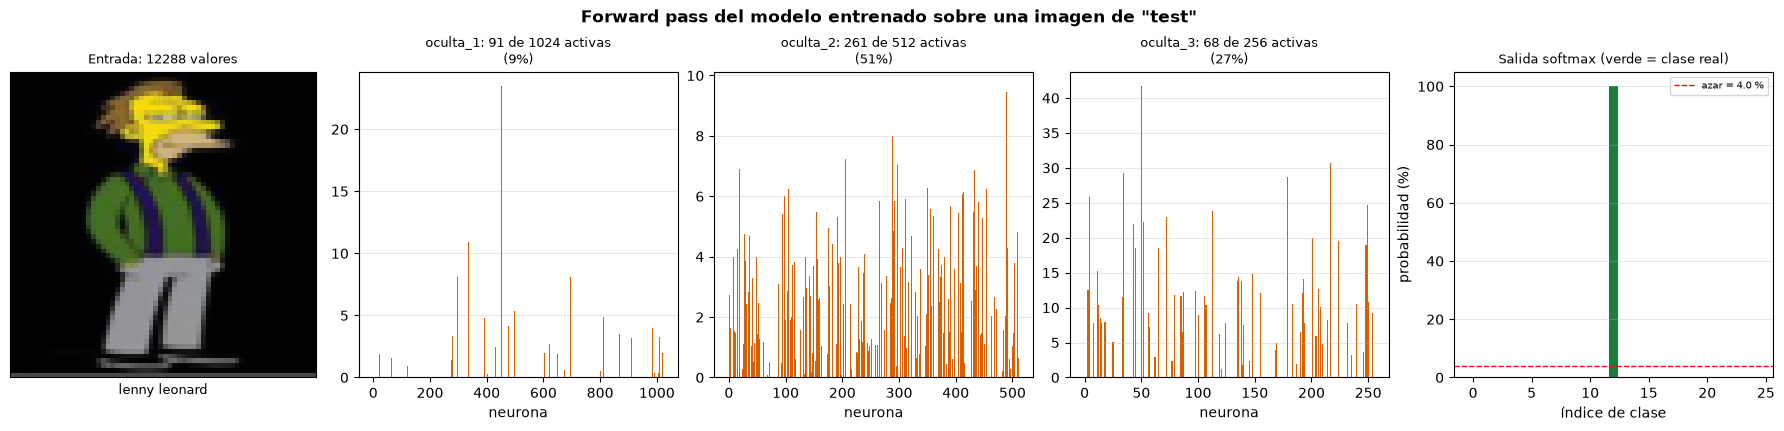

Prediccion: lenny_leonard con 100.0 % de confianza   |   clase real: lenny_leonard
Frente al 4.0 % que asignaria el azar: la red ya no reparte la probabilidad, la concentra.


In [102]:
# Recorrido de una imagen del conjunto de evaluación por la red entrenada:
# de los 49152 valores de entrada a las 25 probabilidades de salida
demo_aciertos = np.flatnonzero(predicciones_test == y_test_idx)
demo_indice = int(demo_aciertos[np.argsort(-confianza_test[demo_aciertos])][0])

# Activaciones capa a capa: cada capa se aplica sobre la salida de la anterior.
# training=False apaga el Dropout y hace que BatchNormalization use sus estadísticas acumuladas.
activaciones = {}
tensor_demo = X_test[demo_indice : demo_indice + 1]
for capa in modelo_final.layers:
    tensor_demo = capa(tensor_demo, training=False)
    activaciones[capa.name] = np.asarray(tensor_demo)[0]

nombres_ocultas = [
    capa.name
    for capa in modelo_final.layers
    if isinstance(capa, layers.Dense) and capa.name != "salida"
]
salida_demo = activaciones["salida"]
real_demo = int(y_test_idx[demo_indice])

figura = plt.figure(
    figsize=(4.2 + 3.2 * len(nombres_ocultas) + 4.0, 4.2), layout="constrained"
)
malla = figura.add_gridspec(1, len(nombres_ocultas) + 2)

# Entrada: la imagen tal como la ve el modelo (64x64, ya normalizada y aplanada)
eje_entrada = figura.add_subplot(malla[0, 0])
eje_entrada.imshow(X_test[demo_indice].reshape(ALTO_OBJETIVO, ANCHO_OBJETIVO, 3))
eje_entrada.set_title(f"Entrada: {DIMENSION_ENTRADA} valores", fontsize=9)
eje_entrada.set_xlabel(clases[real_demo].replace("_", " "), fontsize=9)
eje_entrada.set_xticks([])
eje_entrada.set_yticks([])

# Capas ocultas: activación de cada neurona para esta imagen
for posicion, nombre_capa in enumerate(nombres_ocultas, start=1):
    valores = activaciones[nombre_capa]
    eje = figura.add_subplot(malla[0, posicion])
    eje.bar(
        range(len(valores)),
        valores,
        width=1.0,
        color=["#d95f02" if v > 0 else "#cccccc" for v in valores],
    )
    activas = int((valores > 0).sum())
    eje.set_title(
        f"{nombre_capa}: {activas} de {len(valores)} activas"
        f"\n({activas / len(valores):.0%})",
        fontsize=9,
    )
    eje.set_xlabel("neurona")
    eje.grid(alpha=0.3, axis="y")

# Salida: distribución softmax sobre las 25 clases
eje_salida = figura.add_subplot(malla[0, -1])
eje_salida.bar(
    range(NUMERO_CLASES),
    salida_demo * 100,
    color=["#1b7f3b" if i == real_demo else "#8fb8de" for i in range(NUMERO_CLASES)],
)
eje_salida.axhline(
    100 / NUMERO_CLASES,
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"azar = {100 / NUMERO_CLASES:.1f} %",
)
eje_salida.set_title("Salida softmax (verde = clase real)", fontsize=9)
eje_salida.set_xlabel("índice de clase")
eje_salida.set_ylabel("probabilidad (%)")
eje_salida.legend(fontsize=7)
eje_salida.grid(alpha=0.3, axis="y")

figura.suptitle(
    f'Forward pass del modelo entrenado sobre una imagen de "{conjunto_evaluacion}"',
    fontsize=12,
    fontweight="bold",
)
plt.show()

print(
    f"Prediccion: {clases[int(salida_demo.argmax())]} con {salida_demo.max() * 100:.1f} % de confianza"
    f"   |   clase real: {clases[real_demo]}"
)
print(
    f"Frente al {100 / NUMERO_CLASES:.1f} % que asignaria el azar: la red ya no reparte la"
    " probabilidad, la concentra."
)

**Qué muestra el recorrido.** Dos cosas cambian respecto de la red sin entrenar. En las capas ocultas
solo una fracción de las neuronas se activa para esta imagen —el resto queda en cero por efecto de
ReLU—: la representación es **dispersa**, y qué subconjunto se enciende es precisamente lo que codifica
al personaje. En la salida, la probabilidad deja de repartirse entre las 25 clases y se concentra casi
toda en una sola, muy por encima del 4 % del azar.

Conviene recordar que la imagen de la izquierda es literalmente lo que recibe el modelo: 128 x 128 píxeles
y nada más. Aunque esta resolución conserva más detalle que 64 x 64, el aplanado elimina la vecindad
espacial antes de que la red empiece a trabajar.

#### Predicciones individuales: las cinco clases más probables

En lugar de quedarse con la clase ganadora, aquí se abre la distribución completa. La barra de cada
candidata muestra cuánta probabilidad le asignó el modelo, lo que permite distinguir entre una decisión
tomada con holgura y una en la que dos personajes quedaron casi empatados.

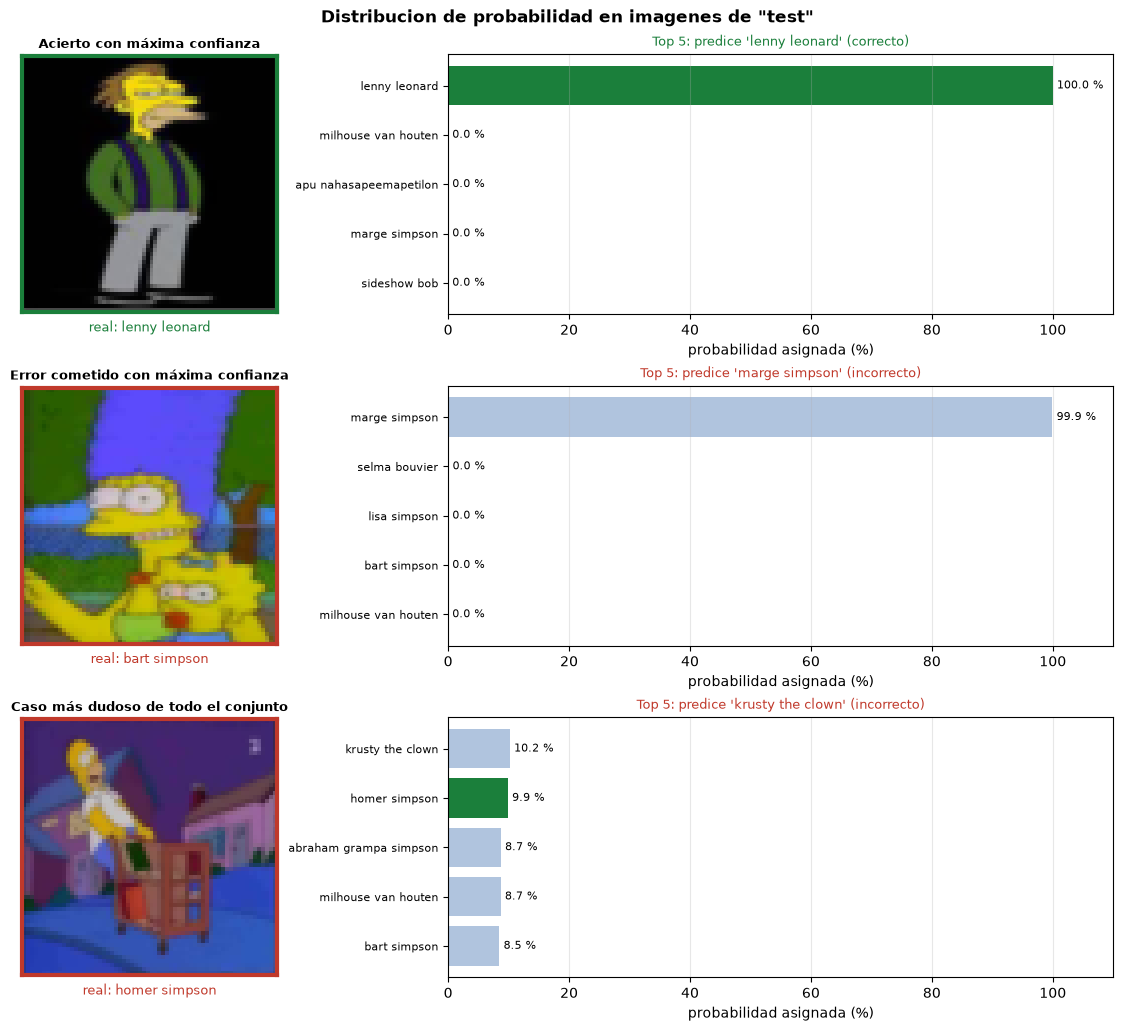

In [103]:
# Tres casos representativos: un acierto seguro, un error seguro y un caso donde el modelo dudó
demo_errores = np.flatnonzero(predicciones_test != y_test_idx)

casos = [
    (int(demo_aciertos[np.argmax(confianza_test[demo_aciertos])]), "Acierto con máxima confianza"),
    (int(demo_errores[np.argmax(confianza_test[demo_errores])]), "Error cometido con máxima confianza"),
    (int(np.argmin(confianza_test)), "Caso más dudoso de todo el conjunto"),
]

TOP_K = 5
figura, ejes = plt.subplots(
    len(casos),
    2,
    figsize=(11, 3.4 * len(casos)),
    layout="constrained",
    gridspec_kw={"width_ratios": [1, 2.6]},
)

for fila, (indice, descripcion) in enumerate(casos):
    real = int(y_test_idx[indice])
    predicho = int(predicciones_test[indice])
    acierto = real == predicho
    color = "#1b7f3b" if acierto else "#c0392b"

    eje_imagen = ejes[fila, 0]
    eje_imagen.imshow(imagenes_test[indice])
    eje_imagen.set_xticks([])
    eje_imagen.set_yticks([])
    for lado in eje_imagen.spines.values():
        lado.set_edgecolor(color)
        lado.set_linewidth(3)
    eje_imagen.set_xlabel(
        f"real: {clases[real].replace('_', ' ')}", fontsize=9, labelpad=6, color=color
    )
    eje_imagen.set_title(descripcion, fontsize=9, fontweight="bold")

    # Las TOP_K clases con mayor probabilidad, dibujadas de mayor a menor
    mejores = np.argsort(-probabilidades_test[indice])[:TOP_K][::-1]
    etiquetas = [clases[i].replace("_", " ") for i in mejores]
    colores = ["#1b7f3b" if i == real else "#b0c4de" for i in mejores]

    eje_barras = ejes[fila, 1]
    barras = eje_barras.barh(etiquetas, probabilidades_test[indice][mejores] * 100, color=colores)
    eje_barras.bar_label(barras, fmt="%.1f %%", fontsize=8, padding=3)
    eje_barras.set_xlim(0, 110)
    eje_barras.set_xlabel("probabilidad asignada (%)")
    eje_barras.tick_params(axis="y", labelsize=8)
    eje_barras.grid(alpha=0.3, axis="x")
    eje_barras.set_title(
        f"Top {TOP_K}: predice '{clases[predicho].replace('_', ' ')}'"
        f" ({'correcto' if acierto else 'incorrecto'})",
        fontsize=9,
        color=color,
    )

figura.suptitle(
    f'Distribucion de probabilidad en imagenes de "{conjunto_evaluacion}"',
    fontsize=12,
    fontweight="bold",
)
plt.show()

#### Muestra aleatoria: el modelo trabajando sin filtros

Los ejemplos anteriores están elegidos a propósito por ser extremos. La rejilla siguiente toma una
muestra **al azar** del conjunto opuesto, sin seleccionar nada: es la imagen más honesta del
comportamiento real del modelo, y la proporción de marcos verdes debería parecerse a la accuracy global.

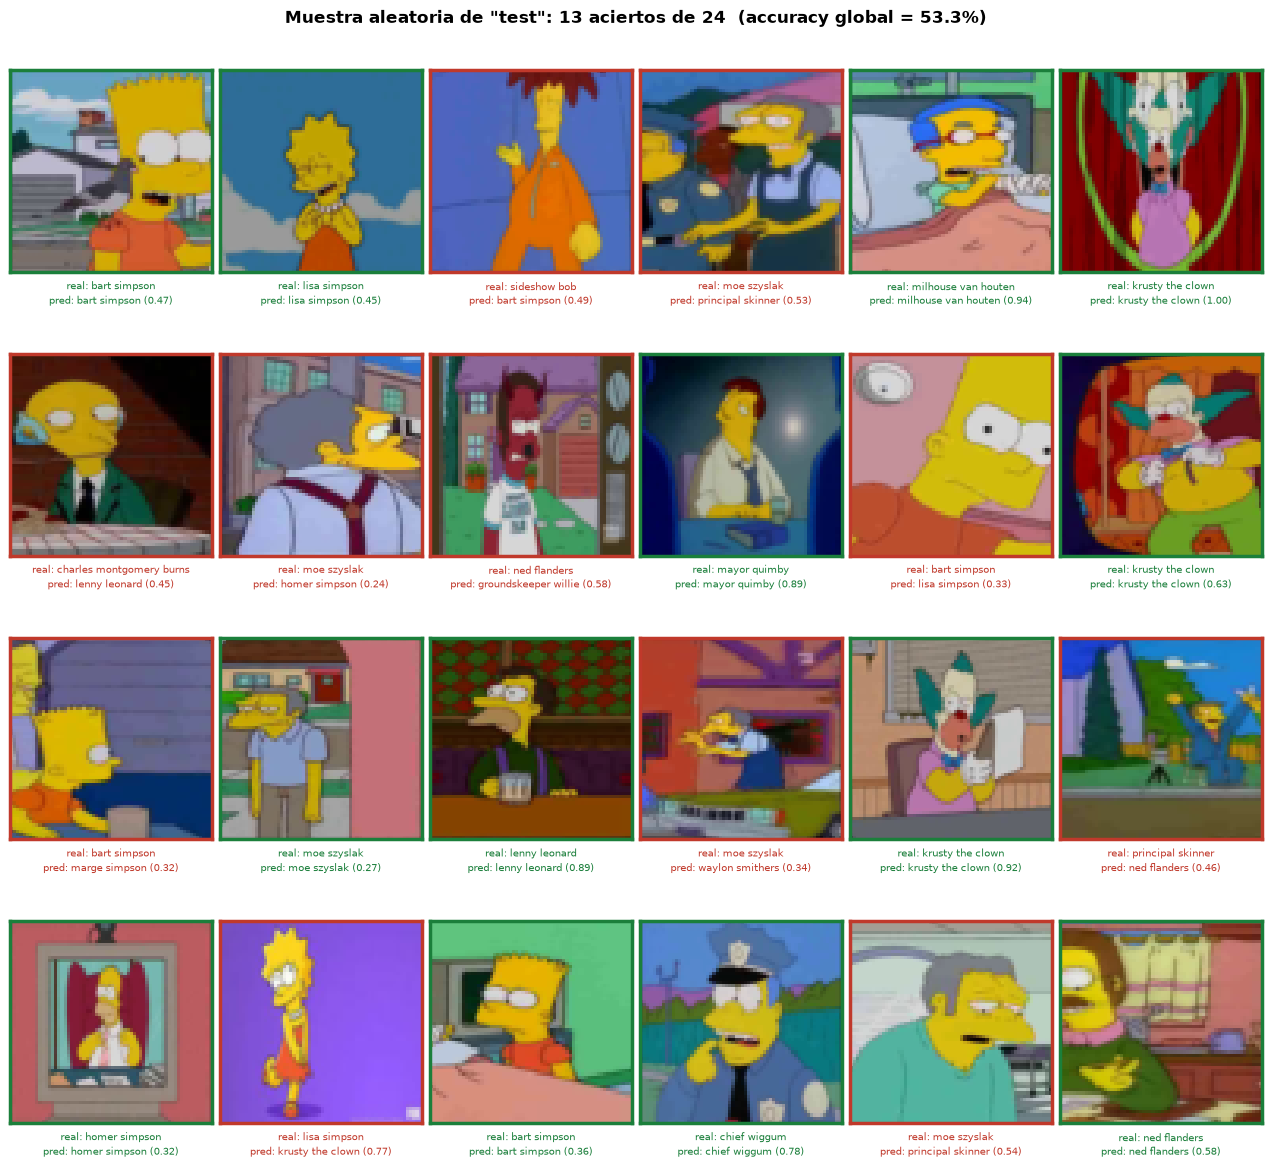

In [104]:
# Muestra aleatoria sin seleccionar: marco verde si acertó, rojo si fallo
FILAS_MOSAICO, COLUMNAS_MOSAICO = 4, 6
generador_muestra = np.random.default_rng(SEMILLA)
muestra_aleatoria = generador_muestra.choice(
    len(y_test_idx), size=FILAS_MOSAICO * COLUMNAS_MOSAICO, replace=False
)

figura, ejes = plt.subplots(
    FILAS_MOSAICO,
    COLUMNAS_MOSAICO,
    figsize=(2.1 * COLUMNAS_MOSAICO, 2.9 * FILAS_MOSAICO),
    layout="constrained",
)

for eje, indice in zip(np.ravel(ejes), muestra_aleatoria):
    real = clases[y_test_idx[indice]].replace("_", " ")
    predicho = clases[predicciones_test[indice]].replace("_", " ")
    acierto = y_test_idx[indice] == predicciones_test[indice]
    color = "#1b7f3b" if acierto else "#c0392b"

    eje.imshow(imagenes_test[indice])
    eje.set_xticks([])
    eje.set_yticks([])
    for lado in eje.spines.values():
        lado.set_edgecolor(color)
        lado.set_linewidth(2.5)
    eje.set_xlabel(
        f"real: {real}\npred: {predicho} ({confianza_test[indice]:.2f})",
        fontsize=7,
        color=color,
        labelpad=5,
        linespacing=1.5,
    )

aciertos_muestra = int(
    (predicciones_test[muestra_aleatoria] == y_test_idx[muestra_aleatoria]).sum()
)
figura.suptitle(
    f'Muestra aleatoria de "{conjunto_evaluacion}": {aciertos_muestra} aciertos'
    f" de {len(muestra_aleatoria)}  (accuracy global = {accuracy_test:.1%})",
    fontsize=12,
    fontweight="bold",
)
plt.show()

#### Rendimiento por personaje, con una imagen de cada uno

La tabla de métricas por clase es precisa pero abstracta. Esta galería le pone cara: un ejemplo real de
cada uno de los 25 personajes, con el marco coloreado según el **recall** que el modelo alcanza en esa
clase —verde si la reconoce casi siempre, rojo si se le escapa casi siempre—. Se ve de un vistazo que
las clases en rojo son las minoritarias.

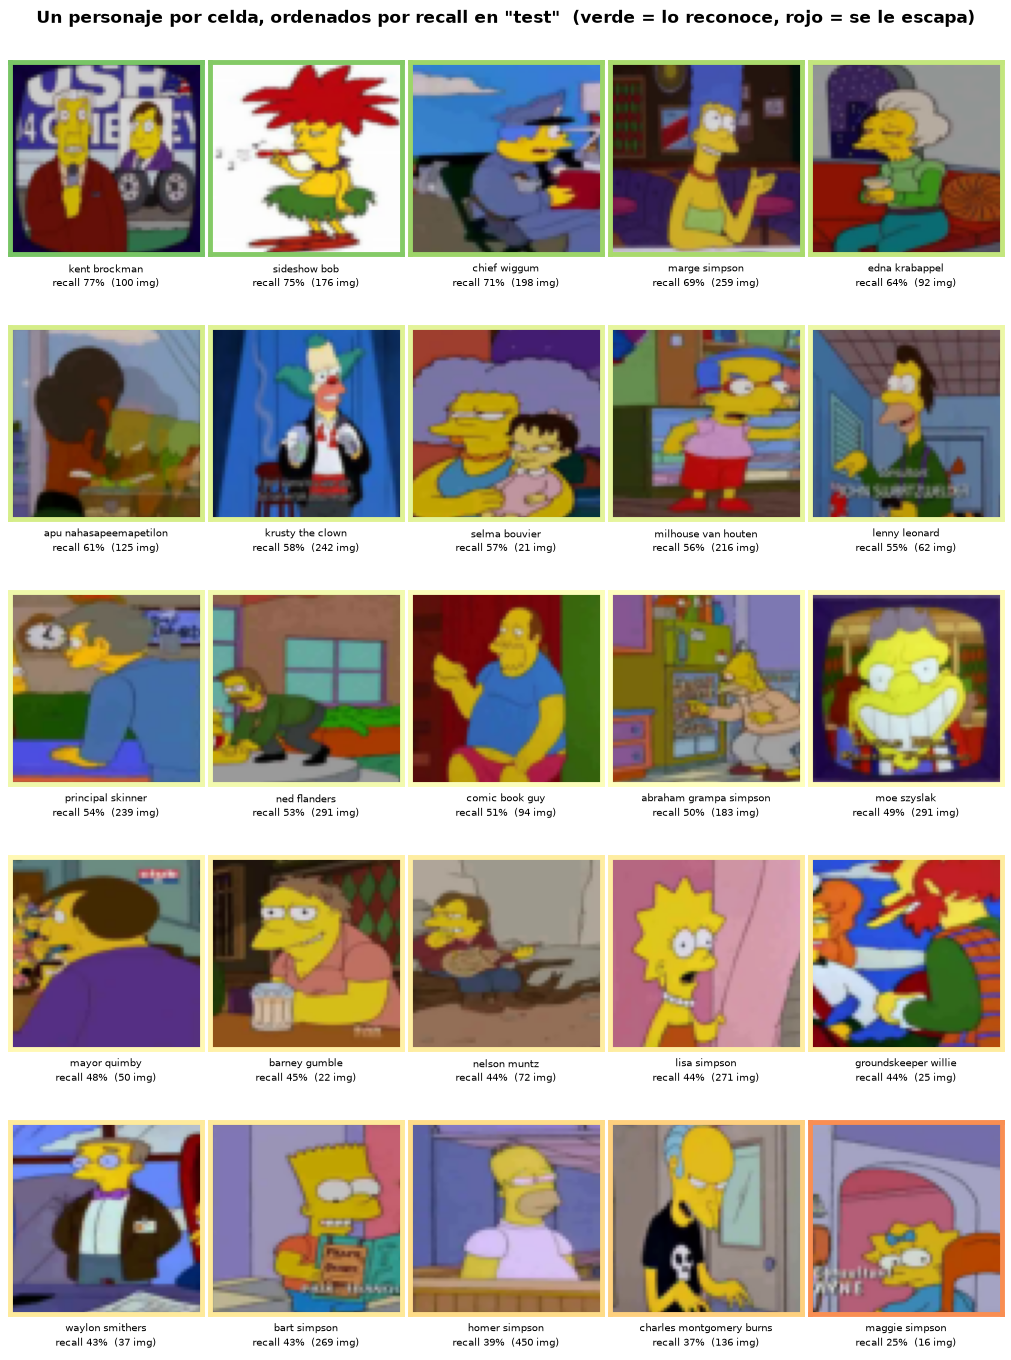

Recall medio sobre las 25 clases: 52.6%
Mejor: kent_brockman (77%)   |   Peor: maggie_simpson (25%)


In [105]:
# Una imagen por personaje, con el marco coloreado según el recall de esa clase
recall_por_clase = np.diag(matriz_normalizada)
mapa_color = plt.get_cmap("RdYlGn")

FILAS_GALERIA = 5
COLUMNAS_GALERIA = int(np.ceil(NUMERO_CLASES / FILAS_GALERIA))

figura, ejes = plt.subplots(
    FILAS_GALERIA,
    COLUMNAS_GALERIA,
    figsize=(2.0 * COLUMNAS_GALERIA, 2.7 * FILAS_GALERIA),
    layout="constrained",
)
ejes = np.ravel(ejes)

# Se recorren las clases de mejor a peor recall, para que la degradación sea visible
orden_clases = np.argsort(-recall_por_clase)

for eje, clase in zip(ejes, orden_clases):
    indices_clase = np.flatnonzero(y_test_idx == clase)
    # Se prefiere una imagen acertada; si el modelo no acierta ninguna, se usa la primera disponible
    correctas = indices_clase[predicciones_test[indices_clase] == clase]
    indice = int(correctas[0]) if len(correctas) else int(indices_clase[0])

    eje.imshow(imagenes_test[indice])
    eje.set_xticks([])
    eje.set_yticks([])
    for lado in eje.spines.values():
        lado.set_edgecolor(mapa_color(recall_por_clase[clase]))
        lado.set_linewidth(3.5)
    eje.set_xlabel(
        f"{clases[clase].replace('_', ' ')}\nrecall {recall_por_clase[clase]:.0%}"
        f"  ({len(indices_clase)} img)",
        fontsize=7,
        labelpad=5,
        linespacing=1.5,
    )

for eje in ejes[NUMERO_CLASES:]:
    eje.axis("off")

figura.suptitle(
    f'Un personaje por celda, ordenados por recall en "{conjunto_evaluacion}"'
    "  (verde = lo reconoce, rojo = se le escapa)",
    fontsize=12,
    fontweight="bold",
)
plt.show()

print(f"Recall medio sobre las {NUMERO_CLASES} clases: {recall_por_clase.mean():.1%}")
print(
    f"Mejor: {clases[int(orden_clases[0])]} ({recall_por_clase[orden_clases[0]]:.0%})"
    f"   |   Peor: {clases[int(orden_clases[-1])]} ({recall_por_clase[orden_clases[-1]]:.0%})"
)

#### Qué píxeles está mirando el modelo

Hasta aquí se ha visto **qué** responde el modelo; este último gráfico muestra **en qué se fija** para
responderlo. Se calcula el gradiente de la probabilidad de la clase predicha respecto de cada píxel de
entrada: donde el gradiente es grande, un cambio pequeño en ese píxel alteraría mucho la decisión. El
mapa resultante —el *mapa de saliencia*— señala las zonas que el modelo realmente está usando.

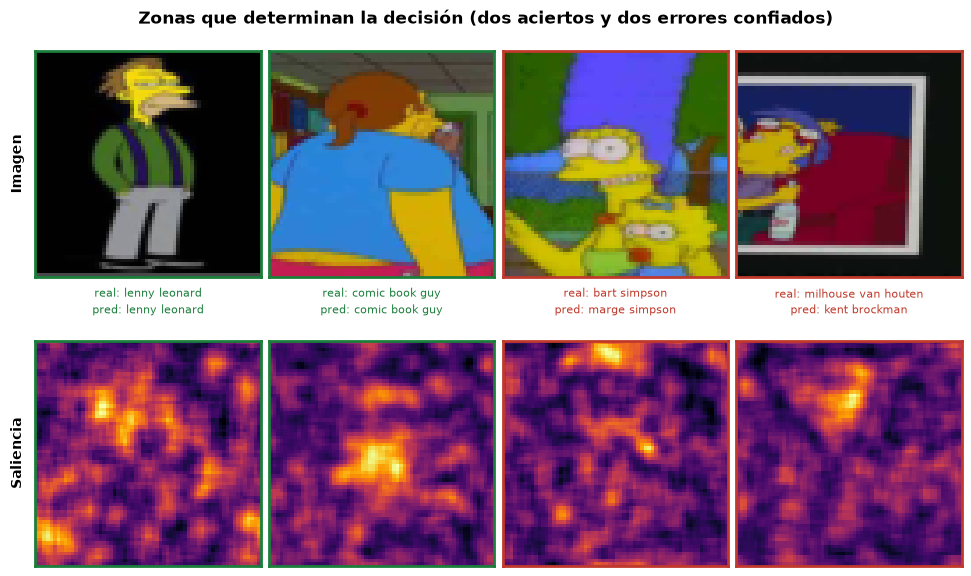

,imagen,acierto,influencia_en_el_10%_top
0,lenny_leonard -> lenny_leonard,True,0.183
1,comic_book_guy -> comic_book_guy,True,0.196
2,bart_simpson -> marge_simpson,False,0.195
3,milhouse_van_houten -> kent_brockman,False,0.194


Reparto uniforme de referencia: 0.100   |   observado: 0.192 de media


In [106]:
# Mapa de saliencia: cuánto cambia la probabilidad de la clase predicha al perturbar cada píxel
indices_saliencia = list(demo_aciertos[np.argsort(-confianza_test[demo_aciertos])][:2]) + list(
    demo_errores[np.argsort(-confianza_test[demo_errores])][:2]
)

entrada_saliencia = tf.convert_to_tensor(X_test[indices_saliencia])
clases_predichas = tf.convert_to_tensor(predicciones_test[indices_saliencia], dtype=tf.int32)

with tf.GradientTape() as cinta:
    cinta.watch(entrada_saliencia)
    salidas = modelo_final(entrada_saliencia, training=False)
    # Probabilidad que el modelo asignó a la clase que efectivamente predijo
    puntajes = tf.gather(salidas, clases_predichas, batch_dims=1)

gradientes = cinta.gradient(puntajes, entrada_saliencia).numpy()
# Valor absoluto y resumen de los tres canales RGB en un único mapa por imagen
saliencia = np.abs(gradientes).reshape(-1, ALTO_OBJETIVO, ANCHO_OBJETIVO, 3).max(axis=-1)


def suavizar(mapas, radio=2):
    """Promedia cada píxel con sus vecinos. El gradiente píxel a píxel es muy ruidoso;
    suavizarlo deja ver si la importancia forma regiones o está repartida por todo el encuadre."""
    acumulado = np.zeros_like(mapas)
    for desplazamiento_y in range(-radio, radio + 1):
        for desplazamiento_x in range(-radio, radio + 1):
            acumulado += np.roll(
                np.roll(mapas, desplazamiento_y, axis=1), desplazamiento_x, axis=2
            )
    return acumulado / (2 * radio + 1) ** 2


saliencia_suave = suavizar(saliencia)

figura, ejes = plt.subplots(
    2,
    len(indices_saliencia),
    figsize=(2.4 * len(indices_saliencia), 5.8),
    layout="constrained",
)

for columna, indice in enumerate(indices_saliencia):
    real = clases[y_test_idx[indice]].replace("_", " ")
    predicho = clases[predicciones_test[indice]].replace("_", " ")
    acierto = y_test_idx[indice] == predicciones_test[indice]
    color = "#1b7f3b" if acierto else "#c0392b"

    ejes[0, columna].imshow(imagenes_test[indice])
    ejes[1, columna].imshow(saliencia_suave[columna], cmap="inferno")

    ejes[0, columna].set_xlabel(
        f"real: {real}\npred: {predicho}",
        fontsize=8,
        color=color,
        labelpad=6,
        linespacing=1.5,
    )

    for eje in (ejes[0, columna], ejes[1, columna]):
        eje.set_xticks([])
        eje.set_yticks([])
        for lado in eje.spines.values():
            lado.set_edgecolor(color)
            lado.set_linewidth(2)

ejes[0, 0].set_ylabel("Imagen", fontsize=10, fontweight="bold", labelpad=8)
ejes[1, 0].set_ylabel("Saliencia", fontsize=10, fontweight="bold", labelpad=8)
figura.suptitle(
    "Zonas que determinan la decisión (dos aciertos y dos errores confiados)",
    fontsize=12,
    fontweight="bold",
)
plt.show()

# Que parte de la influencia total se concentra en el 10 % de píxeles más determinantes.
# Si el modelo mirara una región concreta, ese 10 % acumularía la mayor parte de la influencia;
# si la reparte por todo el encuadre, el valor se acerca al 10 % de un reparto uniforme.
plano = saliencia.reshape(len(indices_saliencia), -1)
umbral = np.quantile(plano, 0.90, axis=1, keepdims=True)
concentracion = (plano * (plano >= umbral)).sum(axis=1) / plano.sum(axis=1)

tabla_saliencia = pd.DataFrame(
    {
        "imagen": [f"{clases[y_test_idx[i]]} -> {clases[predicciones_test[i]]}" for i in indices_saliencia],
        "acierto": [bool(y_test_idx[i] == predicciones_test[i]) for i in indices_saliencia],
        "influencia_en_el_10%_top": [round(float(v), 3) for v in concentracion],
    }
)
display(tabla_saliencia)

print(f"Reparto uniforme de referencia: 0.100   |   observado: {concentracion.mean():.3f} de media")

**Lectura de los mapas de saliencia.** El resultado es revelador justamente por lo que **no** muestra:
la importancia no se concentra sobre el personaje, sino que queda repartida como un moteado por todo el
encuadre, fondo incluido. El indicador numérico lo confirma: el 10 % de píxeles más influyentes acumula
alrededor de un 20 % de la influencia total, muy lejos del reparto concentrado que se vería si el modelo
estuviera localizando al personaje, y bastante cerca del 10 % que daría un reparto perfectamente
uniforme.

Eso es exactamente la limitación descrita en "Limitaciones estructurales del MLP", ahora visible en una
imagen: todos los píxeles entran al modelo con el mismo estatus y la red no tiene ningún mecanismo para
separar el objeto del escenario. No decide "dónde mirar" porque no tiene noción de *dónde*; lo que
aprende son combinaciones de valores de color en posiciones fijas del encuadre, y por eso el mapa se
parece más a una huella dispersa que a una región.

De ahí se sigue la consecuencia práctica que atraviesa todo el trabajo: como cada peso está atado a una
posición concreta, el mismo personaje desplazado o recortado de otra forma produce un patrón de
influencia completamente distinto. Una red convolucional, que desliza los mismos filtros por toda la
imagen, es precisamente la respuesta a este problema.

### Ejemplos correctamente clasificados

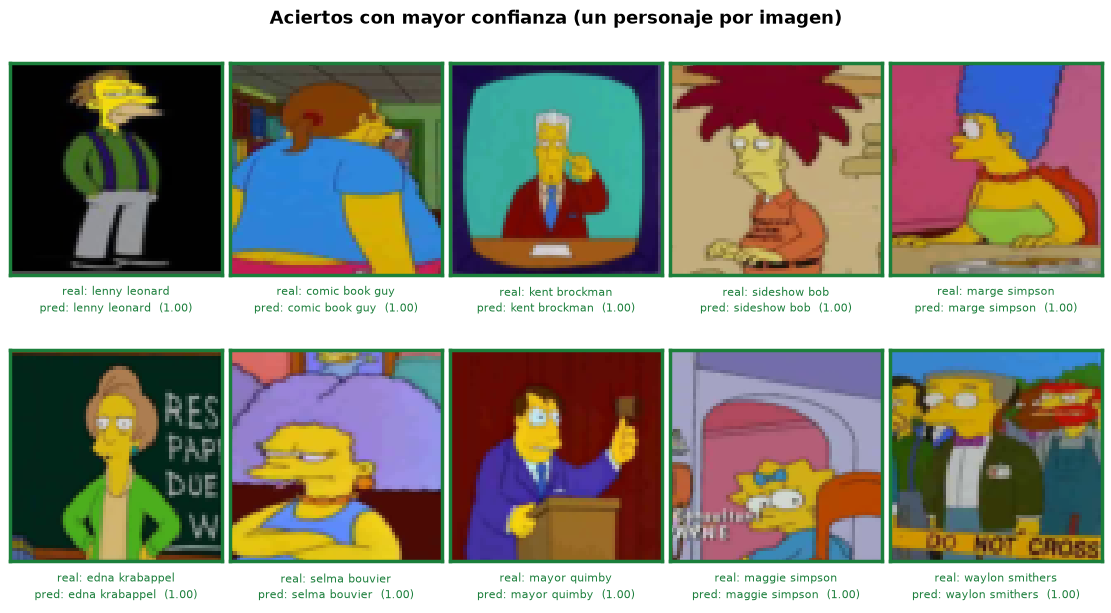

Aciertos totales: 2099 de 3937 (53.3%)
Confianza media en los aciertos: 0.697


In [107]:
def mostrar_ejemplos(indices, titulo, filas=2, columnas=5):
    """Dibuja una rejilla de imágenes de test con su etiqueta real, la predicha y la confianza."""
    indices = list(indices)
    figura, ejes = plt.subplots(
        filas,
        columnas,
        figsize=(2.2 * columnas, 3.0 * filas),
        layout="constrained",
    )
    ejes = np.ravel(ejes)

    for eje, indice in zip(ejes, indices):
        real = clases[y_test_idx[indice]].replace("_", " ")
        predicho = clases[predicciones_test[indice]].replace("_", " ")
        acierto = real == predicho
        color = "#1b7f3b" if acierto else "#c0392b"

        eje.imshow(imagenes_test[indice])
        eje.set_xticks([])
        eje.set_yticks([])
        # Marco de color: verde si acertó, rojo si fallo
        for lado in eje.spines.values():
            lado.set_edgecolor(color)
            lado.set_linewidth(2.5)

        # Las etiquetas van debajo de la imagen para que no invadan la fila superior
        eje.set_xlabel(
            f"real: {real}\npred: {predicho}  ({confianza_test[indice]:.2f})",
            fontsize=8,
            color=color,
            labelpad=6,
            linespacing=1.5,
        )

    for eje in ejes[len(indices):]:
        eje.axis("off")

    figura.suptitle(titulo, fontsize=13, fontweight="bold")
    plt.show()


aciertos = np.flatnonzero(predicciones_test == y_test_idx)
# Aciertos con mayor confianza, sin repetir personaje, para ver variedad de clases
aciertos_ordenados = aciertos[np.argsort(-confianza_test[aciertos])]
vistos = set()
seleccion_aciertos = []
for indice in aciertos_ordenados:
    personaje = y_test_idx[indice]
    if personaje not in vistos:
        vistos.add(personaje)
        seleccion_aciertos.append(indice)
    if len(seleccion_aciertos) == 10:
        break

mostrar_ejemplos(seleccion_aciertos, "Aciertos con mayor confianza (un personaje por imagen)")

print(f"Aciertos totales: {len(aciertos)} de {len(y_test_idx)} ({len(aciertos) / len(y_test_idx):.1%})")
print(f"Confianza media en los aciertos: {confianza_test[aciertos].mean():.3f}")

**Qué está aprovechando el modelo.** Los aciertos con más confianza corresponden a imágenes donde el
personaje ocupa buena parte del encuadre, con su paleta de color característica bien visible y un fondo
poco cargado. Eso es coherente con lo que un MLP puede llegar a aprender sobre píxeles aplanados: una
combinación de **color dominante y su distribución aproximada en la imagen**. El azul del pelo de Marge,
el rojo del vestido de Lisa o el amarillo saturado de una cara en primer plano son señales que sobreviven
al redimensionado a 128 x 128 y al aplanado, porque no dependen de reconocer una forma sino de que ciertos
píxeles tengan ciertos valores.

Lo que el modelo **no** está usando es la forma: no reconoce el peinado de Marge como estructura, sino la
mancha azul en la zona superior del encuadre. Esa es justamente la razón por la que funciona bien en
imágenes canónicas y se rompe en cuanto cambia el encuadre.

### Ejemplos mal clasificados

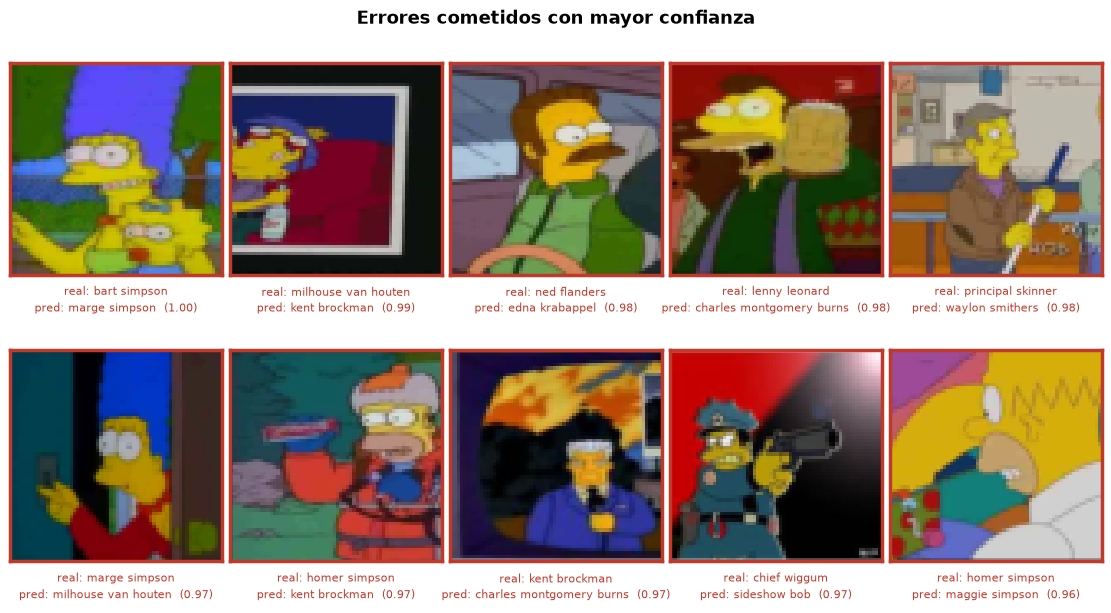

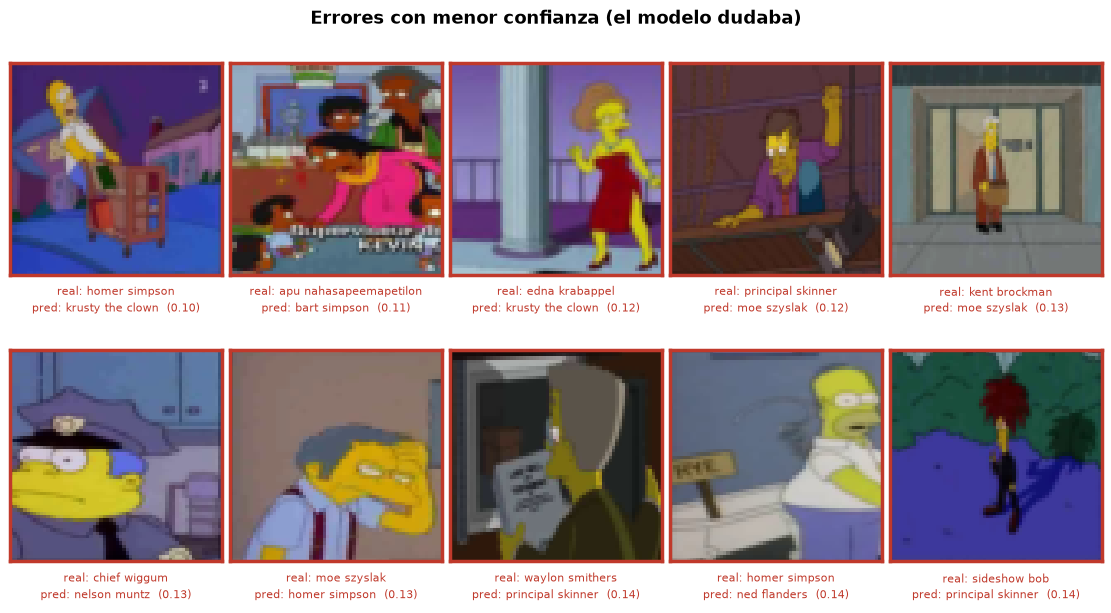

,Indicador,Valor,Detalle
0,Errores totales,1838.000,46.7% del test
1,Confianza media en aciertos,0.697,
2,Confianza media en errores,0.422,
3,Errores con confianza > 0.90,38.000,2.1% de los errores


In [108]:
errores = np.flatnonzero(predicciones_test != y_test_idx)

# Los errores más graves: equivocaciones cometidas con la mayor confianza
errores_confiados = errores[np.argsort(-confianza_test[errores])][:10]
mostrar_ejemplos(errores_confiados, "Errores cometidos con mayor confianza")

# Errores con baja confianza: el modelo tampoco sabía
errores_dudosos = errores[np.argsort(confianza_test[errores])][:10]
mostrar_ejemplos(errores_dudosos, "Errores con menor confianza (el modelo dudaba)")

resumen_errores = pd.DataFrame(
    [
        ("Errores totales", len(errores), f"{len(errores) / len(y_test_idx):.1%} del test"),
        ("Confianza media en aciertos", round(float(confianza_test[aciertos].mean()), 3), ""),
        ("Confianza media en errores", round(float(confianza_test[errores].mean()), 3), ""),
        (
            "Errores con confianza > 0.90",
            int((confianza_test[errores] > 0.90).sum()),
            f"{(confianza_test[errores] > 0.90).mean():.1%} de los errores",
        ),
    ],
    columns=["Indicador", "Valor", "Detalle"],
)
display(resumen_errores)

**Dos tipos de error muy distintos.** La confianza media es mayor en los aciertos que en los errores, lo
que indica que la probabilidad de salida del softmax tiene cierto valor como señal de fiabilidad: cuando
el modelo duda, suele tener motivos.

Aun así, existe un grupo de **errores cometidos con alta confianza**, y son los preocupantes: el modelo
no solo se equivoca, sino que está seguro. Al mirarlos se repite un patrón: personajes que comparten
paleta de color con el que fue predicho, imágenes donde el personaje aparece pequeño dentro de una
escena, o fondos que ocupan la mayor parte del encuadre. Como el MLP no distingue entre "píxeles del
personaje" y "píxeles del fondo" —todos entran al mismo vector con el mismo estatus—, un fondo
característico puede pesar tanto como el propio personaje.

Los errores con baja confianza, en cambio, corresponden en su mayoría a imágenes genuinamente difíciles:
planos generales, personajes de espaldas, escenas oscuras o con varios personajes a la vez, donde
incluso una etiqueta única es discutible.

### Confusiones más frecuentes y posibles causas

,real,predicho,casos,% de la clase real,n_train_real,n_train_predicho
0,lisa_simpson,bart_simpson,53,19.6,866,858
1,bart_simpson,lisa_simpson,38,14.1,858,866
2,homer_simpson,bart_simpson,33,7.3,1437,858
3,homer_simpson,abraham_grampa_simpson,32,7.1,1437,584
4,moe_szyslak,principal_skinner,22,7.6,929,764
5,homer_simpson,principal_skinner,21,4.7,1437,764
6,homer_simpson,moe_szyslak,21,4.7,1437,929
7,moe_szyslak,chief_wiggum,20,6.9,929,630
8,homer_simpson,ned_flanders,19,4.2,1437,930
9,homer_simpson,charles_montgomery_burns,19,4.2,1437,763


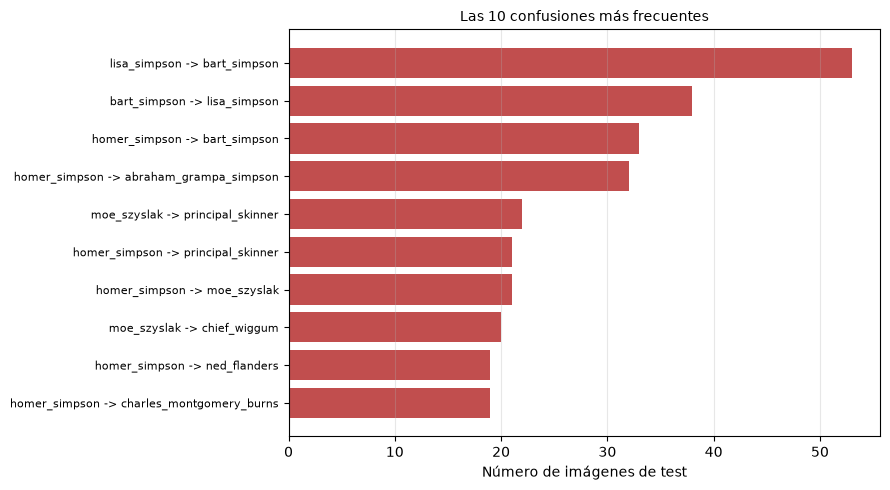

Clases que más absorben errores de otras (el modelo las usa como respuesta por defecto):
  bart_simpson: 86 imagenes de otras clases predichas como esta
  principal_skinner: 43 imagenes de otras clases predichas como esta
  lisa_simpson: 38 imagenes de otras clases predichas como esta
  homer_simpson: 34 imagenes de otras clases predichas como esta
  abraham_grampa_simpson: 32 imagenes de otras clases predichas como esta


In [109]:
# Pares (clase real, clase predicha) más frecuentes, excluyendo la diagonal
pares = []
for real in range(NUMERO_CLASES):
    for predicho in range(NUMERO_CLASES):
        if real != predicho and matriz[real, predicho] > 0:
            pares.append(
                {
                    "real": clases[real],
                    "predicho": clases[predicho],
                    "casos": int(matriz[real, predicho]),
                    "% de la clase real": round(float(matriz_normalizada[real, predicho]) * 100, 1),
                    "n_train_real": int(conteos_train[real]),
                    "n_train_predicho": int(conteos_train[predicho]),
                }
            )

confusiones = pd.DataFrame(pares).sort_values("casos", ascending=False, ignore_index=True).head(15)
display(confusiones)

figura, eje = plt.subplots(figsize=(9, 5))
etiquetas_pares = confusiones.head(10).apply(
    lambda fila: f"{fila['real']} -> {fila['predicho']}", axis=1
)
eje.barh(etiquetas_pares[::-1], confusiones.head(10)["casos"][::-1], color="firebrick", alpha=0.8)
eje.set_xlabel("Número de imágenes de test")
eje.set_title("Las 10 confusiones más frecuentes", fontsize=10)
eje.tick_params(axis="y", labelsize=8)
eje.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

destino_frecuente = confusiones.groupby("predicho")["casos"].sum().sort_values(ascending=False)
print("Clases que más absorben errores de otras (el modelo las usa como respuesta por defecto):")
for personaje, casos in destino_frecuente.head(5).items():
    print(f"  {personaje}: {casos} imagenes de otras clases predichas como esta")

**Causas detrás de las confusiones.** Los pares que encabezan la tabla no son aleatorios; responden a
causas identificables:

- **Similitud visual y de paleta.** Los personajes de la familia comparten el mismo tono de piel amarillo
  y, en varios casos, colores de ropa parecidos. Aplanada desde 128 x 128, la diferencia entre dos
  personajes de silueta similar y colores cercanos casi desaparece.
- **Personajes secundarios contra la familia principal.** Los errores tienden a desembocar en las clases
  mayoritarias: aunque `class_weight` compense la pérdida, esas clases siguen teniendo mucha más
  variedad de ejemplos y actúan como "respuesta por defecto".
- **Fondos compartidos.** Muchas escenas transcurren en los mismos escenarios (el salón de los Simpson,
  la escuela, la central nuclear). El fondo aporta una fracción enorme de los 49 152 valores de entrada,
  y el modelo no tiene forma de saber que esos píxeles son irrelevantes: puede terminar reconociendo el
  escenario en lugar del personaje.
- **Escenas con varios personajes.** El dataset asigna una sola etiqueta por imagen, pero en el encuadre
  puede haber dos o tres personajes. Si el modelo predice a uno de los secundarios, se contabiliza como
  error aunque la respuesta sea razonable.
- **Encuadre y escala.** Un MLP no tiene invarianza a la traslación: el mismo personaje centrado o
  desplazado hacia una esquina produce vectores de entrada completamente distintos, con píxeles que caen
  en posiciones —es decir, en neuronas de entrada— diferentes.
- **Escasez en clases minoritarias.** Con pocas decenas de imágenes, la red no llega a ver suficientes
  variantes del personaje y su frontera de decisión queda mal definida.

### Fortalezas y debilidades del modelo

In [110]:
sintesis = pd.DataFrame(
    [
        (
            "Fortaleza",
            "Supera con holgura los baselines",
            f"accuracy {accuracy_test:.3f} frente a 0.040 (azar) y {baseline_mayoritaria:.3f} (clase mayoritaria)",
        ),
        (
            "Fortaleza",
            "Buena señal en el top-3",
            f"top-3 accuracy {top3_test:.3f}: la clase correcta suele estar entre las candidatas",
        ),
        (
            "Fortaleza",
            "Reconoce con solidez a los personajes principales",
            f"{len(clases_fuertes)} clases con F1 >= 0.60",
        ),
        (
            "Fortaleza",
            "La confianza es informativa",
            f"confianza media {confianza_test[aciertos].mean():.2f} en aciertos y "
            f"{confianza_test[errores].mean():.2f} en errores",
        ),
        (
            "Debilidad",
            "Desempeño muy desigual entre clases",
            f"brecha accuracy - F1 macro = {brecha_metricas:.3f}; {len(clases_debiles)} clases con F1 < 0.30",
        ),
        (
            "Debilidad",
            "Depende del volumen de datos por clase",
            f"correlacion entre n_train y F1 por clase = {correlacion:.2f}",
        ),
        (
            "Debilidad",
            "Sin invarianza a traslación ni a escala",
            "el mismo personaje en otra posición del encuadre es otro vector de entrada",
        ),
        (
            "Debilidad",
            "Sensible al fondo",
            "los píxeles de fondo entran al modelo con el mismo peso que los del personaje",
        ),
        (
            "Debilidad",
            "Costo en parámetros",
            f"{modelo_final.count_params():,} parametros para {len(X_train):,} imagenes de entrenamiento",
        ),
    ],
    columns=["Tipo", "Aspecto", "Evidencia"],
)

display(sintesis)

,Tipo,Aspecto,Evidencia
0,Fortaleza,Supera con holgura los baselines,accuracy 0.533 frente a 0.040 (azar) y 0.114 (...
1,Fortaleza,Buena señal en el top-3,top-3 accuracy 0.733: la clase correcta suele ...
2,Fortaleza,Reconoce con solidez a los personajes principales,4 clases con F1 >= 0.60
3,Fortaleza,La confianza es informativa,confianza media 0.70 en aciertos y 0.42 en err...
4,Debilidad,Desempeño muy desigual entre clases,brecha accuracy - F1 macro = 0.030; 1 clases c...
5,Debilidad,Depende del volumen de datos por clase,correlacion entre n_train y F1 por clase = 0.30
6,Debilidad,Sin invarianza a traslación ni a escala,el mismo personaje en otra posición del encuad...
7,Debilidad,Sensible al fondo,los píxeles de fondo entran al modelo con el m...
8,Debilidad,Costo en parámetros,"13,253,657 parametros para 12,909 imagenes de ..."


**Síntesis.** El MLP demuestra que el problema tiene señal aprendible: multiplica varias veces los
baselines y reconoce con solidez a los personajes con más representación. Pero su desempeño es
profundamente desigual, y la causa no es un ajuste de hiperparámetros mal elegido —la experimentación
muestra que ni más capas ni más neuronas cambian el panorama— sino la representación de la entrada. Un
vector de píxeles sin estructura espacial obliga a la red a memorizar configuraciones concretas de color
en posiciones concretas, en lugar de aprender los rasgos que hacen reconocible a un personaje.

## Limitaciones del MLP en imágenes y propuestas de mejora

### Limitaciones estructurales del MLP

Las limitaciones que siguen no son defectos de esta implementación en particular, sino consecuencias de
usar una red totalmente conectada sobre imágenes. Ningún ajuste de hiperparámetros las resuelve.

**1. Pérdida de la información espacial.** El aplanado convierte la imagen en una lista de 49 152
números en la que se olvida qué píxel estaba junto a cuál. Para la red, dos píxeles vecinos y dos píxeles
en esquinas opuestas son igual de "cercanos": ninguno. Si se permutaran todas las columnas de `X` con una
permutación fija, el modelo aprendería exactamente igual de bien —algo que sería impensable para un ojo
humano y que revela cuánta estructura se está descartando.

**2. Ausencia de invarianza a la traslación y a la escala.** Cada peso de la primera capa está atado a una
posición concreta del encuadre. Si Homero aparece centrado, se activan unas neuronas; desplazado unos
píxeles a la derecha, otras completamente distintas. El modelo tiene que aprender por separado "Homero
arriba a la izquierda", "Homero en el centro" y "Homero de lejos", como si fueran conceptos sin relación.
Lo mismo ocurre con el tamaño: un primer plano y un plano general del mismo personaje no comparten
representación.

**3. Explosión del número de parámetros.** El número de pesos de la primera capa es
`alto x ancho x 3 x neuronas`, es decir, crece de forma cuadrática con el lado de la imagen. En la
configuración ejecutada, 128 x 128 requiere aproximadamente 25,2 millones de pesos solo en la primera
capa de 512 neuronas. Esta razón parámetros/ejemplos eleva el costo y el riesgo de sobreajuste.

**4. Imposibilidad de reutilizar patrones locales.** Un filtro convolucional aprende una vez a detectar
un borde, una esquina o una mancha de color y lo aplica en **toda** la imagen, compartiendo los mismos
pesos. El MLP no tiene ese mecanismo: si un patrón útil aparece en dos posiciones distintas, debe
aprenderlo dos veces, con dos conjuntos de pesos independientes y usando ejemplos distintos para cada uno.
Es un uso enormemente ineficiente tanto de los parámetros como de los datos.

**5. Sensibilidad al fondo y al encuadre.** Todos los píxeles entran al modelo con el mismo estatus. En
una escena donde el personaje ocupa un tercio del encuadre, dos tercios de la entrada son ruido desde el
punto de vista de la tarea —y pueden contener regularidades engañosas: si cierto personaje aparece a
menudo en cierto escenario, el modelo aprenderá el escenario, y fallará en cuanto ese personaje aparezca
en otro lugar.

### Propuestas de mejora para futuras iteraciones

| Propuesta | En qué consiste | Qué limitación ataca |
|---|---|---|
| **Redes convolucionales (CNN)** | Sustituir las primeras capas densas por capas convolucionales y de *pooling*, que operan sobre vecindades de píxeles y comparten los pesos de cada filtro en toda la imagen | Es la mejora principal: recupera la estructura espacial (1), da invarianza aproximada a la traslación (2), reduce drásticamente los parámetros (3) y permite reutilizar patrones locales (4) |
| **Aumento de datos** | Generar variantes de cada imagen en tiempo de entrenamiento: giros horizontales, recortes, pequeñas rotaciones, cambios de brillo y contraste | Multiplica la variedad efectiva del conjunto, ataca directamente el sobreajuste y beneficia sobre todo a las clases minoritarias, que son las que menos variantes tienen |
| **Transfer learning** | Usar una red preentrenada en un corpus grande (MobileNet, ResNet, EfficientNet) como extractor de características y entrenar solo la cabeza clasificadora | Aporta representaciones visuales ya aprendidas sobre millones de imágenes; suele ser la vía más rápida a un salto grande de desempeño con pocos datos propios |
| **Mejor tratamiento del desbalance** | Combinar `class_weight` con sobremuestreo *con* aumento (no por duplicado exacto), o usar *focal loss*, que concentra la pérdida en los ejemplos difíciles | Reduce la brecha entre accuracy y F1 macro, que es la debilidad más marcada del modelo actual |
| **Recorte previo del personaje** | Aplicar un detector que localice al personaje y recortar esa región antes de clasificar | Elimina el fondo irrelevante (5) y normaliza la escala y el encuadre, que hoy son una fuente importante de error |
| **Mayor resolución de entrada** | Subir a 96 x 96 o 128 x 128, viable solo una vez que las capas convolucionales sustituyan a las densas | Recupera detalle fino (rasgos faciales, accesorios) que a 64 x 64 se pierde y que es justo lo que distingue a personajes parecidos |
| **Validación cruzada** | Repetir el entrenamiento con varias particiones y varias semillas, reportando media y desviación | Da una estimación más robusta que una única partición 80/20 y permite saber si las diferencias entre configuraciones son reales o ruido |


![alt text](../images/imageCPU.png)

## Conclusiones

In [111]:
# Cifras finales del trabajo, tomadas de las secciones anteriores
conclusiones = pd.DataFrame(
    [
        ("Clases", NUMERO_CLASES),
        ("Imágenes de entrenamiento", len(X_train)),
        ("Imágenes de validación", len(X_val)),
        ("Imágenes de test", len(X_test)),
        ("Resolución de entrada", f"{ALTO_OBJETIVO}x{ANCHO_OBJETIVO}x3 = {DIMENSION_ENTRADA}"),
        ("Configuración final", nombre_final),
        ("Parámetros del modelo final", f"{modelo_final.count_params():,}"),
        ("Accuracy en test", round(float(accuracy_test), 4)),
        ("Top-3 accuracy en test", round(float(top3_test), 4)),
        ("F1 macro en test", round(float(f1_macro_test), 4)),
        ("F1 ponderado en test", round(float(f1_ponderado_test), 4)),
        ("Baseline azar", round(baseline_azar, 4)),
        ("Baseline clase mayoritaria", round(float(baseline_mayoritaria), 4)),
    ],
    columns=["Concepto", "Valor"],
)

display(conclusiones)

,Concepto,Valor
0,Clases,25
1,Imágenes de entrenamiento,12909
2,Imágenes de validación,3228
3,Imágenes de test,3937
4,Resolución de entrada,64x64x3 = 12288
5,Configuración final,"E2 - 3 capas (1024,512,256)"
6,Parámetros del modelo final,"13,253,657"
7,Accuracy en test,0.5331
8,Top-3 accuracy en test,0.7333
9,F1 macro en test,0.5032


**Sobre los resultados.** El Perceptrón Multicapa aprende el problema: supera con holgura tanto al
clasificador aleatorio como al que siempre predice la clase mayoritaria, y su top-3 accuracy muestra que
incluso cuando falla suele tener la clase correcta entre sus candidatas. Al mismo tiempo, la distancia
entre la accuracy y el F1 macro deja claro que ese desempeño no está repartido: el modelo reconoce bien a
los personajes con muchas imágenes y falla de forma sistemática en los minoritarios.

**Sobre los objetivos planteados.** Se cumplieron los tres propósitos del trabajo: construir un
pipeline de pre-procesamiento completo y verificado paso a paso (redimensionado, normalización,
vectorización, codificación de etiquetas y partición estratificada), implementar y entrenar un MLP
fundamentado en los contenidos del curso, y evaluarlo de forma crítica con métricas adecuadas a un
problema desbalanceado.

**Sobre las decisiones técnicas.** Las más determinantes fueron: fijar la resolución en 128 x 128, que
compromiso entre detalle e inflación de parámetros; separar un 20 % de validación de forma estratificada
y reservar el test para una única evaluación final; usar `class_weight` en lugar de submuestrear o
duplicar imágenes; regularizar con Dropout y BatchNormalization; y controlar el número de épocas con
parada temprana en vez de fijarlo a mano. En la selección del modelo se priorizó el F1 macro sobre la
accuracy, por coherencia con el objetivo de reconocer a los 25 personajes y no solo a los frecuentes.

**Sobre lo que aprendimos.** Tres cosas quedaron claras a lo largo del trabajo:

1. **La métrica que se elige define el modelo que se obtiene.** Optimizar accuracy en un problema
   desbalanceado lleva directamente a un modelo que ignora a las clases pequeñas y aun así parece bueno.
2. **La representación de la entrada pesa más que la capacidad del modelo.** La experimentación mostró
   que añadir capas y neuronas tiene rendimientos decrecientes rápidos: el límite no estaba en cuántos
   parámetros tenía la red, sino en que el aplanado destruye la estructura espacial de la imagen.
3. **Por qué existen las CNN.** Trabajar con un MLP y chocar con sus límites —falta de invarianza,
   explosión de parámetros, sensibilidad al fondo— es la mejor manera de entender qué problema concreto
   vinieron a resolver la convolución y el pooling.

## Probar el modelo con una imagen cualquiera

Esta sección empaqueta todo lo anterior en una función de uso directo. Recibe la ruta de una imagen
—del dataset o de cualquier otro origen— y le aplica **exactamente** el mismo pre-procesamiento con el
que se entrenó la red: conversión a RGB, redimensionado a 128 x 128, división por 255 y aplanado a un
vector de 49 152 valores. Ese paso no es opcional: si la imagen llegara con otra escala o sin normalizar,
la predicción no tendría ningún sentido, porque el modelo espera entradas con la misma distribución que
vio durante el entrenamiento.

La celda siguiente prepara el entorno. Está escrita para poder ejecutarse **sin haber corrido el resto
del notebook**: si el modelo ya está en memoria lo reutiliza, y si no, lo carga desde `models/mlp_final.keras`.
Así se puede abrir el notebook, ejecutar solo esta sección y probar imágenes.

In [112]:
# Utilidad de predicción: autosuficiente, reutiliza lo que ya esté en memoria y carga lo que falte
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow import keras

# 1. El modelo: si no se ejecutó el notebook completo, se carga el archivo guardado
if "modelo_final" not in globals():
    ruta_guardada = Path("../models/mlp_final.keras")
    if not ruta_guardada.exists():
        raise FileNotFoundError(
            f"No hay modelo en memoria ni en {ruta_guardada}. "
            "Ejecuta antes la selección del modelo final o entrena el notebook completo."
        )
    modelo_final = keras.models.load_model(ruta_guardada)
    print(f"Modelo cargado desde {ruta_guardada}")

# 2. La lista de clases: define qué índice de salida corresponde a qué personaje.
#    Debe ser la MISMA con la que se entrenó, por eso se deriva del directorio de train.
if "clases" not in globals():
    directorio_clases = Path("C:/Users/Laptop/Desktop/Trabajos/LosSimpsonsDataset/train")
    clases = sorted(carpeta.name for carpeta in directorio_clases.iterdir() if carpeta.is_dir())
    print(f"Clases recuperadas desde {directorio_clases}: {len(clases)}")

# 3. Parámetros del pre-procesamiento, idénticos a los usados en el entrenamiento
if "ALTO_OBJETIVO" not in globals():
    ALTO_OBJETIVO = ANCHO_OBJETIVO = 128
    VALOR_MAXIMO_PIXEL = 255.0


def predecir_imagen(ruta_imagen, top_k=5, mostrar=True):
    """Clasifica una imagen cualquiera y muestra el resultado.

    ruta_imagen : ruta a un archivo de imagen (jpg, png, ...).
    top_k       : cuántas clases candidatas mostrar, de mayor a menor probabilidad.
    Devuelve un DataFrame con esas candidatas y sus probabilidades."""
    ruta_imagen = Path(str(ruta_imagen).strip().strip('"').strip("'"))
    if not ruta_imagen.is_file():
        raise FileNotFoundError(f"No se encontro la imagen: {ruta_imagen}")

    # --- Mismo pre-procesamiento que en el entrenamiento ---
    with Image.open(ruta_imagen) as archivo:
        original = archivo.convert("RGB")
    reducida = np.asarray(
        original.resize((ANCHO_OBJETIVO, ALTO_OBJETIVO), Image.Resampling.BILINEAR),
        dtype=np.uint8,
    )
    vector = (reducida.astype(np.float32) / VALOR_MAXIMO_PIXEL).reshape(1, -1)

    probabilidades = modelo_final.predict(vector, verbose=0)[0]
    mejores = np.argsort(-probabilidades)[:top_k]

    candidatas = pd.DataFrame(
        {
            "personaje": [clases[i].replace("_", " ") for i in mejores],
            "probabilidad": [round(float(probabilidades[i]), 4) for i in mejores],
        }
    )

    # Si la imagen viene de una carpeta con nombre de clase, se aprovecha para comparar
    etiqueta_real = ruta_imagen.parent.name if ruta_imagen.parent.name in clases else None
    prediccion = clases[int(mejores[0])]
    acierto = None if etiqueta_real is None else prediccion == etiqueta_real
    color = "#1b7f3b" if acierto in (None, True) else "#c0392b"

    if not mostrar:
        return candidatas

    figura, ejes = plt.subplots(
        1, 3, figsize=(13, 4.2), layout="constrained", gridspec_kw={"width_ratios": [1.2, 1, 2.2]}
    )

    # Panel 1: la imagen original, tal como está en el disco
    ejes[0].imshow(original)
    ejes[0].set_title(f"Original  {original.size[0]}x{original.size[1]}", fontsize=9)
    ejes[0].set_xlabel(ruta_imagen.name, fontsize=8, labelpad=6)

    # Panel 2: lo que realmente recibe el modelo
    ejes[1].imshow(reducida)
    ejes[1].set_title(f"Lo que ve el modelo  {ANCHO_OBJETIVO}x{ALTO_OBJETIVO}", fontsize=9)
    ejes[1].set_xlabel(f"{ALTO_OBJETIVO * ANCHO_OBJETIVO * 3} valores", fontsize=8, labelpad=6)

    for eje in ejes[:2]:
        eje.set_xticks([])
        eje.set_yticks([])
        for lado in eje.spines.values():
            lado.set_edgecolor(color)
            lado.set_linewidth(3)

    # Panel 3: las candidatas con su probabilidad
    orden = candidatas.iloc[::-1]
    colores = [
        "#1b7f3b" if nombre.replace(" ", "_") == etiqueta_real else "#b0c4de"
        for nombre in orden["personaje"]
    ]
    if etiqueta_real is None:
        colores[-1] = "#2c7fb8"  # sin etiqueta conocida: se resalta solo la ganadora

    barras = ejes[2].barh(orden["personaje"], orden["probabilidad"] * 100, color=colores)
    ejes[2].bar_label(barras, fmt="%.1f %%", fontsize=8, padding=3)
    ejes[2].set_xlim(0, 112)
    ejes[2].set_xlabel("probabilidad asignada (%)")
    ejes[2].grid(alpha=0.3, axis="x")
    ejes[2].set_title(f"Top {top_k} de candidatas", fontsize=9)

    titulo = f"El modelo dice: {prediccion.replace('_', ' ').upper()}"
    titulo += f"   ({probabilidades[mejores[0]]:.1%} de confianza)"
    if etiqueta_real is not None:
        titulo += f"   |   real: {etiqueta_real.replace('_', ' ')}"
        titulo += "  ->  ACIERTO" if acierto else "  ->  ERROR"
    figura.suptitle(titulo, fontsize=13, fontweight="bold", color=color)
    plt.show()

    return candidatas


print("Listo. Usa predecir_imagen(<ruta>) en la celda siguiente.")

Listo. Usa predecir_imagen(<ruta>) en la celda siguiente.


**Cómo usarla.** Basta con reemplazar la ruta de `RUTA_IMAGEN` por la de cualquier imagen del disco y
ejecutar la celda; se puede repetir tantas veces como se quiera sin volver a cargar el modelo. La `r`
delante de las comillas indica a Python que no interprete las barras invertidas de las rutas de Windows,
así que la ruta se puede pegar tal cual.

Cuando la imagen proviene de una carpeta con nombre de personaje —como ocurre en el dataset—, la función
lo detecta y compara la predicción con esa etiqueta. Si la imagen viene de cualquier otro lugar,
simplemente muestra la respuesta del modelo.

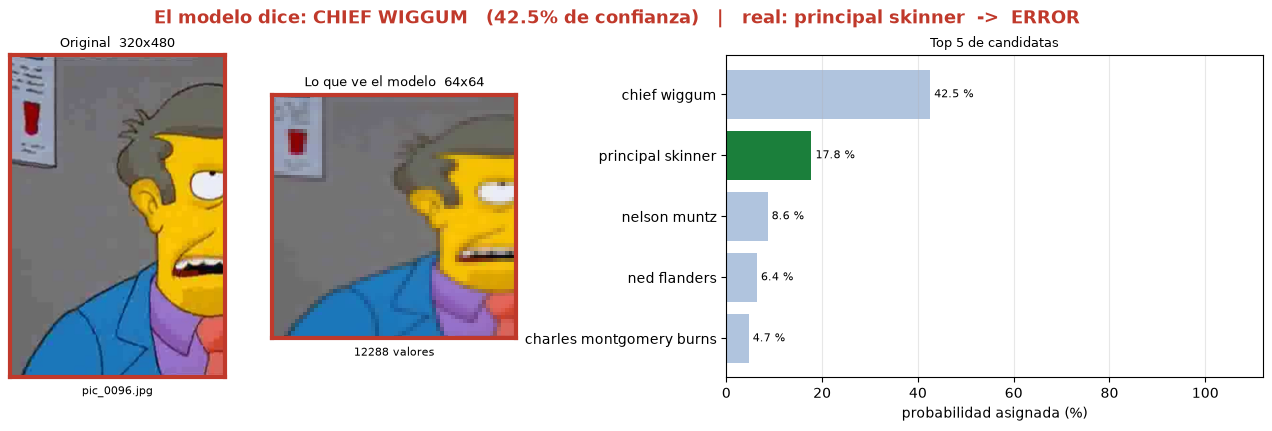

,personaje,probabilidad
0,chief wiggum,0.4254
1,principal skinner,0.1776
2,nelson muntz,0.0860
3,ned flanders,0.0636
4,charles montgomery burns,0.0465


In [113]:
# Cambia esta ruta por la de la imagen que quieras clasificar y vuelve a ejecutar la celda
RUTA_IMAGEN = r"C:\Users\Laptop\Desktop\Trabajos\LosSimpsonsDataset\test\principal_skinner\pic_0096.jpg"

candidatas = predecir_imagen(RUTA_IMAGEN, top_k=5)
display(candidatas)

**Advertencia sobre la interpretación.** La red siempre responde algo: el softmax reparte
probabilidad entre las 25 clases conocidas y devuelve la mayor, aunque la imagen no contenga a ningún
personaje de Los Simpson. No existe una opción "ninguno de los anteriores". Por eso la confianza es tan
informativa como el nombre: un valor cercano al 100 % indica una decisión clara, mientras que una
ganadora con 15 % frente a candidatas de 12 % significa que el modelo no tiene criterio para decidir.

Conviene recordar también los límites vistos en la evaluación: el modelo reconoce con solidez a los
personajes con muchas imágenes de entrenamiento y falla con frecuencia en los minoritarios, y es sensible
al encuadre y al fondo. Una foto con el personaje pequeño dentro de una escena cargada tiene bastantes
menos probabilidades de clasificarse bien que un primer plano.

## Referencias

**Dataset**

- Alfaro, A. (s. f.). *Los Simpson* [conjunto de datos]. Kaggle.
  https://www.kaggle.com/datasets/alfaro96/los-simpson

**Documentación de las librerías utilizadas**

- TensorFlow / Keras — *Keras API reference*. https://keras.io/api/
- TensorFlow / Keras — *The Sequential model*. https://keras.io/guides/sequential_model/
- scikit-learn — *Metrics and scoring*. https://scikit-learn.org/stable/modules/model_evaluation.html
- scikit-learn — `train_test_split`. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
- scikit-learn — `compute_class_weight`. https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html
- NumPy — *NumPy documentation*. https://numpy.org/doc/stable/
- pandas — *pandas documentation*. https://pandas.pydata.org/docs/
- Matplotlib — *Matplotlib documentation*. https://matplotlib.org/stable/index.html
- seaborn — *seaborn documentation*. https://seaborn.pydata.org/
- Pillow — *Pillow (PIL Fork) documentation*. https://pillow.readthedocs.io/en/stable/

**Material del curso**

- Jerez Salazar, F. J. *1.1.1 El Perceptrón*. Machine Learning, TLY1102.
- Jerez Salazar, F. J. *1.2.1 Redes Fully Connected*. Machine Learning, TLY1102.
- Jerez Salazar, F. J. *1.2.2 Backpropagation*. Machine Learning, TLY1102.
- Jerez Salazar, F. J. *1.3.1 Descenso del Gradiente*. Machine Learning, TLY1102.
- Jerez Salazar, F. J. *1.3.2 Optimizadores*. Machine Learning, TLY1102.
- Jerez Salazar, F. J. *1.4.1 Diseño y Evaluación de Modelos*. Machine Learning, TLY1102.
- Jerez Salazar, F. J. *1.4.2 Implementación con Keras*. Machine Learning, TLY1102.

## Resumen de rendimiento de la corrida (CPU vs GPU)

Esta última sección no añade nada al modelo: mide **cuánto costó obtenerlo**. Las secciones anteriores
responden qué tan bien clasifica la red; esta responde en qué hardware se entrenó, cuánto tardó cada
etapa y qué se gana al mover el mismo trabajo de la CPU a la GPU.

Se reportan tres cosas:

1. **El entorno y las marcas de tiempo.** Qué dispositivo ejecutó realmente las operaciones —CPU o
   GPU—, con su nombre, el sistema operativo y la versión de TensorFlow, además de la resolución de
   entrada, la **fecha y hora de inicio** de la corrida (la fija la primera celda del notebook), la
   **hora de término** y la duración total. Es el dato que da sentido a todos los tiempos.
2. **Los tiempos de la corrida.** Segundos y segundos por época de cada configuración entrenada, más un
   *benchmark* corto de tres épocas sobre la arquitectura base y una medición de inferencia sobre el
   conjunto de test. El benchmark existe porque los tiempos de las secciones anteriores no son
   comparables entre sí: la parada temprana hace que cada configuración corra un número distinto de
   épocas. Entrenar unas pocas épocas con la misma arquitectura, el mismo batch y sin *callbacks* sí da
   una cifra homogénea. De esas épocas se descarta la primera, que incluye la compilación del grafo y el
   traslado inicial de los datos al dispositivo.
3. **La comparación entre entornos.** Cada notebook guarda su resumen en una carpeta propia dentro de
   `../resultados/`, con la resolución en el nombre del archivo:

   ```
   resultados/
   ├── CPU/rendimiento_cpu_64x64.json
   └── GPU/rendimiento_gpu_64x64.json
   ```

   La celda cruza únicamente el par que comparte resolución, porque comparar una corrida de 64 x 64
   con otra de 128 x 128 mediría el tamaño del problema y no el hardware. Cuando existen los dos,
   muestra la tabla y el gráfico comparativos con la aceleración obtenida en cada medición; si solo
   está el de este entorno, se guarda igual, se avisa de cuál falta y se indica a qué resoluciones sí
   hay corridas guardadas del otro.

Conviene recordar al leer las cifras que un MLP es, capa a capa, una multiplicación de matrices densas:
exactamente el tipo de operación que una GPU paraleliza bien, así que la diferencia debería notarse
sobre todo en el entrenamiento. Las métricas de calidad (accuracy, F1) aparecen en la tabla solo para
verificar que el cambio de hardware **no** cambia lo que el modelo aprende: si difieren mucho, la causa
está en el pre-procesamiento o en los hiperparámetros, no en el dispositivo.

,Concepto,Valor
0,Entorno,CPU
1,Dispositivo de cómputo,"Intel64 Family 6 Model 186 Stepping 2, Genuine..."
2,CPU del equipo,"Intel64 Family 6 Model 186 Stepping 2, Genuine..."
3,GPUs visibles para TensorFlow,0
4,Sistema operativo,Windows 11
5,Python,3.13.15
6,TensorFlow,2.21.0
7,Resolución de entrada,64x64x3 = 12288 valores
8,Inicio de la corrida,2026-09-15 11:22:54


,experimento,epocas,parametros,segundos,segundos_por_epoca,imagenes_por_segundo
0,"Base - 2 capas (512,256)",51,6432793,310.317554,6.08,2122.0
1,E1 - 1 capa (512),8,6306841,42.500000,5.31,2430.0
2,"E2 - 3 capas (1024,512,256)",35,13253657,421.000000,12.03,1073.0
3,E3 - activación tanh,8,6432793,44.900000,5.61,2300.0
4,E4 - learning rate 1e-4,28,6432793,191.400000,6.84,1888.0
5,E5 - batch 512,14,6432793,53.700000,3.84,3365.0


,Medicion,Valor
0,Entrenamiento: segundos por epoca (arquitectur...,6.87
1,Entrenamiento: imágenes por segundo,1879.00
2,"Inferencia: segundos para las 3,937 imagenes d...",1.03
3,Inferencia: imágenes por segundo,3808.00


,Concepto,Valor
0,entorno,CPU
1,dispositivo,"Intel64 Family 6 Model 186 Stepping 2, Genuine..."
2,cpu,"Intel64 Family 6 Model 186 Stepping 2, Genuine..."
3,sistema_operativo,Windows 11
4,tensorflow,2.21.0
5,inicio_corrida,2026-09-15 11:22:54
6,fin_corrida,2026-09-15 11:42:38
7,duracion_corrida,0:19:44
8,duracion_corrida_segundos,1183.6
9,resolucion,64x64


Resumen guardado en: C:\Users\Laptop\Desktop\Trabajos\Duoc\3er Anio\2do Semestre\LosSimpsons_PMC\resultados\CPU\rendimiento_cpu_64x64.json


,Concepto,CPU,GPU,Diferencia
0,Dispositivo,"Intel64 Family 6 Model 186 Stepping 2, Genuine...",NVIDIA GeForce RTX 4060 Laptop GPU (CC 8.9),-
1,Sistema operativo,Windows 11,Linux 6.6.87.2-microsoft-standard-WSL2,-
2,Inicio de la corrida,2026-09-15 11:22:54,2026-09-14 13:39:03,-
3,Termino de la corrida,2026-09-15 11:42:38,2026-09-14 13:46:21,-
4,Duracion de la corrida,0:19:44,0:07:18,-
5,Resolución de entrada,64x64,64x64,-
6,Parámetros del modelo final,13253657,6432793,-
7,Épocas totales entrenadas,144,154,-
8,Segundos: modelo base,310.3,78.5,GPU x3.95 mas rapida
9,Segundos: experimentos,753.5,156.9,GPU x4.80 mas rapida



Ambas corridas entrenan la misma red sobre la misma entrada (64x64x3 = 12288 valores por imagen), asi que la diferencia de tiempos es atribuible al hardware y no al tamano del problema.


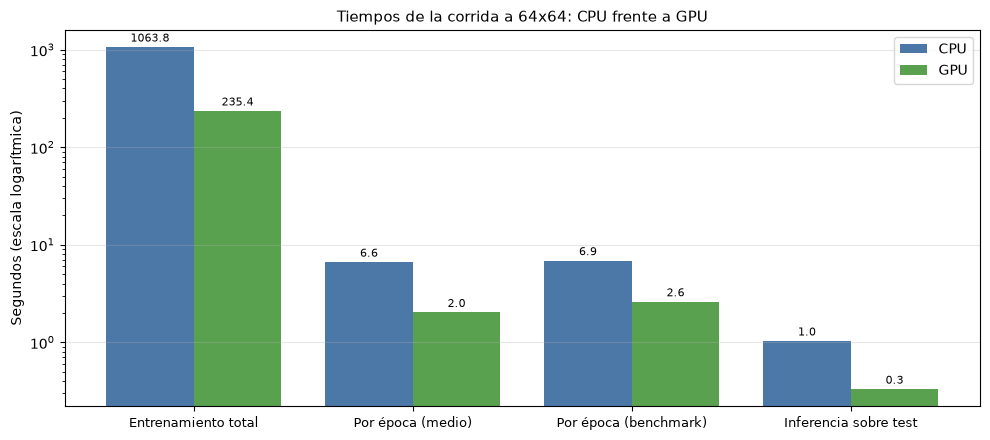

In [114]:
# Resumen de rendimiento de la corrida: entorno de ejecución, marcas de tiempo,
# tiempos y métricas finales. Cada notebook escribe su resumen en
# ../resultados/<CPU|GPU>/rendimiento_<entorno>_<resolucion>.json y, si existe el
# del otro entorno a la misma resolución, se muestra la comparación lado a lado.
import json
import platform
import subprocess
import time
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

DIRECTORIO_RESULTADOS = Path("../resultados")
DIRECTORIO_RESULTADOS.mkdir(parents=True, exist_ok=True)

# La resolución de entrada forma parte del nombre del archivo: una corrida a 64x64
# y otra a 128x128 entrenan modelos de distinto tamaño y no son comparables entre sí.
RESOLUCION = f"{ALTO_OBJETIVO}x{ANCHO_OBJETIVO}"

# La marca de inicio la fija la primera celda del notebook; si esa celda no se
# ejecutó en esta sesión, se toma el arranque de esta sección como referencia.
INICIO_CORRIDA = globals().get("INICIO_CORRIDA") or datetime.now()

# Re-entrena unas pocas épocas para medir un tiempo por época comparable entre
# entornos (misma arquitectura, mismo batch, sin callbacks). Poner False para omitirlo.
EJECUTAR_BENCHMARK = True
EPOCAS_BENCHMARK = 3


# --- 1. Entorno de ejecución -------------------------------------------------
def describir_cpu():
    """Nombre del procesador, en Windows y en Linux/WSL."""
    if platform.system() == "Windows":
        return platform.processor() or platform.machine()
    try:
        for linea in Path("/proc/cpuinfo").read_text().splitlines():
            if linea.startswith("model name"):
                return linea.split(":", 1)[1].strip()
    except OSError:
        pass
    return platform.processor() or platform.machine()


def describir_gpu(dispositivos):
    """Nombre comercial de la primera GPU visible para TensorFlow."""
    try:
        detalles = tf.config.experimental.get_device_details(dispositivos[0])
        nombre = detalles.get("device_name")
        if nombre:
            capacidad = detalles.get("compute_capability")
            return nombre + (f" (CC {capacidad[0]}.{capacidad[1]})" if capacidad else "")
    except Exception:
        pass
    try:
        salida = subprocess.run(
            ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
            capture_output=True,
            text=True,
            timeout=10,
        )
        if salida.returncode == 0 and salida.stdout.strip():
            return salida.stdout.strip().splitlines()[0]
    except (OSError, subprocess.SubprocessError):
        pass
    return dispositivos[0].name


gpus_visibles = tf.config.list_physical_devices("GPU")
usa_gpu = len(gpus_visibles) > 0
ENTORNO = "GPU" if usa_gpu else "CPU"
dispositivo = describir_gpu(gpus_visibles) if usa_gpu else describir_cpu()

entorno = pd.DataFrame(
    [
        ("Entorno", ENTORNO),
        ("Dispositivo de cómputo", dispositivo),
        ("CPU del equipo", describir_cpu()),
        ("GPUs visibles para TensorFlow", len(gpus_visibles)),
        ("Sistema operativo", f"{platform.system()} {platform.release()}"),
        ("Python", platform.python_version()),
        ("TensorFlow", tf.__version__),
        ("Resolución de entrada", f"{RESOLUCION}x3 = {DIMENSION_ENTRADA} valores"),
        ("Inicio de la corrida", INICIO_CORRIDA.strftime("%Y-%m-%d %H:%M:%S")),
    ],
    columns=["Concepto", "Valor"],
)
display(entorno)


# --- 2. Tiempos de entrenamiento --------------------------------------------
# El tiempo del modelo base lo mide la celda de entrenamiento; si esa celda no se
# volvió a ejecutar, queda como desconocido en lugar de inventar un valor.
segundos_base = float(globals().get("segundos_entrenamiento_base", np.nan))
epocas_base = len(historial_base.history["loss"])

tiempos = tabla_experimentos[["experimento", "epocas", "parametros", "segundos"]].copy()
# El modelo base entra en la tabla de experimentos sin tiempo: se completa aquí
tiempos.loc[tiempos["experimento"].str.startswith("Base"), "segundos"] = segundos_base
tiempos["segundos_por_epoca"] = (tiempos["segundos"] / tiempos["epocas"]).round(2)
tiempos["imagenes_por_segundo"] = (
    len(X_train) * tiempos["epocas"] / tiempos["segundos"]
).round(0)

display(tiempos)

segundos_experimentos = float(
    tabla_experimentos.loc[
        ~tabla_experimentos["experimento"].str.startswith("Base"), "segundos"
    ].sum()
)
segundos_totales = float(np.nansum([segundos_base, segundos_experimentos]))
segundos_por_epoca_medio = float(tiempos["segundos_por_epoca"].mean(skipna=True))
epocas_totales = int(tiempos["epocas"].sum())


# --- 3. Benchmark comparable: entrenamiento e inferencia ---------------------
class CronometroEpocas(keras.callbacks.Callback):
    """Registra cuánto dura cada época."""

    def __init__(self):
        super().__init__()
        self.duraciones = []

    def on_epoch_begin(self, epoch, logs=None):
        self._inicio = time.perf_counter()

    def on_epoch_end(self, epoch, logs=None):
        self.duraciones.append(time.perf_counter() - self._inicio)


benchmark_segundos_epoca = np.nan
if EJECUTAR_BENCHMARK:
    keras.utils.set_random_seed(SEMILLA)
    modelo_benchmark = compilar(construir_mlp(nombre="mlp_benchmark"))
    cronometro = CronometroEpocas()
    modelo_benchmark.fit(
        X_train,
        y_train,
        epochs=EPOCAS_BENCHMARK,
        batch_size=TAMANO_BATCH,
        callbacks=[cronometro],
        verbose=0,
    )
    # Se descarta la primera época: incluye la compilación del grafo y el traslado
    # inicial de los datos al dispositivo, que no se repiten en las siguientes
    duraciones_utiles = cronometro.duraciones[1:] or cronometro.duraciones
    benchmark_segundos_epoca = float(np.mean(duraciones_utiles))

# Inferencia sobre el conjunto de evaluación completo, tras una pasada de calentamiento
modelo_final.predict(X_test[:256], batch_size=256, verbose=0)
inicio_inferencia = time.perf_counter()
modelo_final.predict(X_test, batch_size=256, verbose=0)
segundos_inferencia = time.perf_counter() - inicio_inferencia

benchmark = pd.DataFrame(
    [
        (
            f"Entrenamiento: segundos por epoca (arquitectura base, batch {TAMANO_BATCH})",
            round(benchmark_segundos_epoca, 2) if EJECUTAR_BENCHMARK else "no ejecutado",
        ),
        (
            "Entrenamiento: imágenes por segundo",
            round(len(X_train) / benchmark_segundos_epoca) if EJECUTAR_BENCHMARK else "-",
        ),
        (
            f"Inferencia: segundos para las {len(X_test):,} imagenes de test",
            round(segundos_inferencia, 2),
        ),
        ("Inferencia: imágenes por segundo", round(len(X_test) / segundos_inferencia)),
    ],
    columns=["Medicion", "Valor"],
)
display(benchmark)


# --- 4. Resumen de la corrida ------------------------------------------------
# El término se marca aquí, después del benchmark y de la medición de inferencia:
# es el último trabajo real de la corrida.
FIN_CORRIDA = datetime.now()
duracion_corrida_segundos = (FIN_CORRIDA - INICIO_CORRIDA).total_seconds()
duracion_corrida = str(timedelta(seconds=round(duracion_corrida_segundos)))

resumen_corrida = {
    "entorno": ENTORNO,
    "dispositivo": dispositivo,
    "cpu": describir_cpu(),
    "sistema_operativo": f"{platform.system()} {platform.release()}",
    "tensorflow": tf.__version__,
    "inicio_corrida": INICIO_CORRIDA.strftime("%Y-%m-%d %H:%M:%S"),
    "fin_corrida": FIN_CORRIDA.strftime("%Y-%m-%d %H:%M:%S"),
    "duracion_corrida": duracion_corrida,
    "duracion_corrida_segundos": round(duracion_corrida_segundos, 1),
    "resolucion": RESOLUCION,
    "dimension_entrada": int(DIMENSION_ENTRADA),
    "imagenes_train": int(len(X_train)),
    "imagenes_val": int(len(X_val)),
    "imagenes_test": int(len(X_test)),
    "batch": int(TAMANO_BATCH),
    "configuracion_final": nombre_final,
    "parametros_modelo_final": int(modelo_final.count_params()),
    "epocas_modelo_base": int(epocas_base),
    "segundos_modelo_base": None if np.isnan(segundos_base) else round(segundos_base, 1),
    "segundos_experimentos": round(segundos_experimentos, 1),
    "segundos_entrenamiento_total": round(segundos_totales, 1),
    "epocas_totales": epocas_totales,
    "segundos_por_epoca_medio": round(segundos_por_epoca_medio, 2),
    "benchmark_segundos_por_epoca": (
        None if np.isnan(benchmark_segundos_epoca) else round(benchmark_segundos_epoca, 2)
    ),
    "segundos_inferencia_test": round(segundos_inferencia, 2),
    "inferencia_imagenes_por_segundo": round(len(X_test) / segundos_inferencia, 1),
    "accuracy_test": round(float(accuracy_test), 4),
    "top3_test": round(float(top3_test), 4),
    "f1_macro_test": round(float(f1_macro_test), 4),
    "f1_ponderado_test": round(float(f1_ponderado_test), 4),
    "perdida_test": round(float(perdida_test), 4),
}

# Una carpeta por entorno y un archivo por resolución:
# ../resultados/CPU/rendimiento_cpu_64x64.json
directorio_entorno = DIRECTORIO_RESULTADOS / ENTORNO
directorio_entorno.mkdir(parents=True, exist_ok=True)
ruta_resumen = directorio_entorno / f"rendimiento_{ENTORNO.lower()}_{RESOLUCION}.json"
ruta_resumen.write_text(json.dumps(resumen_corrida, indent=2, ensure_ascii=False), encoding="utf-8")

display(
    pd.DataFrame(
        [
            (clave, valor if valor is not None else "desconocido")
            for clave, valor in resumen_corrida.items()
        ],
        columns=["Concepto", "Valor"],
    )
)
print(f"Resumen guardado en: {ruta_resumen.resolve()}")


# --- 5. Comparación CPU vs GPU ----------------------------------------------
# Solo es posible cuando ya se ejecutaron ambos notebooks A LA MISMA RESOLUCIÓN:
# cada uno deja su json en ../resultados/<ENTORNO>/ y esta sección cruza el par
# que comparte resolución, que es el único par que compara hardware y no tamaños.
def ruta_resumen_de(nombre_entorno, resolucion):
    carpeta = DIRECTORIO_RESULTADOS / nombre_entorno.upper()
    return carpeta / f"rendimiento_{nombre_entorno.lower()}_{resolucion}.json"


def resoluciones_guardadas(nombre_entorno):
    carpeta = DIRECTORIO_RESULTADOS / nombre_entorno.upper()
    if not carpeta.is_dir():
        return []
    patron = f"rendimiento_{nombre_entorno.lower()}_*.json"
    return sorted(archivo.stem.rsplit("_", 1)[-1] for archivo in carpeta.glob(patron))


resumenes = {}
for nombre_entorno in ("cpu", "gpu"):
    ruta = ruta_resumen_de(nombre_entorno, RESOLUCION)
    if ruta.exists():
        resumenes[nombre_entorno.upper()] = json.loads(ruta.read_text(encoding="utf-8"))

if len(resumenes) < 2:
    faltante = "GPU" if "GPU" not in resumenes else "CPU"
    print(
        f"\nSolo hay resultados a {RESOLUCION} del entorno {ENTORNO}. Ejecuta tambien "
        f"el notebook del entorno {faltante} con la misma resolucion para ver la "
        f"comparacion; cada uno escribe su resumen en "
        f"{(DIRECTORIO_RESULTADOS / faltante).resolve()}."
    )
    otras = [r for r in resoluciones_guardadas(faltante) if r != RESOLUCION]
    if otras:
        print(
            f"El entorno {faltante} si tiene corridas guardadas a: {', '.join(otras)}. "
            f"No se comparan con esta porque una resolucion distinta cambia el tamano "
            f"de la entrada y del modelo, y los tiempos dejarian de medir el hardware."
        )
else:
    cpu, gpu = resumenes["CPU"], resumenes["GPU"]

    # (etiqueta, clave, "menor" = menos es mejor, "mayor" = más es mejor, None = no se compara)
    filas_comparacion = [
        ("Dispositivo", "dispositivo", None),
        ("Sistema operativo", "sistema_operativo", None),
        ("Inicio de la corrida", "inicio_corrida", None),
        ("Termino de la corrida", "fin_corrida", None),
        ("Duracion de la corrida", "duracion_corrida", None),
        ("Resolución de entrada", "resolucion", None),
        ("Parámetros del modelo final", "parametros_modelo_final", None),
        ("Épocas totales entrenadas", "epocas_totales", None),
        ("Segundos: modelo base", "segundos_modelo_base", "menor"),
        ("Segundos: experimentos", "segundos_experimentos", "menor"),
        ("Segundos: entrenamiento total", "segundos_entrenamiento_total", "menor"),
        ("Segundos por época (medio)", "segundos_por_epoca_medio", "menor"),
        ("Segundos por época (benchmark)", "benchmark_segundos_por_epoca", "menor"),
        ("Segundos: inferencia sobre test", "segundos_inferencia_test", "menor"),
        ("Inferencia: imágenes por segundo", "inferencia_imagenes_por_segundo", "mayor"),
        ("Accuracy en test", "accuracy_test", "mayor"),
        ("Top-3 accuracy en test", "top3_test", "mayor"),
        ("F1 macro en test", "f1_macro_test", "mayor"),
    ]

    registros = []
    for etiqueta, clave, direccion in filas_comparacion:
        valor_cpu, valor_gpu = cpu.get(clave), gpu.get(clave)
        diferencia = "-"
        comparables = isinstance(valor_cpu, (int, float)) and isinstance(valor_gpu, (int, float))
        if direccion and comparables:
            if direccion == "menor" and valor_gpu > 0:
                diferencia = f"GPU x{valor_cpu / valor_gpu:.2f} mas rapida"
            elif direccion == "mayor" and valor_cpu > 0:
                diferencia = f"GPU x{valor_gpu / valor_cpu:.2f}"
        registros.append(
            {
                "Concepto": etiqueta,
                "CPU": valor_cpu if valor_cpu is not None else "desconocido",
                "GPU": valor_gpu if valor_gpu is not None else "desconocido",
                "Diferencia": diferencia,
            }
        )

    comparacion_entornos = pd.DataFrame(registros)
    display(comparacion_entornos)

    print(
        f"\nAmbas corridas entrenan la misma red sobre la misma entrada "
        f"({RESOLUCION}x3 = {cpu['dimension_entrada']} valores por imagen), asi que la "
        f"diferencia de tiempos es atribuible al hardware y no al tamano del problema."
    )

    # Tiempos lado a lado, en escala logarítmica: los órdenes de magnitud suelen diferir
    metricas_grafico = [
        ("Entrenamiento total", "segundos_entrenamiento_total"),
        ("Por época (medio)", "segundos_por_epoca_medio"),
        ("Por época (benchmark)", "benchmark_segundos_por_epoca"),
        ("Inferencia sobre test", "segundos_inferencia_test"),
    ]
    metricas_grafico = [
        (etiqueta, clave)
        for etiqueta, clave in metricas_grafico
        if isinstance(cpu.get(clave), (int, float)) and isinstance(gpu.get(clave), (int, float))
    ]

    if metricas_grafico:
        posiciones = np.arange(len(metricas_grafico))
        valores_cpu = [cpu[clave] for _, clave in metricas_grafico]
        valores_gpu = [gpu[clave] for _, clave in metricas_grafico]

        figura, eje = plt.subplots(figsize=(10, 4.5))
        barras_cpu = eje.bar(posiciones - 0.2, valores_cpu, width=0.4, label="CPU", color="#4c78a8")
        barras_gpu = eje.bar(posiciones + 0.2, valores_gpu, width=0.4, label="GPU", color="#59a14f")

        eje.set_yscale("log")
        eje.set_xticks(posiciones)
        eje.set_xticklabels([etiqueta for etiqueta, _ in metricas_grafico], fontsize=9)
        eje.set_ylabel("Segundos (escala logarítmica)")
        eje.set_title(f"Tiempos de la corrida a {RESOLUCION}: CPU frente a GPU", fontsize=11)
        eje.legend()
        eje.grid(alpha=0.3, axis="y")

        for barras in (barras_cpu, barras_gpu):
            eje.bar_label(barras, fmt="%.1f", fontsize=8, padding=2)

        plt.tight_layout()
        plt.show()